<!-- # Visualisations

Loads saved results from `Results/` and produces publication-quality figures.
Each figure is saved to `Plots/` as a PNG with metadata recorded in
the result group's manifest JSON.

**Run order**
1. *Setup* — imports, style, helpers
2. *Q(k) diagnostics* — raw and interpolated self-energy
3. *Exciton & photon dispersion*
4. *Lower polariton dispersion*
5. *Hopfield coefficients*
6. *Detuning*
7. *Interaction strengths vs k* -->


In [1]:
import sys
sys.path.insert(0, '.')

import json
import datetime
from dataclasses import replace
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, FixedLocator, MaxNLocator
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

from polaritons.io         import load_result, load_latest, list_results, save_result, make_sweep_stem
from polaritons.dispersion import DispersionModel
from polaritons.many_body  import (
	hopfield_coefficients,
	polariton_interaction_strength,
	Pi0,
)
from polaritons.parameters import Params

# ---------------------------------------------------------------------------
# Matplotlib style
# ---------------------------------------------------------------------------
CMAP_NAME = "magma"
CMAP = plt.get_cmap(CMAP_NAME)
SHOW_M_PRIME_LABEL = True

plt.rcParams.update({
	'font.family'               : 'serif',
	'font.serif'                : ['DejaVu Serif'],
	'font.size'                 : 14,
	'axes.labelsize'            : 16,
	'axes.titlesize'            : 16,
	'xtick.labelsize'           : 14,
	'ytick.labelsize'           : 14,
	'legend.fontsize'           : 13,
	'figure.titlesize'          : 18,
	'axes.formatter.limits'     : (-99, 99),
	'axes.formatter.useoffset'  : False,
	'image.cmap'                : CMAP_NAME,
})

PLOTS_DIR = Path("Plots")
PLOTS_DIR.mkdir(exist_ok=True)
PLOT_MANIFESTS = {}
CM_INV_PER_M_INV = 0.01
CM_INV_LABEL = "cm⁻¹"
INTERACTION_UNIT_LABEL = "μeV μm²"
SUPERSCRIPT = str.maketrans("-0123456789", "⁻⁰¹²³⁴⁵⁶⁷⁸⁹")

# ---------------------------------------------------------------------------
# Plot-boundary unit conversion helpers
# ---------------------------------------------------------------------------

def k_nat_to_cm(k_nat, p_nat):
	values = CM_INV_PER_M_INV * np.asarray(k_nat, dtype=float) / p_nat.L_unit
	return float(values) if values.ndim == 0 else values


def k_nat_to_cm_array(k_nat, p_nat):
	return np.asarray(k_nat_to_cm(k_nat, p_nat), dtype=float)


def k_cm_to_nat(k_cm, p_nat):
	values = np.asarray(k_cm, dtype=float) * p_nat.L_unit / CM_INV_PER_M_INV
	return float(values) if values.ndim == 0 else values


def energy_nat_to_eV(E_nat, p_nat):
	return np.asarray(E_nat) * p_nat.E_unit


def energy_nat_to_meV(E_nat, p_nat):
	return 1e3 * energy_nat_to_eV(E_nat, p_nat)


def energy_nat_to_microeV(E_nat, p_nat):
	return 1e6 * energy_nat_to_eV(E_nat, p_nat)


def energy_nat_to_neV(E_nat, p_nat):
	return 1e9 * energy_nat_to_eV(E_nat, p_nat)


def interaction_nat_to_microev_um2(g_nat, p_nat):
	return 1e18 * np.asarray(g_nat) * p_nat.E_unit * p_nat.L_unit**2


def eta_color(index: int, total: int):
	denom = max(total - 1, 1)
	return CMAP(0.12 + 0.83 * index / denom)


def eta_line_style(index: int, total: int, eta_value: float, *, linestyle: str = "-"):
	if np.isclose(float(eta_value), 0.0, atol=1e-12):
		return "black", "--"
	return eta_color(index, total), linestyle


def eta_indices_descending(indices=None):
	candidates = range(len(eta_grid)) if indices is None else [int(idx) for idx in indices]
	return sorted(candidates, key=lambda idx: float(eta_grid[idx]), reverse=True)


def eta_values_descending(values):
	return sorted([float(value) for value in values], reverse=True)


def cavity_label(disorder_tuned: bool) -> str:
	return "disorder-tuned cavity" if disorder_tuned else "disorder-free cavity"


def cavity_slug(disorder_tuned: bool) -> str:
	return "disorder_tuned" if disorder_tuned else "disorder_free"


def superscript_int(value: int) -> str:
	return str(int(value)).translate(SUPERSCRIPT)


def format_number(value) -> str:
	value = float(value)
	if not np.isfinite(value):
		return ""
	if abs(value) < 5e-13:
		value = 0.0
	value = round(value, 5)
	if abs(value - round(value)) < 5e-12:
		return f"{int(round(value)):,}" if abs(value) >= 1000 else str(int(round(value)))
	text = f"{value:,.5f}" if abs(value) >= 1000 else f"{value:.5f}"
	return text.rstrip("0").rstrip(".")


def format_power_value(value) -> str:
	value = float(value)
	if not np.isfinite(value):
		return ""
	if abs(value) < 1e-12:
		return "0"
	sign = "−" if value < 0 else ""
	value = abs(value)
	exponent = int(np.floor(np.log10(value)))
	coefficient = value / 10**exponent
	return f"{sign}{format_number(coefficient)}×10{superscript_int(exponent)}"


def format_power_value_fixed(value, *, decimals=2, zero_tol=1e-12) -> str:
	value = float(value)
	if not np.isfinite(value):
		return ""
	if value == 0.0 or (zero_tol is not None and abs(value) < zero_tol):
		return "0"
	sign = "−" if value < 0 else ""
	value = abs(value)
	exponent = int(np.floor(np.log10(value)))
	coefficient = value / 10**exponent
	return f"{sign}{coefficient:.{decimals}f}×10{superscript_int(exponent)}"


def axis_names(axes):
	return (axes,) if isinstance(axes, str) else tuple(axes)


def hide_axis_offset(ax, axes=("x", "y")):
	for axis_name in axis_names(axes):
		getattr(ax, f"{axis_name}axis").get_offset_text().set_visible(False)


def tick_formatter(style="number", *, decimals=2, zero_tol=1e-12):
	if style == "number":
		return FuncFormatter(lambda value, pos: format_number(value))
	if style == "power":
		return FuncFormatter(lambda value, pos: format_power_value(value))
	if style == "fixed_power":
		return FuncFormatter(lambda value, pos: format_power_value_fixed(value, decimals=decimals, zero_tol=zero_tol))
	if callable(style):
		return FuncFormatter(lambda value, pos: style(value))
	raise ValueError(f"Unknown tick formatter: {style!r}")


def format_plot_ticks(ax, *, axes=("x", "y"), ticks=None, nbins=None, formatter="number", decimals=2, zero_tol=1e-12):
	if ticks is not None and nbins is not None:
		raise ValueError("Pass either ticks or nbins, not both.")
	for axis_name in axis_names(axes):
		axis = getattr(ax, f"{axis_name}axis")
		if ticks is not None:
			axis.set_major_locator(FixedLocator(ticks))
		elif nbins is not None:
			axis.set_major_locator(MaxNLocator(nbins=nbins, min_n_ticks=2))
		axis.set_major_formatter(tick_formatter(formatter, decimals=decimals, zero_tol=zero_tol))
	hide_axis_offset(ax)


def apply_centered_critical_axis(ax, critical_k_cm, *, decimals=2, fallback_xmax=None, fallback_tick_count=5):
	if critical_k_cm is None or not np.isfinite(critical_k_cm) or critical_k_cm <= 0.0:
		xmax = float(ax.get_xlim()[1] if fallback_xmax is None else fallback_xmax)
		if xmax > 0 and np.isfinite(xmax):
			format_plot_ticks(ax, axes="x", nbins=max(fallback_tick_count - 1, 1), formatter="power")
		return
	critical_k_cm = float(critical_k_cm)
	xmax = 2.0 * critical_k_cm
	ax.set_xlim(0.0, xmax)
	ticks = [0.0, 0.5 * critical_k_cm, critical_k_cm, 1.5 * critical_k_cm, xmax]
	labels = ["0.00"] + [format_power_value_fixed(tick, decimals=decimals) for tick in ticks[1:]]
	ax.xaxis.set_major_locator(FixedLocator(ticks))
	ax.set_xticklabels(labels)
	hide_axis_offset(ax)


def clean_number_slug(value):
	text = f"{float(value):.6g}"
	return text.replace("-", "m").replace("+", "").replace(".", "p")


def display_kernel_type(kernel_type):
	labels = {
		"gaussian"   : "Gaussian",
		"nongaussian": "Non-Gaussian",
		"ng"         : "Non-Gaussian",
	}
	return labels.get(str(kernel_type), str(kernel_type))


def build_result_slug(kernel_type, xi_m, m_prime):
	kernel_part = str(kernel_type).replace(" ", "_").replace("-", "_").lower()
	m_part = f"mprime{clean_number_slug(m_prime)}"
	if xi_m is None:
		return f"{kernel_part}_{m_part}"
	return f"xi{clean_number_slug(1e9 * xi_m)}nm_{m_part}"


def build_result_label(kernel_type, xi_m, m_prime):
	parts = [display_kernel_type(kernel_type)] if xi_m is None else [f"ξ={1e9 * xi_m:g} nm"]
	if SHOW_M_PRIME_LABEL:
		parts.append(f"m'={m_prime:g}")
	return ", ".join(parts)


def calculate_critical_momentum(q_grid, eta_grid, Q_results, p_nat, *, target_eta=1.0):
	q = np.asarray(q_grid, dtype=float)
	eta_values = np.asarray(eta_grid, dtype=float)
	Q = np.asarray(Q_results)
	eta_idx = int(np.argmin(np.abs(eta_values - target_eta)))
	eta_value = float(eta_values[eta_idx])
	y = np.real(Q[eta_idx])
	mask = (q > 0.0) & np.isfinite(q) & np.isfinite(y)
	q_pos = q[mask]
	y_pos = y[mask]
	if q_pos.size < 2:
		return {"critical_eta": eta_value, "critical_k_natural": None, "critical_k_cm_inv": None}

	zero_hits = np.flatnonzero(np.isclose(y_pos, 0.0, rtol=1e-12, atol=1e-12))
	if zero_hits.size:
		k_crit = float(q_pos[int(zero_hits[0])])
	else:
		crossings = np.flatnonzero(np.signbit(y_pos[:-1]) != np.signbit(y_pos[1:]))
		if crossings.size == 0:
			return {"critical_eta": eta_value, "critical_k_natural": None, "critical_k_cm_inv": None}
		i = int(crossings[0])
		k0, k1 = float(q_pos[i]), float(q_pos[i + 1])
		y0, y1 = float(y_pos[i]), float(y_pos[i + 1])
		k_crit = k0 if y1 == y0 else k0 - y0 * (k1 - k0) / (y1 - y0)

	return {
		"critical_eta": eta_value,
		"critical_k_natural": float(k_crit),
		"critical_k_cm_inv": float(k_nat_to_cm(k_crit, p_nat)),
	}


def q_energy_values(Q_nat, p_nat, *, threshold_eV=0.1):
	Q_eV = energy_nat_to_eV(Q_nat, p_nat)
	max_abs_eV = float(np.nanmax(np.abs(Q_eV))) if np.size(Q_eV) else 0.0
	if max_abs_eV < threshold_eV:
		return energy_nat_to_meV(Q_nat, p_nat), "meV", max_abs_eV
	return Q_eV, "eV", max_abs_eV


def context_metadata(ctx):
	xi_value = None if ctx["xi_m"] is None else float(ctx["xi_m"])
	return {
		"source_stem" : ctx["q_stem"],
		"kernel_stem" : ctx["kernel_stem"],
		"kernel_type" : ctx["kernel_type"],
		"xi_independent": bool(ctx["xi_independent"]),
		"xi_m"        : xi_value,
		"m_prime"     : float(ctx["m_prime"]),
		"result_label": ctx["result_label_text"],
		"calculation_units": "natural",
		"sweep_schema": SWEEP_SCHEMA,
		"critical_eta": ctx.get("critical_eta"),
		"critical_k_natural": ctx.get("critical_k_natural"),
		"critical_k_cm_inv": ctx.get("critical_k_cm_inv"),
	}

# ---------------------------------------------------------------------------
# Figure-saving helper
# ---------------------------------------------------------------------------

def group_dir_for_context(ctx):
	return PLOTS_DIR / ctx["result_slug_text"]


def manifest_path_for_context(ctx):
	return group_dir_for_context(ctx) / f"{ctx['result_slug_text']}_manifest.json"


def compact_figure_metadata(meta, group_meta):
	meta = dict(meta or {})
	return {
		key: value for key, value in meta.items()
		if key not in group_meta or group_meta[key] != value
	}


def ensure_group_manifest(ctx):
	slug = ctx["result_slug_text"]
	if slug not in PLOT_MANIFESTS:
		group_dir = group_dir_for_context(ctx)
		group_dir.mkdir(parents=True, exist_ok=True)
		PLOT_MANIFESTS[slug] = {
			"created_at": datetime.datetime.now(datetime.timezone.utc).isoformat(),
			"updated_at": None,
			"group": {
				"slug": slug,
				"directory": str(group_dir),
				**context_metadata(ctx),
			},
			"figures": [],
		}
	return PLOT_MANIFESTS[slug]


def write_group_manifest(ctx):
	manifest = ensure_group_manifest(ctx)
	manifest["updated_at"] = datetime.datetime.now(datetime.timezone.utc).isoformat()
	with open(manifest_path_for_context(ctx), "w") as f:
		json.dump(manifest, f, indent=2, default=str)


def save_figure(fig, name: str, meta=None, dpi: int = 150) -> None:
	"""
	Save `fig` to Plots/<result_slug>/<name>.png, and append figure
	metadata to the result group's manifest JSON.
	"""
	ctx = globals().get("plot_context")
	if ctx is None:
		raise RuntimeError("save_figure requires an active plot_context. Call apply_context first.")

	manifest = ensure_group_manifest(ctx)
	group_dir = group_dir_for_context(ctx)
	png_path = group_dir / f"{name}.png"

	fig.savefig(png_path, bbox_inches="tight", dpi=dpi)

	group_meta = manifest["group"]
	figure_record = {
		"name"    : name,
		"saved_at": datetime.datetime.now(datetime.timezone.utc).isoformat(),
		"png"     : str(png_path),
		"metadata": compact_figure_metadata(meta, group_meta),
	}
	manifest["figures"] = [record for record in manifest["figures"] if record["name"] != name]
	manifest["figures"].append(figure_record)
	write_group_manifest(ctx)
	print(f"Saved  {png_path}")

print("Setup complete.")


Setup complete.


## Load results

Choose which saved result set to visualise.  By default the most recently
saved Q result is loaded; change `Q_STEM` / `SWEEP_IDX` to pick a specific run.


In [2]:
# Set Q_STEMS to a list of specific stems, or None to plot every current-schema Q result.
Q_STEMS = None
SHOW_M_PRIME_LABEL = True
SWEEP_SCHEMA = "gaussian_xi_plus_single_nongaussian_v1"

PARAM_FIELDS = (
	"E_bind", "E_gap_bare", "m_e", "m_h", "m_rest",
	"Omega", "m_prime", "n_refr", "N_qw", "D_0", "xi",
	"T", "concentration", "g_ex", "in_natural_units",
	"E_unit", "L_unit", "c", "hbar", "k_B", "M_eff",
)


def reconstruct_params(raw):
	kwargs = {name: raw[name] for name in PARAM_FIELDS if name in raw}
	params = Params(**kwargs)
	if not params.in_natural_units:
		raise ValueError("Q metadata must contain natural-unit Params. Regenerate results with Polarition Disorder.ipynb.")
	return params


def discover_q_stems():
	if Q_STEMS is not None:
		return list(Q_STEMS)
	metas = [
		meta for meta in list_results("Results/Q_results", prefix="Q")
		if meta.get("calculation_units") == "natural" and meta.get("sweep_schema") == SWEEP_SCHEMA
	]
	if not metas:
		raise FileNotFoundError(
			"No current-schema natural Q results found in Results/Q_results. "
			"Run Polarition Disorder.ipynb after this update."
		)
	return [meta["_stem"] for meta in metas]


def build_plot_context(q_stem_value):
	Q_data, meta = load_result("Results/Q_results", q_stem_value)
	if meta.get("calculation_units") != "natural" or meta.get("sweep_schema") != SWEEP_SCHEMA:
		raise ValueError(f"{q_stem_value} is not a current-schema natural result; regenerate it.")
	meta["_stem"] = q_stem_value
	raw = meta["params"]
	params = reconstruct_params(raw)
	eta_values = np.array(meta["eta_grid"])
	q_values = np.array(meta["q_picard"])
	kernel_name = meta["kernel_type"]
	xi_independent = bool(meta.get("xi_independent", False))
	xi_value = None if xi_independent else float(meta["xi_m"])
	m_prime_value = float(meta.get("m_prime", raw["m_prime"]))
	critical = calculate_critical_momentum(q_values, eta_values, Q_data, params, target_eta=1.0)
	return {
		"Q_results"        : Q_data,
		"q_meta"           : meta,
		"q_stem"           : q_stem_value,
		"p_nat"            : params,
		"eta_grid"         : eta_values,
		"q_picard"         : q_values,
		"kernel_stem"      : meta.get("kernel_stem"),
		"kernel_type"      : kernel_name,
		"xi_independent"   : xi_independent,
		"xi_m"             : xi_value,
		"m_prime"          : m_prime_value,
		"result_slug_text" : build_result_slug(kernel_name, xi_value, m_prime_value),
		"result_label_text": build_result_label(kernel_name, xi_value, m_prime_value),
		**critical,
	}


def context_sort_key(ctx):
	kernel_rank = 0 if ctx["kernel_type"] in ("nongaussian", "ng") else 1
	xi_rank = -float("inf") if ctx["xi_m"] is None else float(ctx["xi_m"])
	return (kernel_rank, xi_rank, float(ctx["m_prime"]), str(ctx["q_stem"]))


def apply_context(ctx):
	for key, value in ctx.items():
		globals()[key] = value
	globals()["plot_context"] = ctx

	# Model, self-energy, and many-body calculations all use natural units.
	model_value = DispersionModel(p_nat, q_picard, eta_grid, Q_results)
	globals()["model"] = model_value

	# Plot grids are sampled in natural units and converted only for axis labels.
	k_domain_max_value = float(q_picard.max())
	positive_q = q_picard[q_picard > 0]
	if positive_q.size == 0:
		raise ValueError(f"Q grid for {q_stem} has no positive momentum samples.")
	first_positive_value = float(positive_q[0])
	k_disp_max = min(float(k_cm_to_nat(40_000.0, p_nat)), k_domain_max_value)
	if k_disp_max <= first_positive_value:
		k_disp_max = k_domain_max_value
	if k_disp_max <= first_positive_value:
		raise ValueError(f"Q grid for {q_stem} does not span more than one positive momentum sample.")

	globals().update({
		"k_domain_max"   : k_domain_max_value,
		"first_positive_k": first_positive_value,
		"k_zero"         : np.array([0.0]),
		"k_disp"         : np.linspace(first_positive_value, k_disp_max, 200),
		"k_wide"         : np.linspace(first_positive_value, k_domain_max_value, 500),
		"k_full_log"     : np.geomspace(first_positive_value, k_domain_max_value, 700),
	})
	globals().update({
		"k_disp_cm"    : k_nat_to_cm_array(k_disp, p_nat),
		"k_wide_cm"    : k_nat_to_cm_array(k_wide, p_nat),
		"k_full_log_cm": k_nat_to_cm_array(k_full_log, p_nat),
	})
	return model_value


plot_contexts = [build_plot_context(stem) for stem in discover_q_stems()]
plot_contexts.sort(key=context_sort_key)
apply_context(plot_contexts[0])

print(f"Loaded {len(plot_contexts)} Q result context(s):")
for ctx in plot_contexts:
	shape = ctx["Q_results"].shape
	critical_text = "none" if ctx["critical_k_cm_inv"] is None else format_power_value_fixed(ctx["critical_k_cm_inv"], decimals=2)
	print(f"  {ctx['q_stem']}: {ctx['result_label_text']}  shape={shape}  kcrit={critical_text}  saved_at={ctx['q_meta'].get('saved_at')}")
print(f"Momentum domain of first context: 0 to {float(k_nat_to_cm(k_domain_max, p_nat)):.3g} {CM_INV_LABEL}")


Loaded 4 Q result context(s):
  Q_b21d3b: Non-Gaussian, m'=1  shape=(21, 15000)  kcrit=4.66×10⁷  saved_at=2026-05-04T22:16:45.361663+00:00
  Q_529b21: ξ=10 nm, m'=1  shape=(21, 15000)  kcrit=4.66×10⁷  saved_at=2026-05-04T22:19:42.222365+00:00
  Q_f632ee: ξ=20 nm, m'=1  shape=(21, 15000)  kcrit=4.66×10⁷  saved_at=2026-05-04T22:24:04.597000+00:00
  Q_08c2ef: ξ=40 nm, m'=1  shape=(21, 15000)  kcrit=4.66×10⁷  saved_at=2026-05-04T22:28:46.316952+00:00
Momentum domain of first context: 0 to 1.2e+08 cm⁻¹


Saved  Plots/nongaussian_mprime1/Q_diagnostics_nongaussian_mprime1.pdf


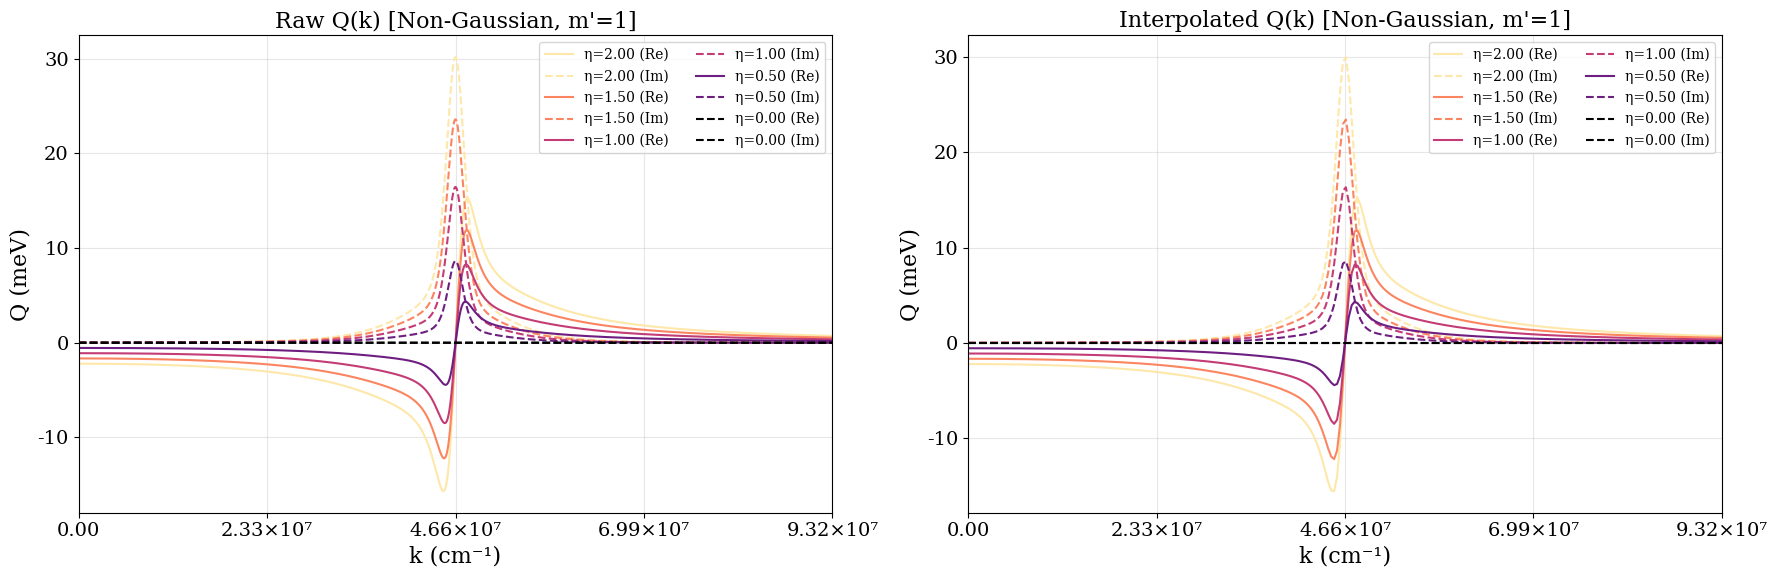

Saved  Plots/xi10nm_mprime1/Q_diagnostics_xi10nm_mprime1.pdf


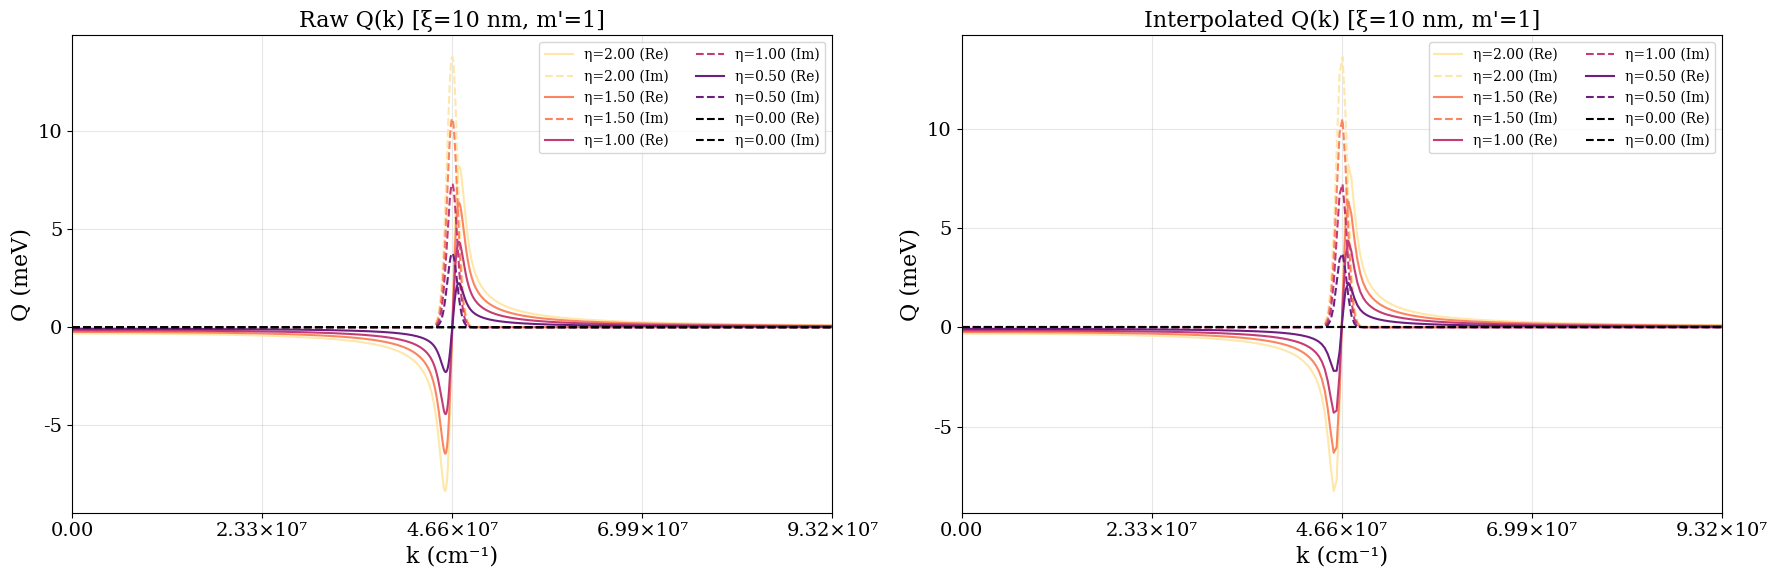

Saved  Plots/xi20nm_mprime1/Q_diagnostics_xi20nm_mprime1.pdf


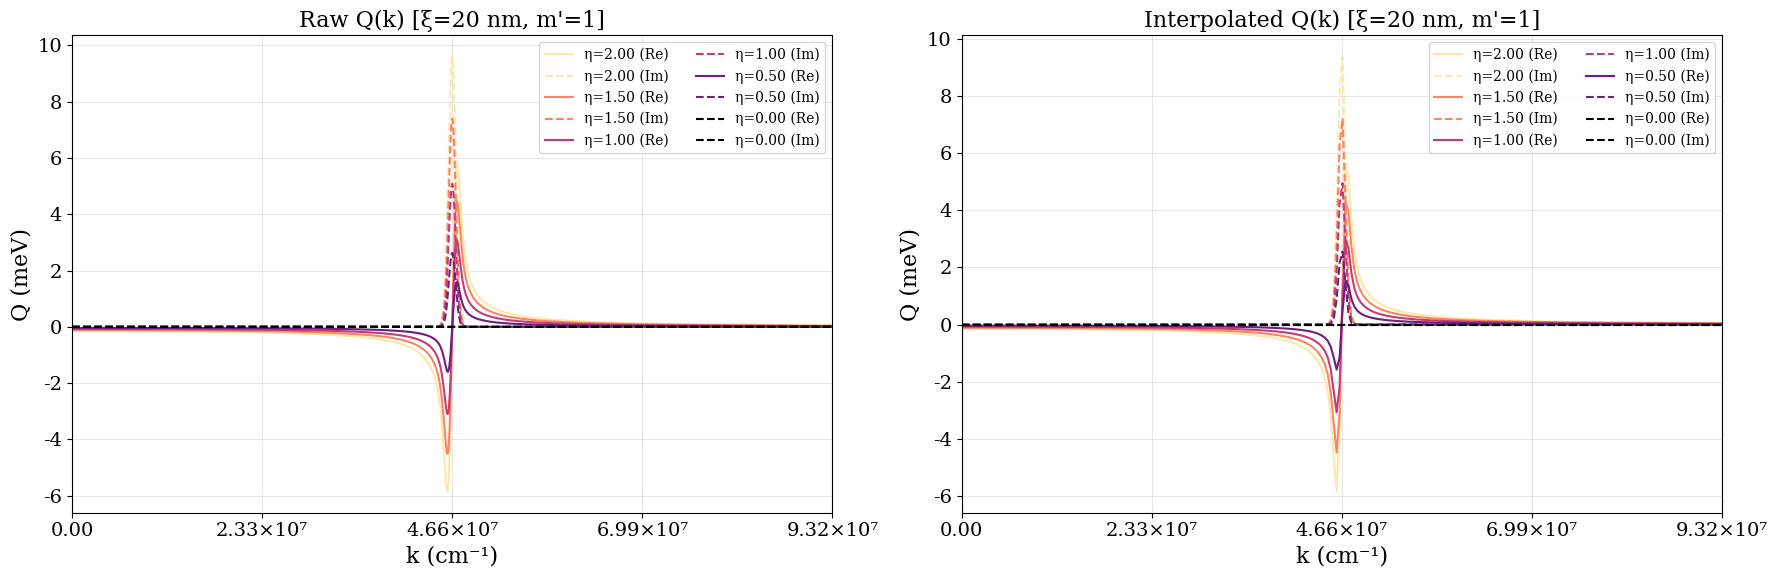

Saved  Plots/xi40nm_mprime1/Q_diagnostics_xi40nm_mprime1.pdf


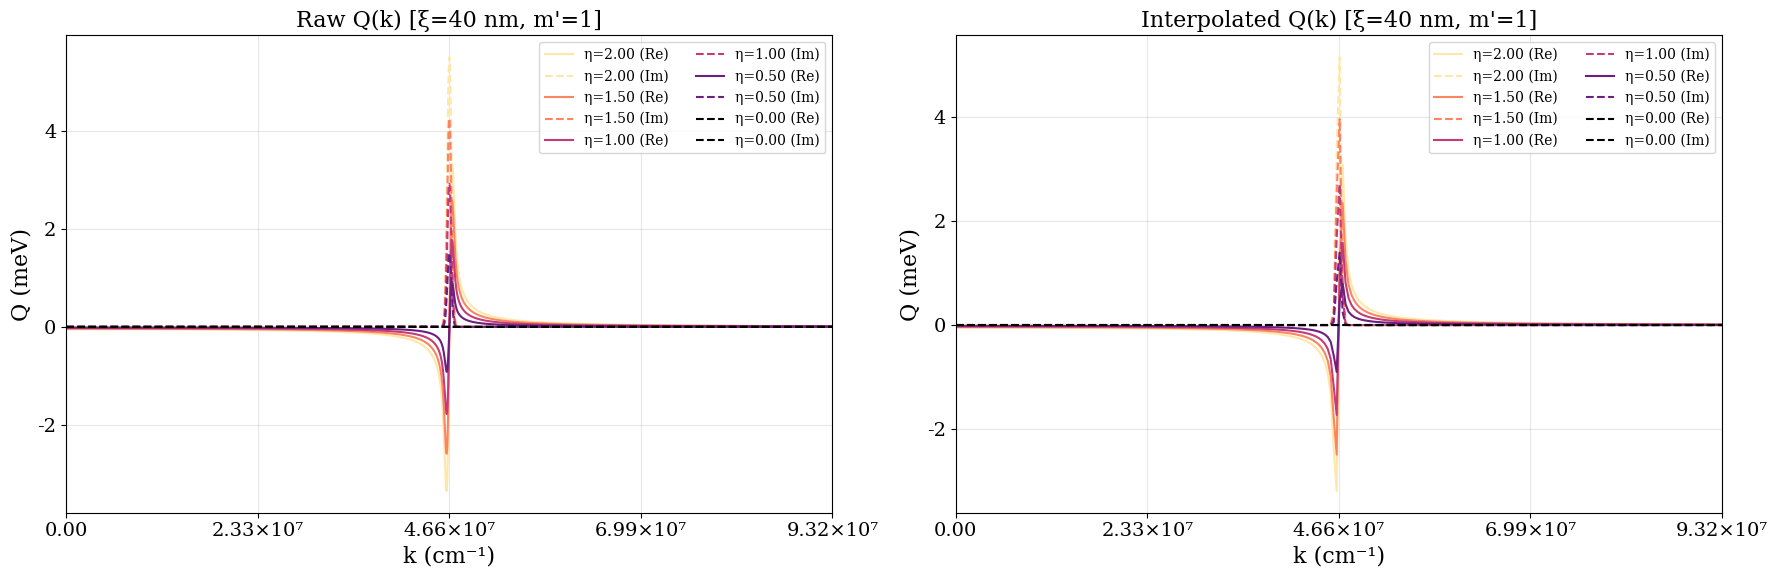

In [3]:
plot_eta_idx_base = [0, 5, 10, 15, 20]

for plot_context in plot_contexts:
	apply_context(plot_context)
	plot_eta_idx = eta_indices_descending([idx for idx in plot_eta_idx_base if idx < len(eta_grid)])
	q_positive = q_picard > 0.0
	q_plot_cm = k_nat_to_cm_array(q_picard[q_positive], p_nat)
	q_unit_values, q_unit_label, q_max_abs_eV = q_energy_values(Q_results[plot_eta_idx][:, q_positive], p_nat)

	fig, axs = plt.subplots(1, 2, figsize=(18, 6))

	for local_i, idx in enumerate(plot_eta_idx):
		eta_value = float(eta_grid[idx])
		real_color, real_linestyle = eta_line_style(idx, len(eta_grid), eta_value, linestyle="-")
		imag_color, imag_linestyle = eta_line_style(idx, len(eta_grid), eta_value, linestyle="--")
		lbl = f"η={eta_value:.2f}"
		axs[0].plot(q_plot_cm, np.real(q_unit_values[local_i]),
					color=real_color, linestyle=real_linestyle, label=f"{lbl} (Re)")
		axs[0].plot(q_plot_cm, np.imag(q_unit_values[local_i]),
					color=imag_color, linestyle=imag_linestyle, label=f"{lbl} (Im)")

		k_nat_test = np.linspace(first_positive_k, 0.9 * k_domain_max, 300)
		k_test_cm = k_nat_to_cm_array(k_nat_test, p_nat)
		Q_interp  = model.Q(k_nat_test, eta_grid[idx])
		Q_interp_unit = energy_nat_to_meV(Q_interp, p_nat) if q_unit_label == "meV" else energy_nat_to_eV(Q_interp, p_nat)
		axs[1].plot(k_test_cm, np.real(Q_interp_unit),
					color=real_color, linestyle=real_linestyle, label=f"{lbl} (Re)")
		axs[1].plot(k_test_cm, np.imag(Q_interp_unit),
					color=imag_color, linestyle=imag_linestyle, label=f"{lbl} (Im)")

	for ax, title in zip(axs, ["Raw Q(k)", "Interpolated Q(k)"]):
		ax.set_xlabel(f"k ({CM_INV_LABEL})")
		ax.set_ylabel(f"Q ({q_unit_label})")
		ax.set_title(f"{title} [{result_label_text}]")
		ax.legend(ncol=2, fontsize=10)
		ax.grid(alpha=0.3)
		apply_centered_critical_axis(ax, critical_k_cm_inv, decimals=2, fallback_xmax=float(ax.get_xlim()[1]), fallback_tick_count=5)
		format_plot_ticks(ax, axes="y")

	plt.tight_layout()
	save_figure(fig, f"Q_diagnostics_{result_slug_text}", meta={
		**context_metadata(plot_context),
		"eta_indices": plot_eta_idx,
		"Q_unit": q_unit_label,
		"Q_max_abs_eV": q_max_abs_eV,
	})
	plt.show()
	plt.close(fig)


## Kernel contour K(q,k)

Downsampled from the saved Picard kernel mesh, normalized by its maximum value, and plotted on a linear color scale.


Saved  Plots/nongaussian_mprime1/K_contour_nongaussian_mprime1.pdf


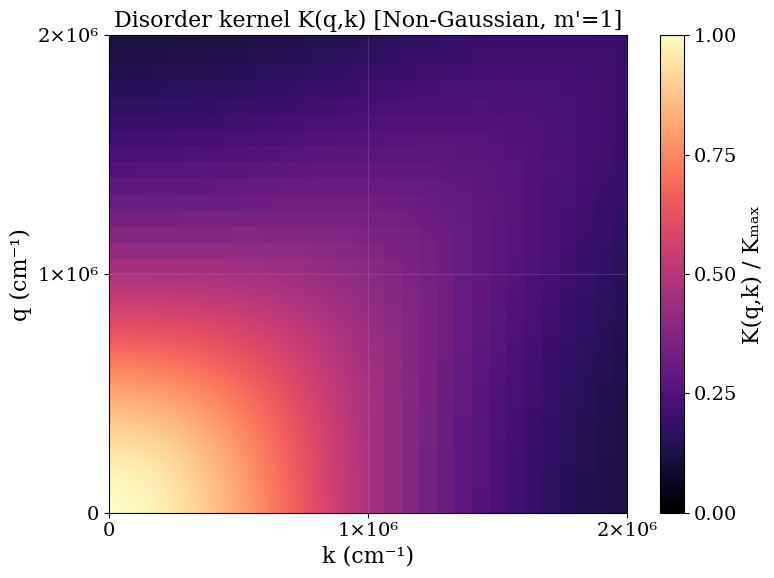

Saved  Plots/xi10nm_mprime1/K_contour_xi10nm_mprime1.pdf


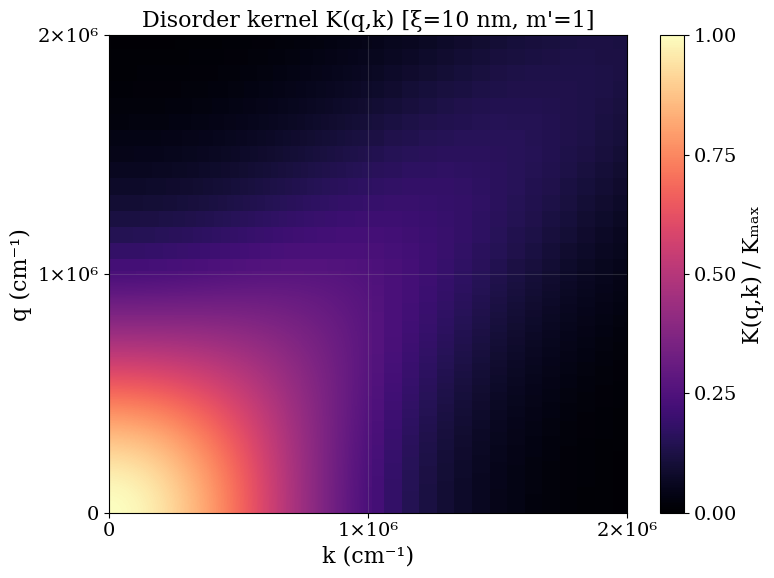

Saved  Plots/xi20nm_mprime1/K_contour_xi20nm_mprime1.pdf


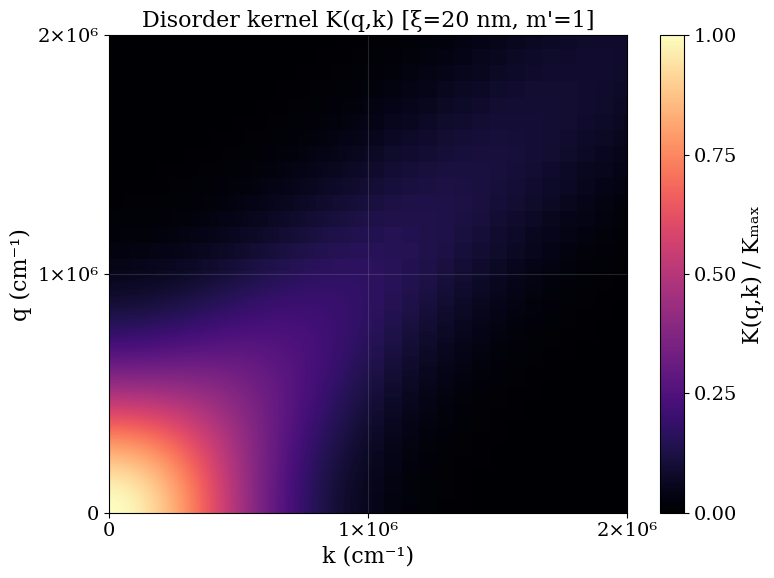

Saved  Plots/xi40nm_mprime1/K_contour_xi40nm_mprime1.pdf


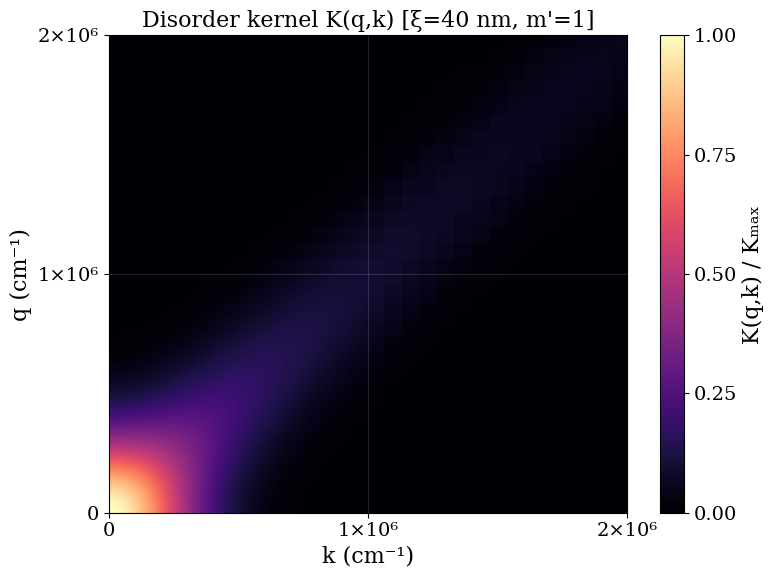

In [4]:
# Kernel contour plot K(q,k), downsampled from the saved Picard mesh.
K_CONTOUR_POINTS = 500
K_CONTOUR_MAX_CM = 2_000_000.0
K_CONTOUR_TICKS = [0, 1_000_000, 2_000_000, 3_000_000, 4_000_000, 5_000_000]
K_COLOR_TICKS = [0.0, 0.25, 0.50, 0.75, 1.0]

for plot_context in plot_contexts:
	apply_context(plot_context)
	if kernel_stem is None:
		print(f"Skipping K contour for {result_label_text}: no kernel_stem in Q metadata")
		continue

	K_mesh, k_meta = load_result("Results/integrand_meshes", kernel_stem)
	q_all = np.array(k_meta["q_picard"])
	q_window_max = float(k_cm_to_nat(K_CONTOUR_MAX_CM, p_nat))
	window_idx = np.flatnonzero(q_all <= q_window_max)
	if window_idx.size < 2:
		raise ValueError(f"K contour for {result_label_text} has fewer than two grid points below {K_CONTOUR_MAX_CM:g} {CM_INV_LABEL}.")

	stride = max(1, int(np.ceil(window_idx.size / K_CONTOUR_POINTS)))
	idx = np.unique(np.r_[window_idx[::stride], window_idx[-1]])
	K_small = np.asarray(K_mesh[np.ix_(idx, idx)], dtype=float)
	finite = K_small[np.isfinite(K_small)]
	if finite.size == 0:
		raise ValueError(f"K contour for {result_label_text} requires at least one finite kernel value.")
	K_max = float(np.nanmax(finite))
	if K_max <= 0.0:
		raise ValueError(f"K contour for {result_label_text} requires a positive kernel maximum.")
	K_plot = np.clip(K_small / K_max, 0.0, 1.0)
	q_kernel = q_all[idx]
	q_kernel_cm = k_nat_to_cm_array(q_kernel, p_nat)

	fig, ax = plt.subplots(figsize=(8, 6))
	mesh = ax.pcolormesh(q_kernel_cm, q_kernel_cm, K_plot, shading="auto", cmap=CMAP_NAME, vmin=0.0, vmax=1.0)
	cbar = plt.colorbar(mesh, ax=ax, label="K(q,k) / Kₘₐₓ")
	cbar.set_ticks(K_COLOR_TICKS)
	cbar.set_ticklabels([f"{value:.2f}" for value in K_COLOR_TICKS])
	ax.set_xlabel(f"k ({CM_INV_LABEL})")
	ax.set_ylabel(f"q ({CM_INV_LABEL})")
	ax.set_xlim(0.0, K_CONTOUR_MAX_CM)
	ax.set_ylim(0.0, K_CONTOUR_MAX_CM)
	ax.set_title(f"Disorder kernel K(q,k) [{result_label_text}]")
	format_plot_ticks(ax, axes=("x", "y"), ticks=K_CONTOUR_TICKS, formatter="power")
	ax.grid(alpha=0.2)
	plt.tight_layout()
	save_figure(fig, f"K_contour_{result_slug_text}", meta={
		**context_metadata(plot_context),
		"downsample_stride": int(stride),
		"points": int(len(idx)),
		"norm": "max",
		"kernel_max": K_max,
		"k_max_cm_inv": K_CONTOUR_MAX_CM,
		"q_max_cm_inv": K_CONTOUR_MAX_CM,
	})
	plt.show()
	plt.close(fig)


## Exciton energy at k=0 vs disorder strength


Saved  Plots/nongaussian_mprime1/Eex_k0_vs_eta_nongaussian_mprime1.pdf


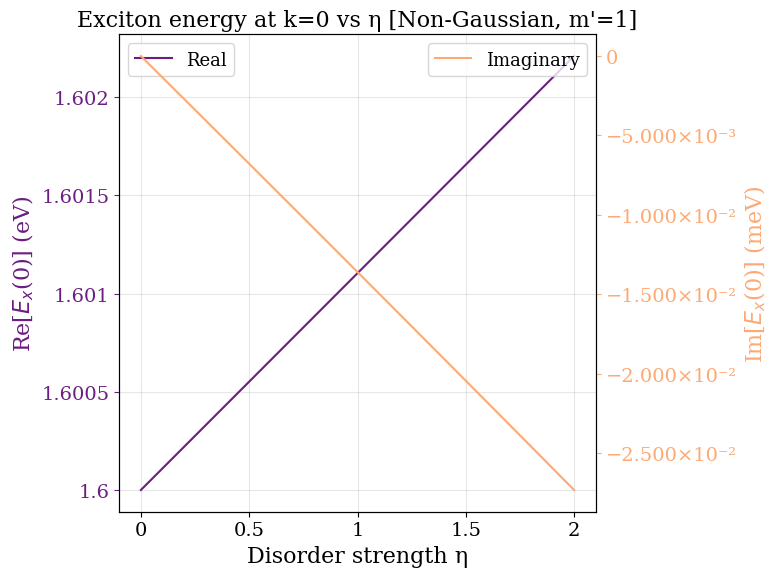

Saved  Plots/xi10nm_mprime1/Eex_k0_vs_eta_xi10nm_mprime1.pdf


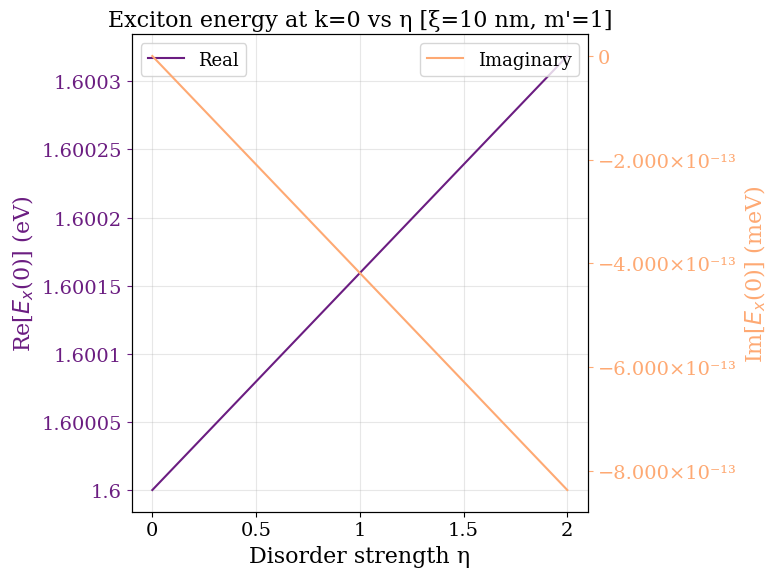

Saved  Plots/xi20nm_mprime1/Eex_k0_vs_eta_xi20nm_mprime1.pdf


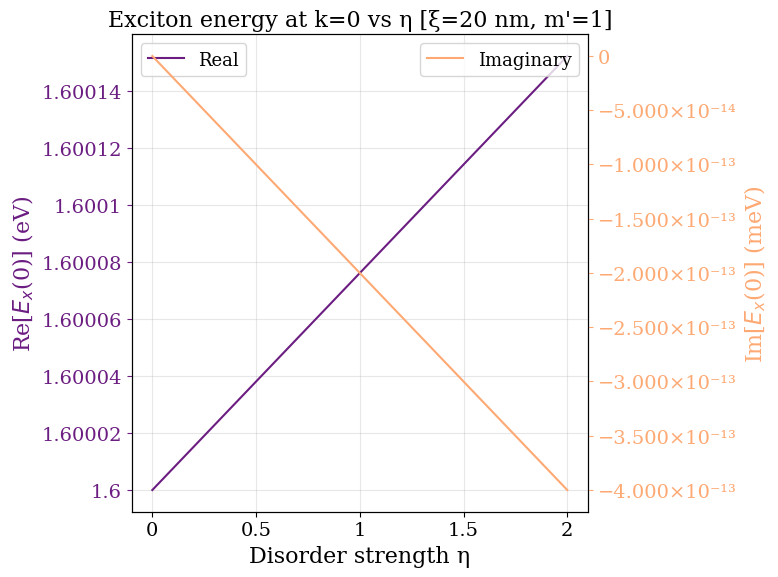

Saved  Plots/xi40nm_mprime1/Eex_k0_vs_eta_xi40nm_mprime1.pdf


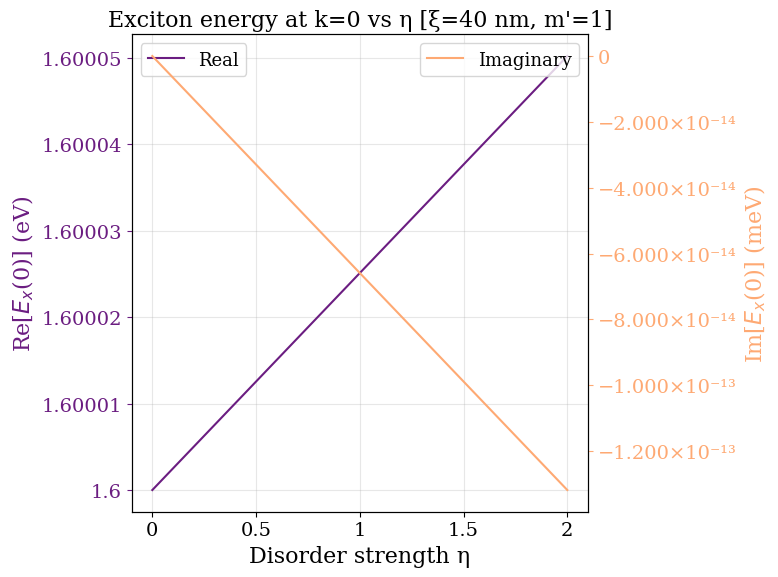

In [5]:
for plot_context in plot_contexts:
	apply_context(plot_context)
	E_ex_k0 = np.array([model.E_ex(np.array([0.0]), eta)[0] for eta in eta_grid])
	E_real_eV = energy_nat_to_eV(np.real(E_ex_k0), p_nat)
	E_imag_meV = energy_nat_to_meV(np.imag(E_ex_k0), p_nat)

	fig, ax = plt.subplots(figsize=(8, 6))
	ax_r = ax.twinx()

	real_color = CMAP(0.32)
	imag_color = CMAP(0.82)
	ax.plot(eta_grid, E_real_eV, color=real_color, label="Real")
	ax_r.plot(eta_grid, E_imag_meV, color=imag_color, label="Imaginary")

	ax.set_xlabel("Disorder strength η")
	ax.set_ylabel(r"Re[$E_x$(0)] (eV)", color=real_color)
	ax_r.set_ylabel(r"Im[$E_x$(0)] (meV)", color=imag_color)
	ax.tick_params(axis='y', colors=real_color)
	ax_r.tick_params(axis='y', colors=imag_color)
	ax.set_title(f"Exciton energy at k=0 vs η [{result_label_text}]")
	format_plot_ticks(ax)
	hide_axis_offset(ax_r)
	format_plot_ticks(ax_r, axes="y", formatter="fixed_power", decimals=3, zero_tol=0.0)
	ax.grid(alpha=0.3)
	ax.legend(loc="upper left"); ax_r.legend(loc="upper right")
	plt.tight_layout()
	save_figure(fig, f"Eex_k0_vs_eta_{result_slug_text}", meta=context_metadata(plot_context))
	plt.show()
	plt.close(fig)


## Dispersion relations

Exciton and photon dispersion for a selected disorder value, and full
exciton / LP dispersions for all η.


Saved  Plots/nongaussian_mprime1/dispersion_nongaussian_mprime1_disorder_tuned_cavity.pdf


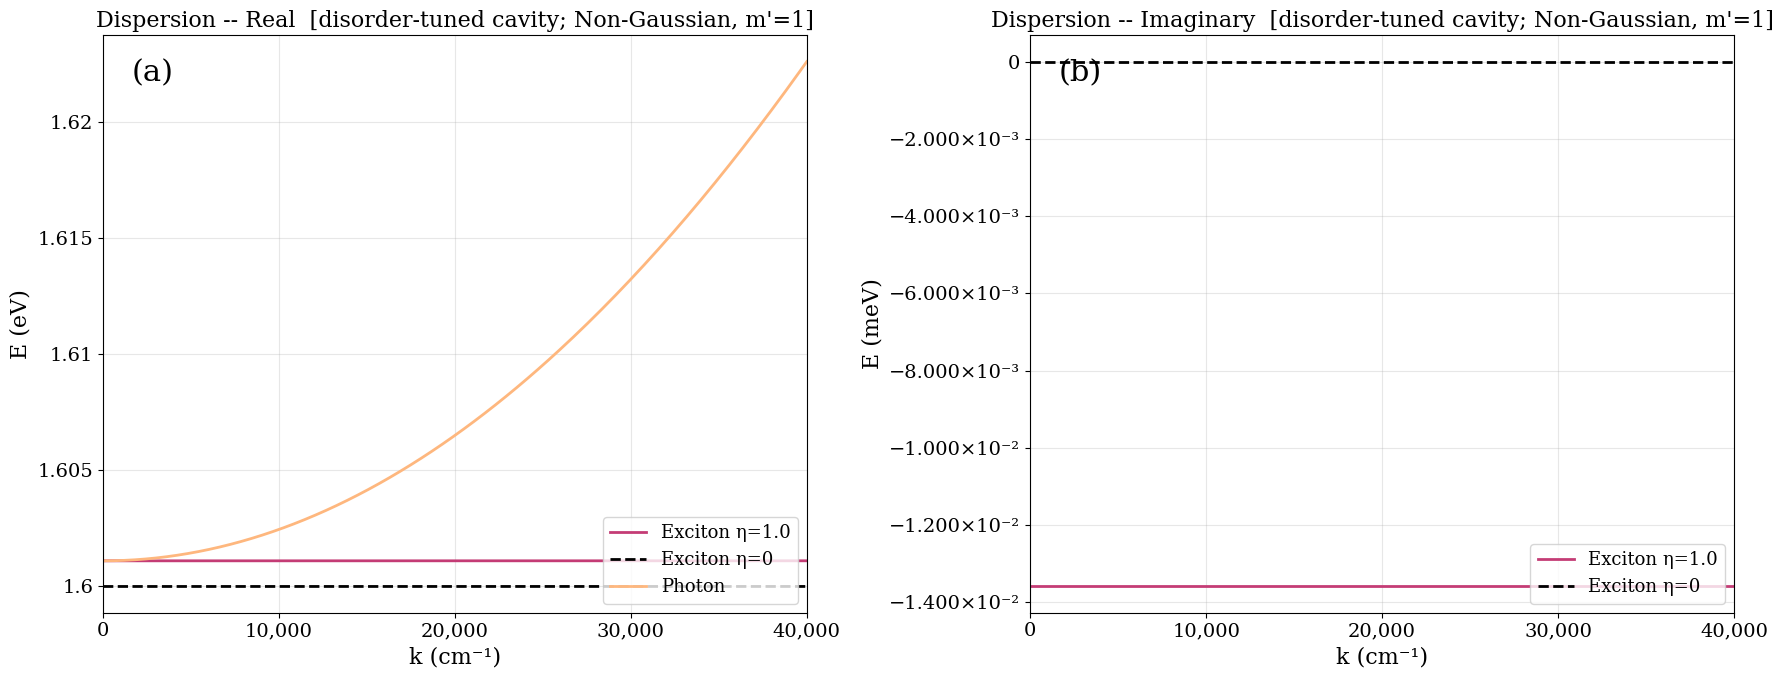

Saved  Plots/nongaussian_mprime1/dispersion_nongaussian_mprime1_disorder_free_cavity.pdf


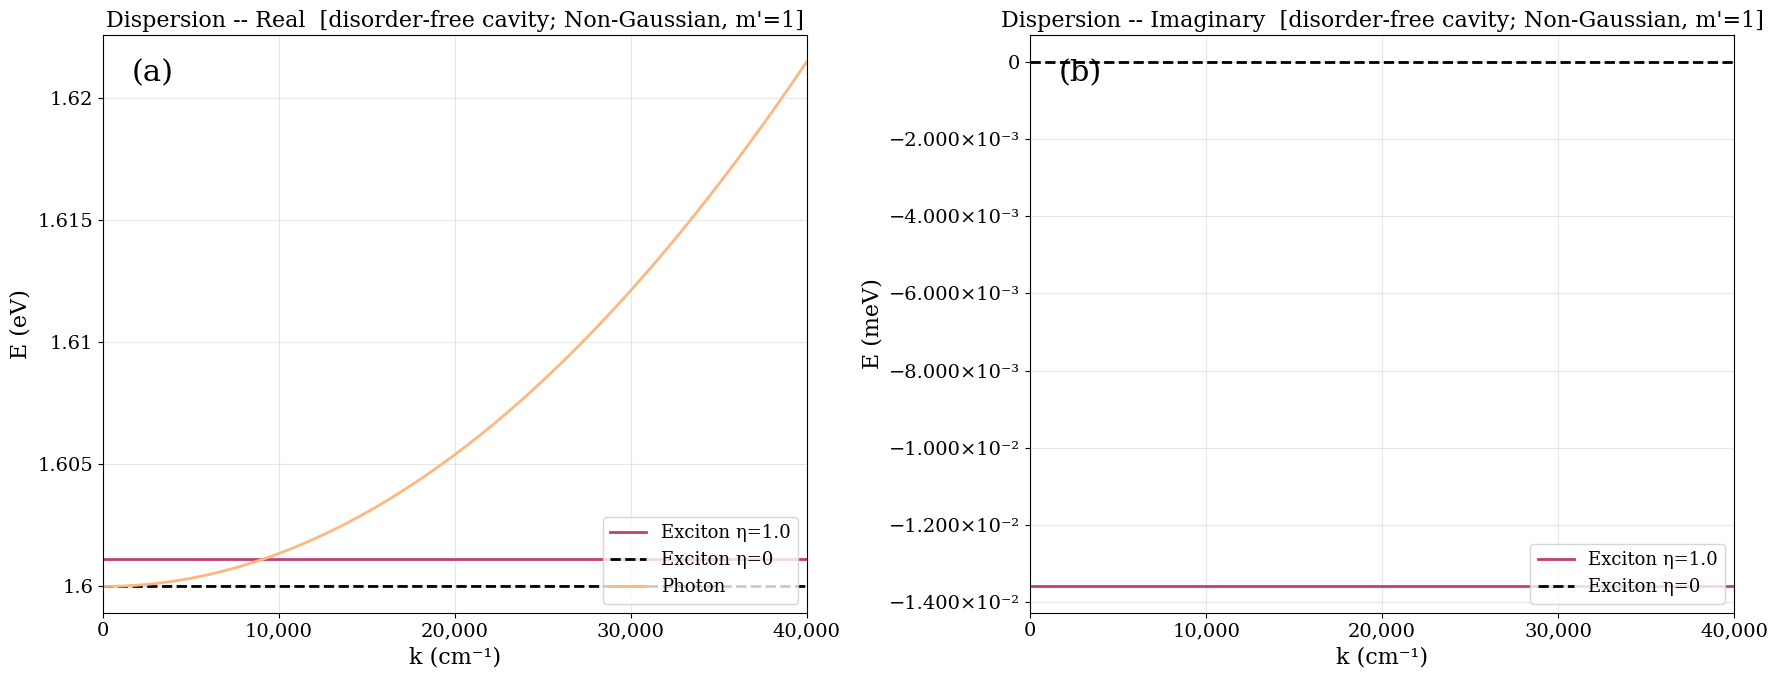

Saved  Plots/xi10nm_mprime1/dispersion_xi10nm_mprime1_disorder_tuned_cavity.pdf


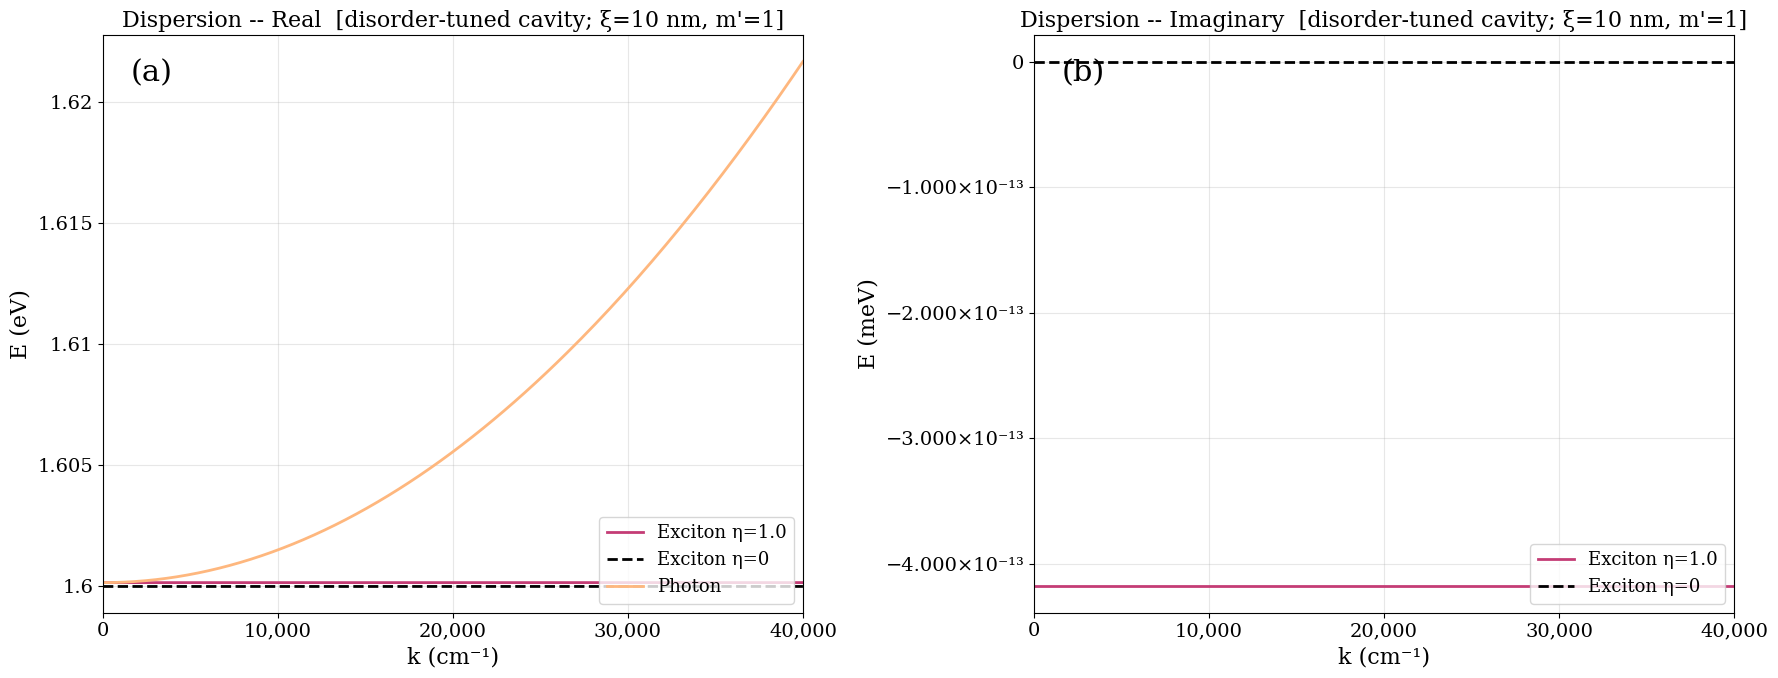

Saved  Plots/xi10nm_mprime1/dispersion_xi10nm_mprime1_disorder_free_cavity.pdf


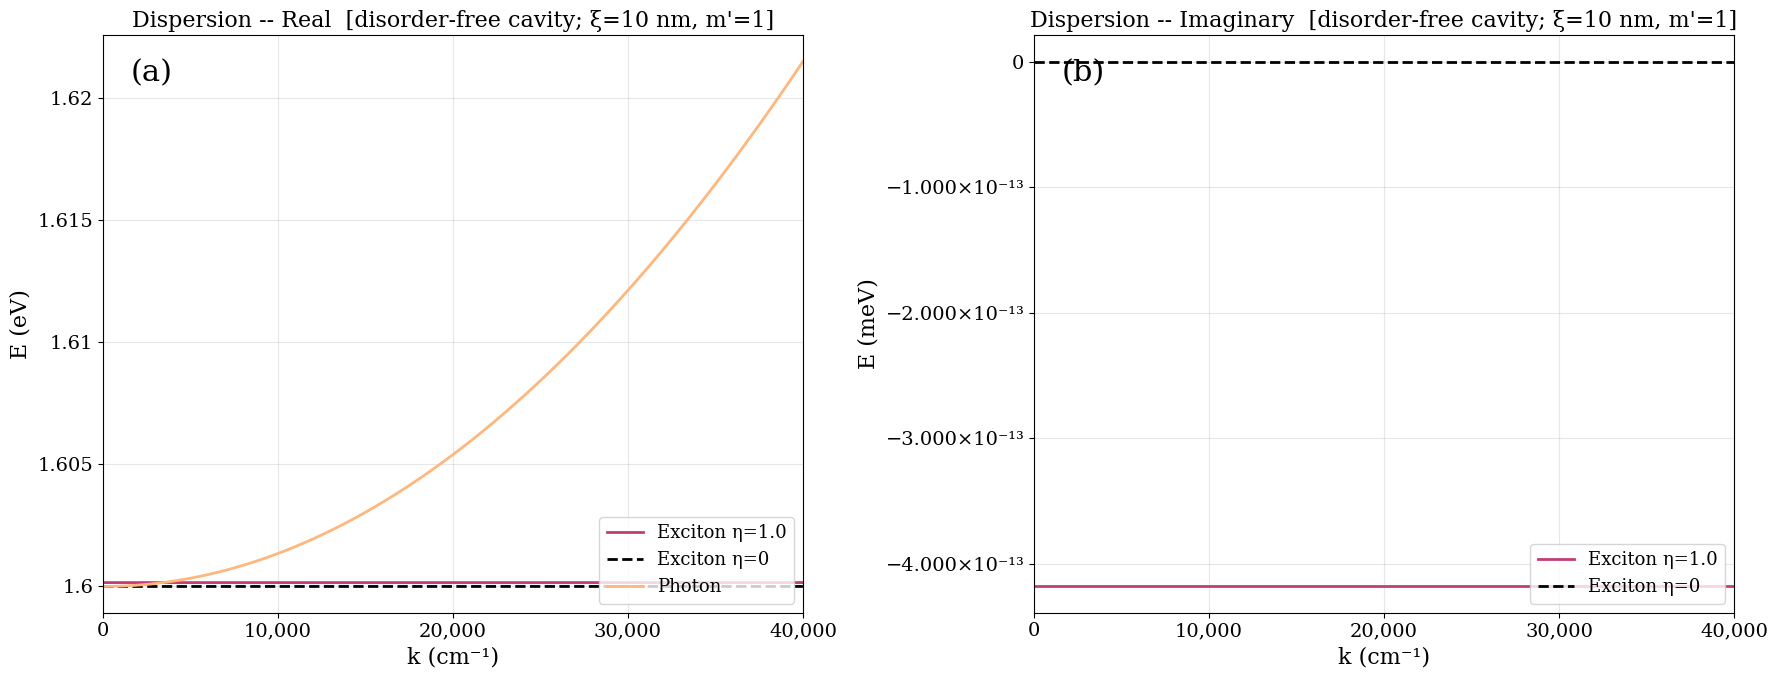

Saved  Plots/xi20nm_mprime1/dispersion_xi20nm_mprime1_disorder_tuned_cavity.pdf


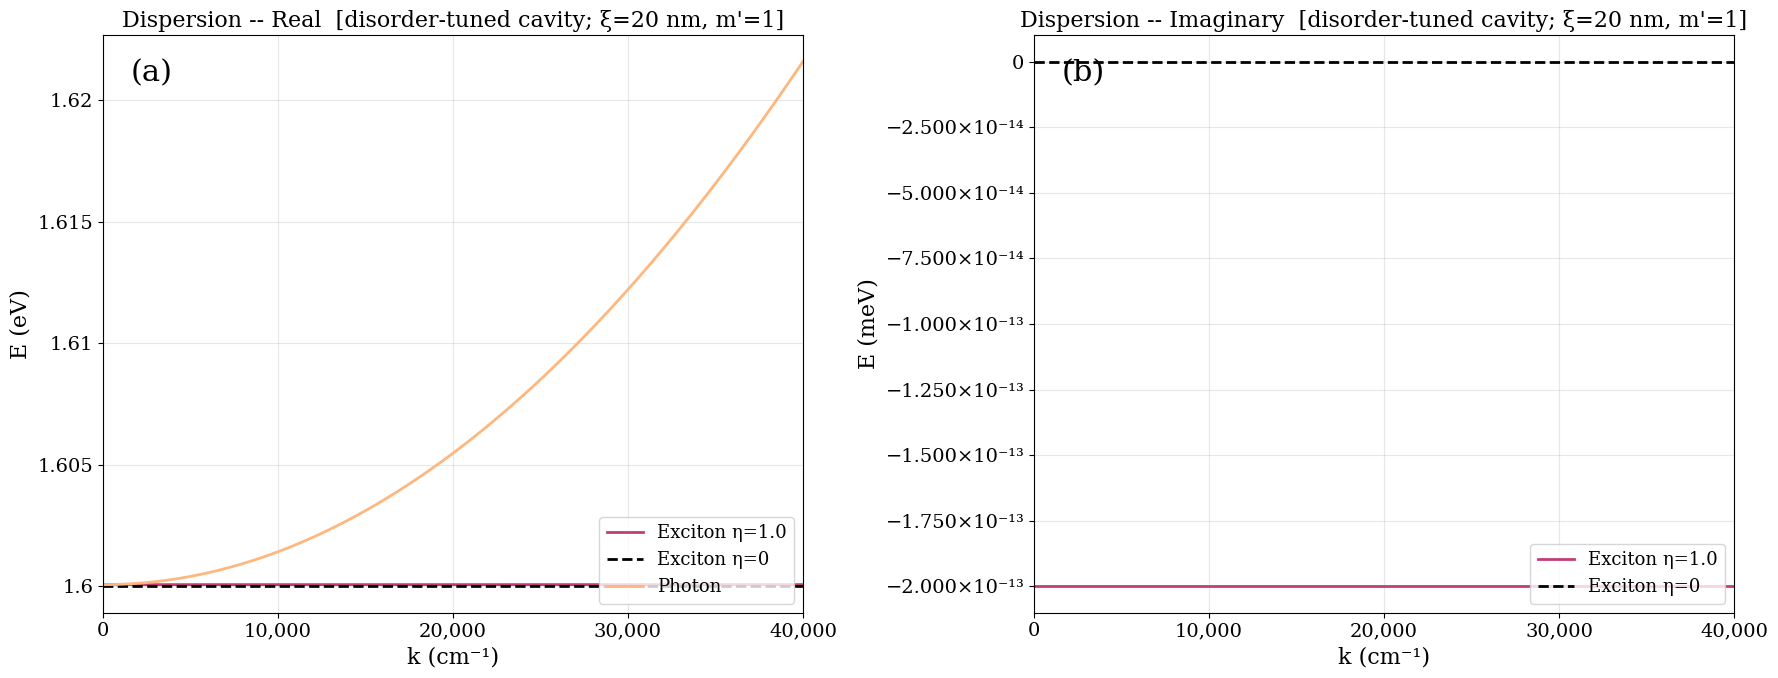

Saved  Plots/xi20nm_mprime1/dispersion_xi20nm_mprime1_disorder_free_cavity.pdf


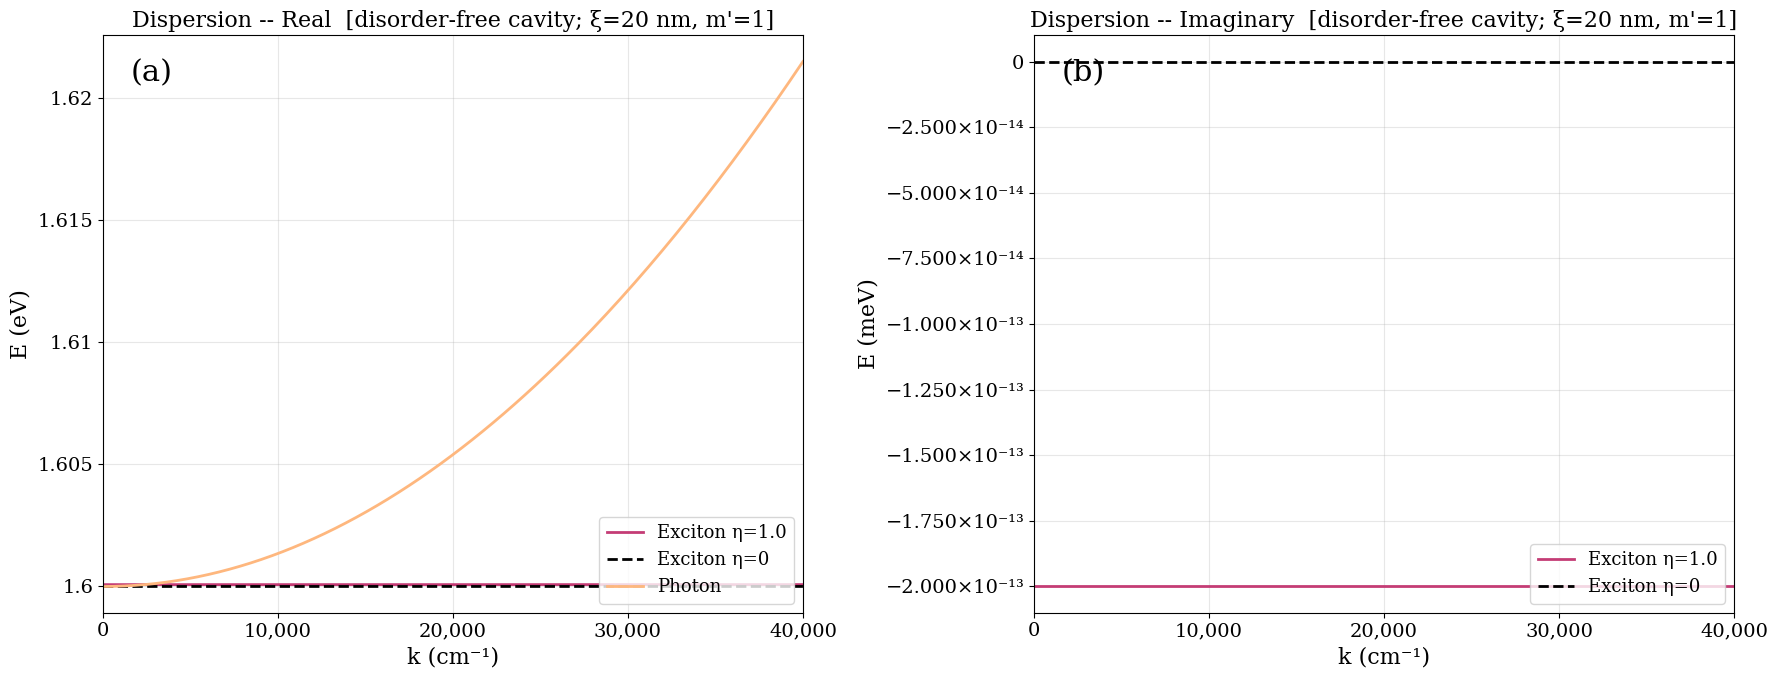

Saved  Plots/xi40nm_mprime1/dispersion_xi40nm_mprime1_disorder_tuned_cavity.pdf


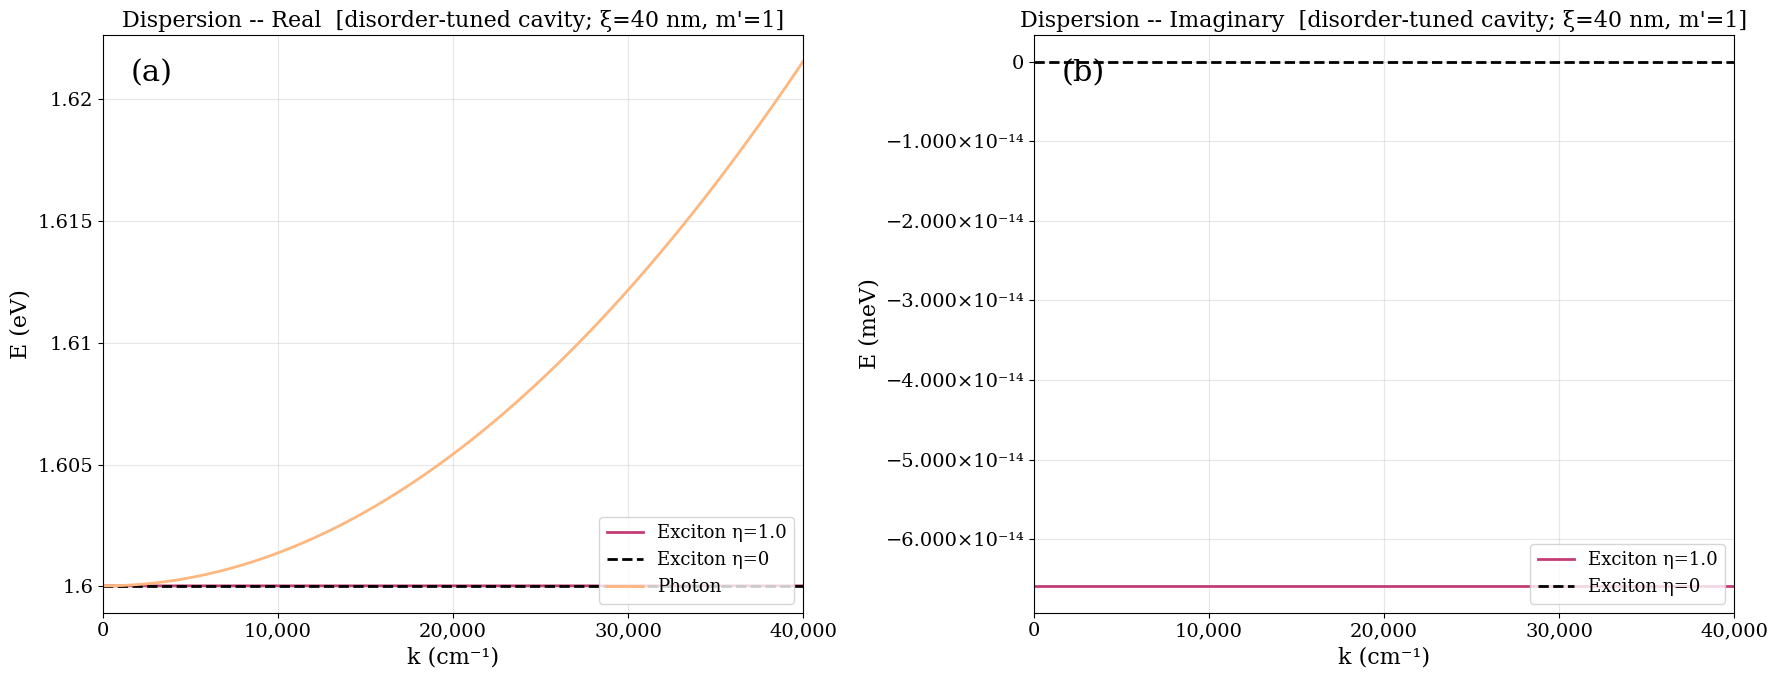

Saved  Plots/xi40nm_mprime1/dispersion_xi40nm_mprime1_disorder_free_cavity.pdf


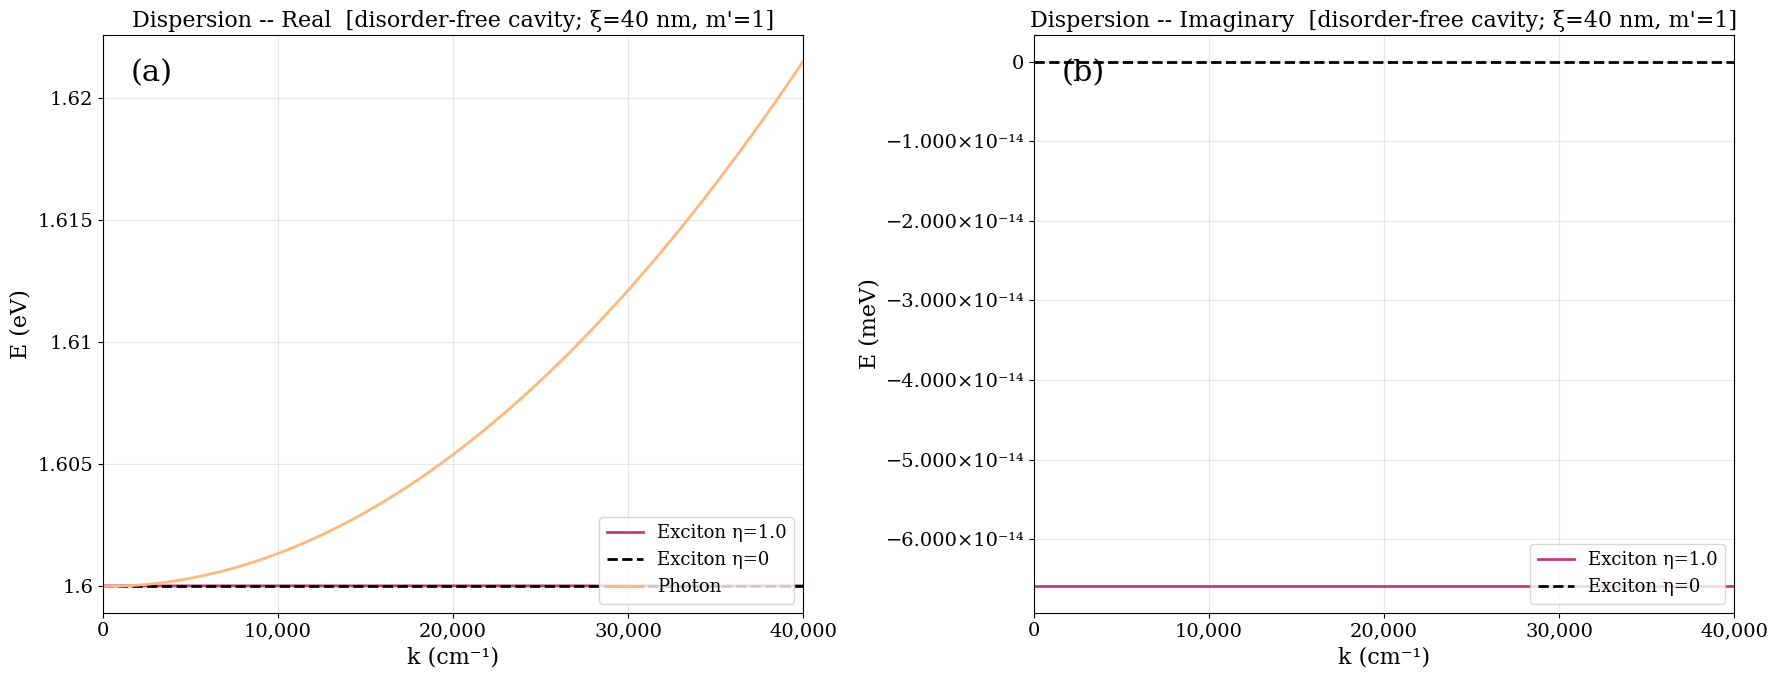

In [6]:
for plot_context in plot_contexts:
	apply_context(plot_context)
	eta_probe_idx = min(10, len(eta_grid) - 1)
	eta_probe = eta_grid[eta_probe_idx]
	k_cm = k_disp_cm

	E_ex_probe = model.E_ex(k_disp, eta_probe)
	E_ex_clean = model.E_ex(k_disp, 0.0)
	probe_color, probe_linestyle = eta_line_style(eta_probe_idx, len(eta_grid), float(eta_probe), linestyle="-")
	clean_color, clean_linestyle = eta_line_style(0, len(eta_grid), 0.0, linestyle="-")

	for tuned in (True, False):
		suffix = cavity_label(tuned)
		E_ph_use = model.E_ph(k_disp, eta_probe) if tuned else model.E_ph_untuned(k_disp)

		fig, axs = plt.subplots(1, 2, figsize=(18, 7))
		axs[0].plot(k_cm, energy_nat_to_eV(np.real(E_ex_probe), p_nat), color=probe_color, linestyle=probe_linestyle, lw=2, label=f"Exciton η={eta_probe:.1f}")
		axs[0].plot(k_cm, energy_nat_to_eV(np.real(E_ex_clean), p_nat), color=clean_color, linestyle=clean_linestyle, lw=2, label="Exciton η=0")
		axs[0].plot(k_cm, energy_nat_to_eV(E_ph_use, p_nat), color=CMAP(0.85), lw=2, label="Photon")
		axs[1].plot(k_cm, energy_nat_to_meV(np.imag(E_ex_probe), p_nat), color=probe_color, linestyle=probe_linestyle, lw=2, label=f"Exciton η={eta_probe:.1f}")
		axs[1].plot(k_cm, energy_nat_to_meV(np.imag(E_ex_clean), p_nat), color=clean_color, linestyle=clean_linestyle, lw=2, label="Exciton η=0")

		for ax in axs:
			ax.set_xlabel(f"k ({CM_INV_LABEL})")
			ax.legend(loc="lower right")
			ax.grid(alpha=0.3)
			ax.set_xlim(0.0, 40_000.0)
			format_plot_ticks(ax, axes="x", ticks=[0, 10_000, 20_000, 30_000, 40_000])
			format_plot_ticks(ax, axes="y")
		axs[0].set_ylabel("E (eV)")
		axs[1].set_ylabel("E (meV)")
		format_plot_ticks(axs[1], axes="y", formatter="fixed_power", decimals=3, zero_tol=0.0)
		axs[0].set_title(f"Dispersion -- Real  [{suffix}; {result_label_text}]")
		axs[1].set_title(f"Dispersion -- Imaginary  [{suffix}; {result_label_text}]")
		axs[0].text(0.04, 0.92, "(a)", transform=axs[0].transAxes, fontsize=22)
		axs[1].text(0.04, 0.92, "(b)", transform=axs[1].transAxes, fontsize=22)

		plt.tight_layout()
		save_figure(fig, f"dispersion_{result_slug_text}_{cavity_slug(tuned)}_cavity", meta={
			**context_metadata(plot_context),
			"eta_probe": float(eta_probe),
			"disorder_tuned": tuned,
		})
		plt.show()
		plt.close(fig)


## Lower polariton dispersion — all η


Saved  Plots/nongaussian_mprime1/LP_dispersion_nongaussian_mprime1_disorder_tuned.pdf


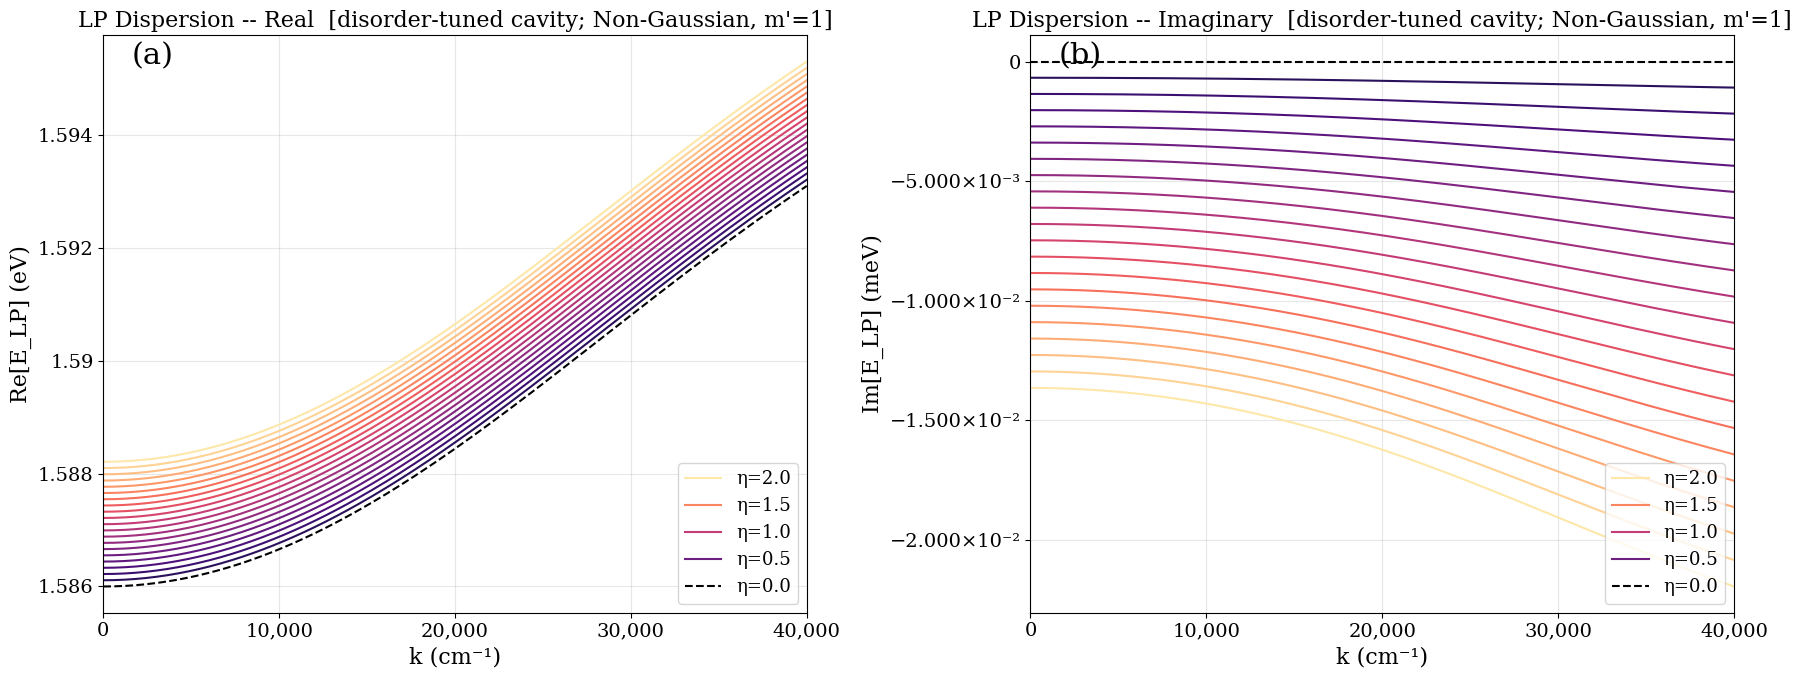

Saved  Plots/nongaussian_mprime1/LP_dispersion_nongaussian_mprime1_disorder_free.pdf


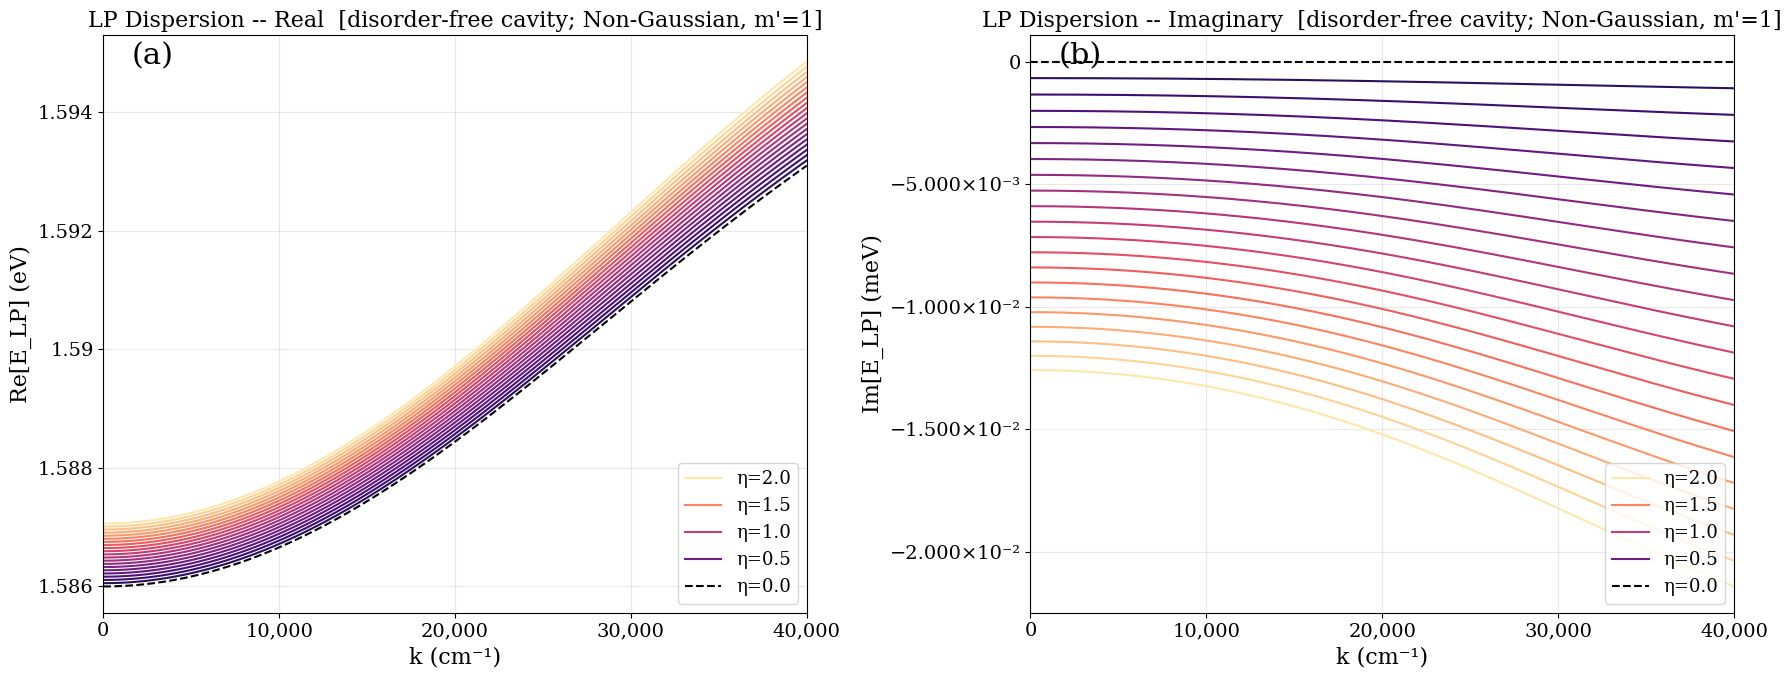

Saved  Plots/xi10nm_mprime1/LP_dispersion_xi10nm_mprime1_disorder_tuned.pdf


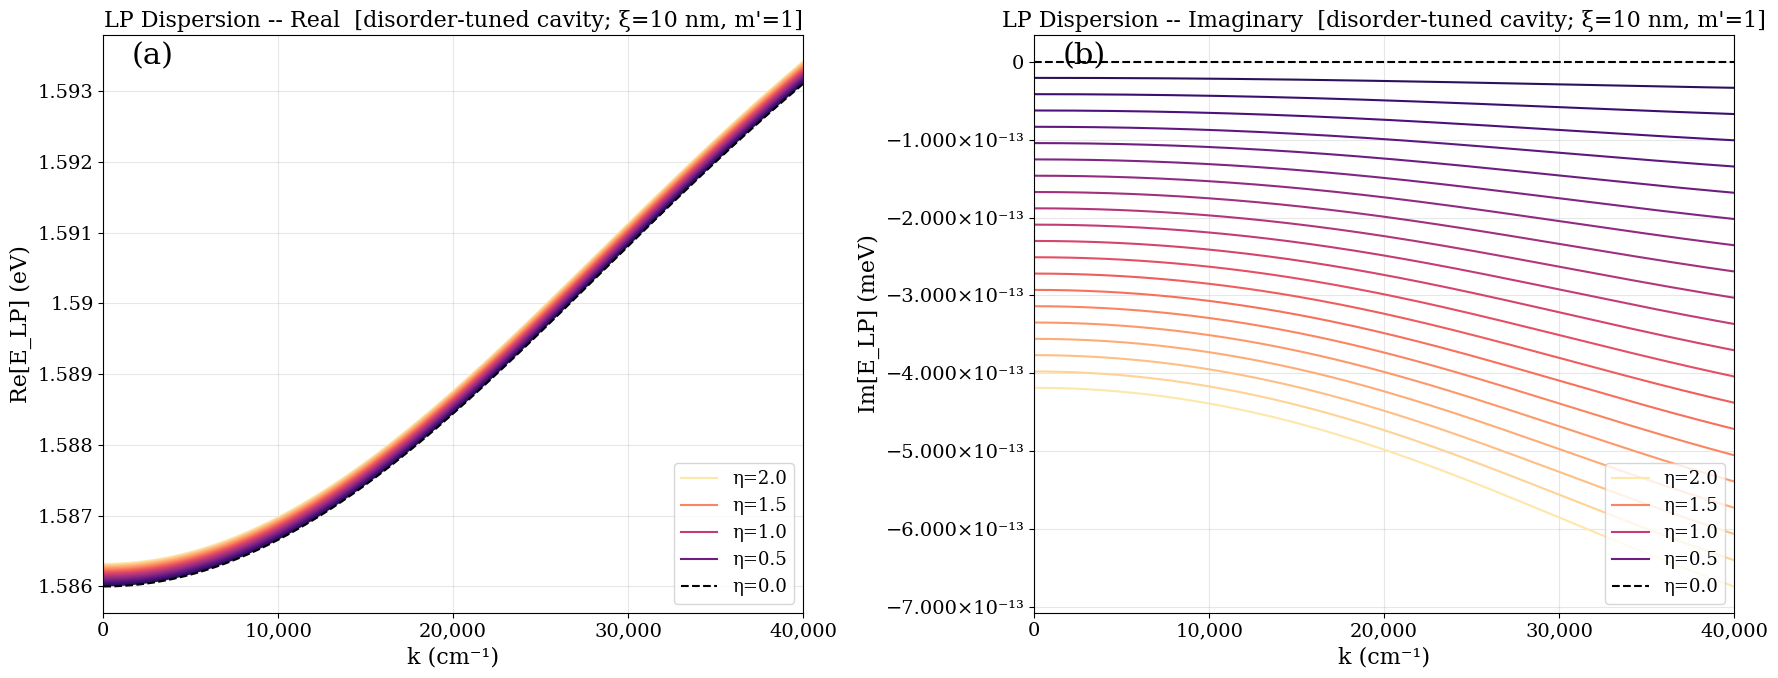

Saved  Plots/xi10nm_mprime1/LP_dispersion_xi10nm_mprime1_disorder_free.pdf


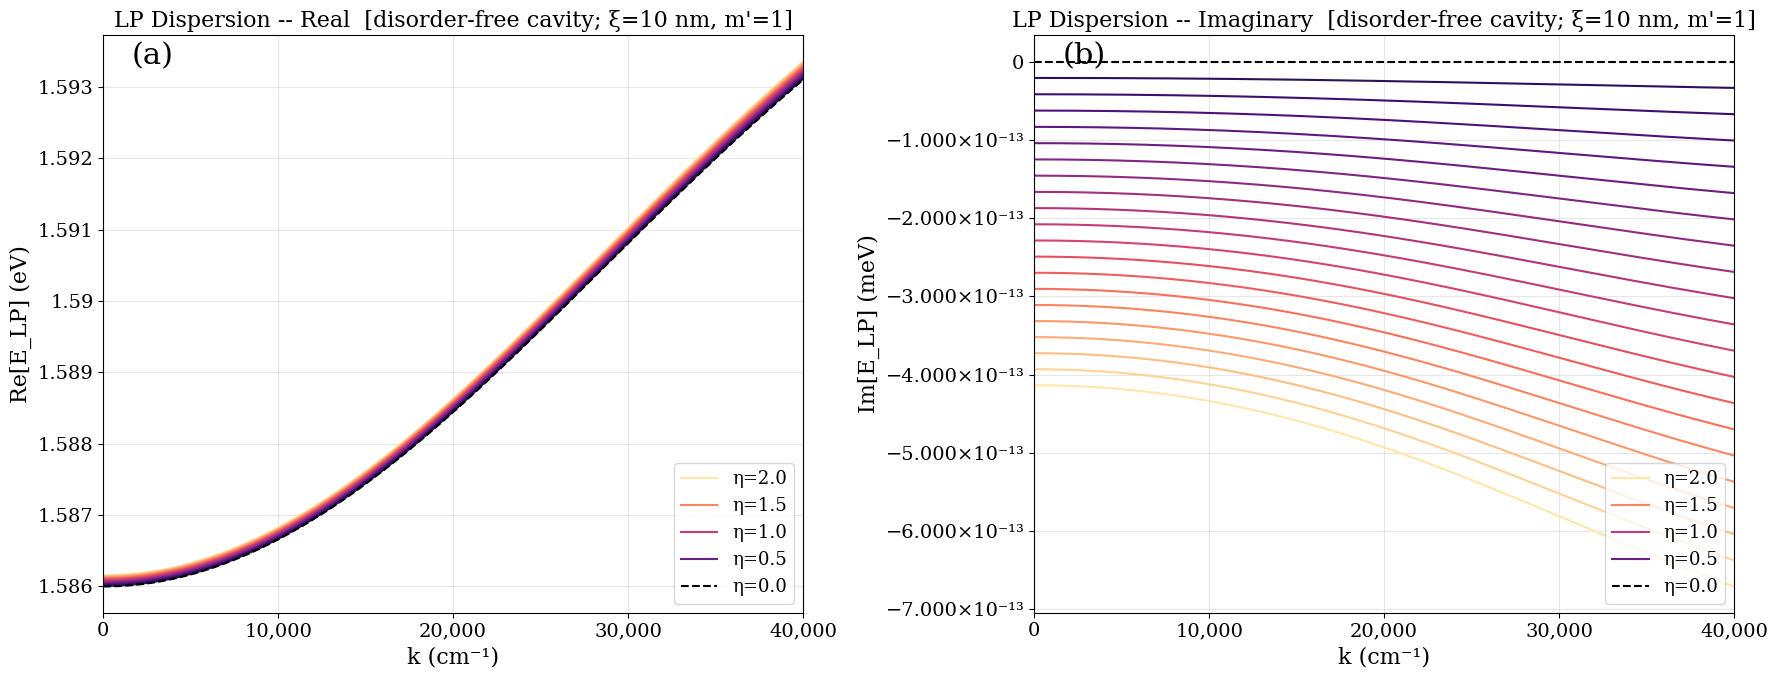

Saved  Plots/xi20nm_mprime1/LP_dispersion_xi20nm_mprime1_disorder_tuned.pdf


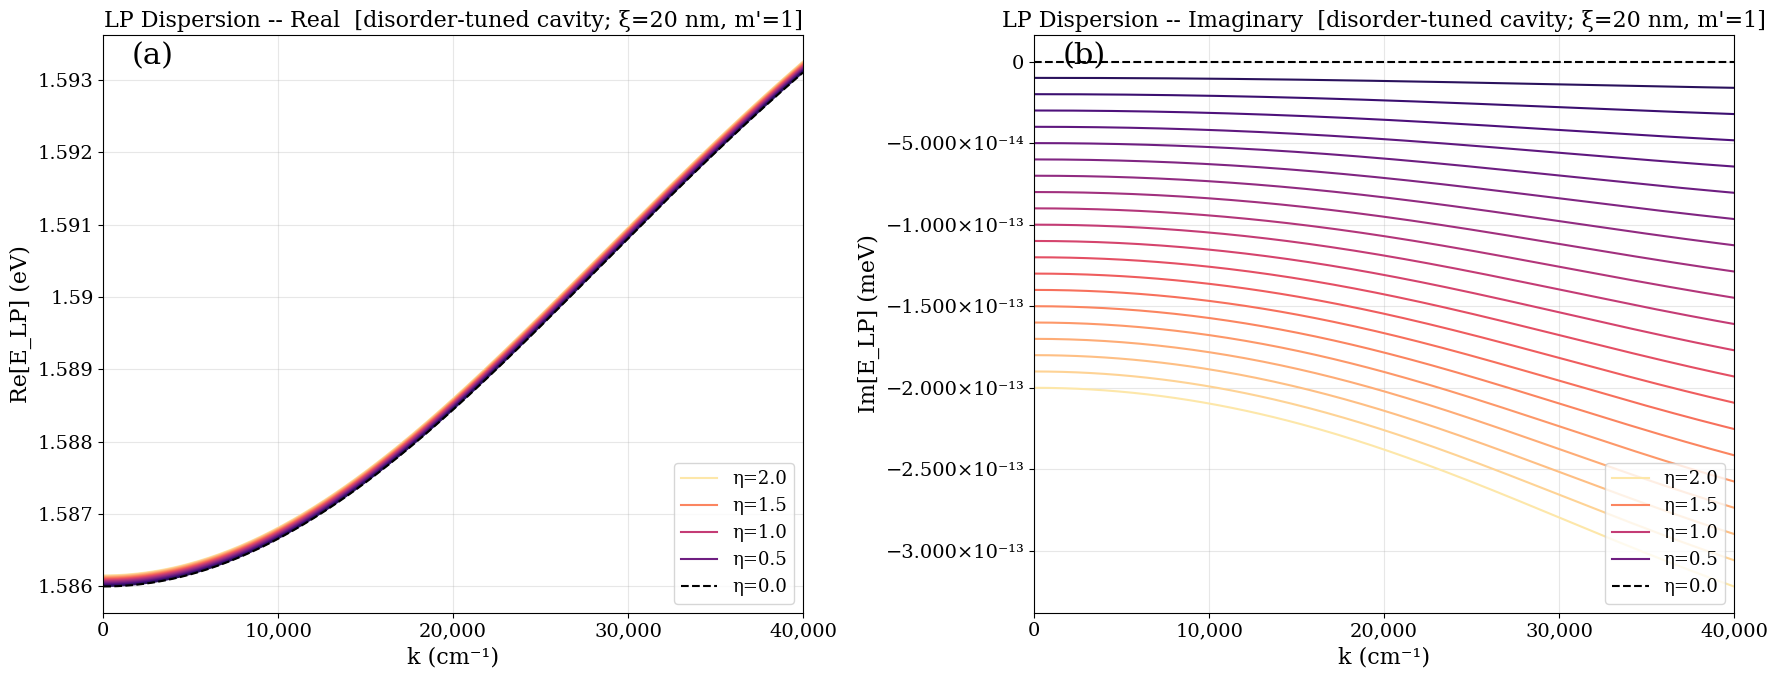

Saved  Plots/xi20nm_mprime1/LP_dispersion_xi20nm_mprime1_disorder_free.pdf


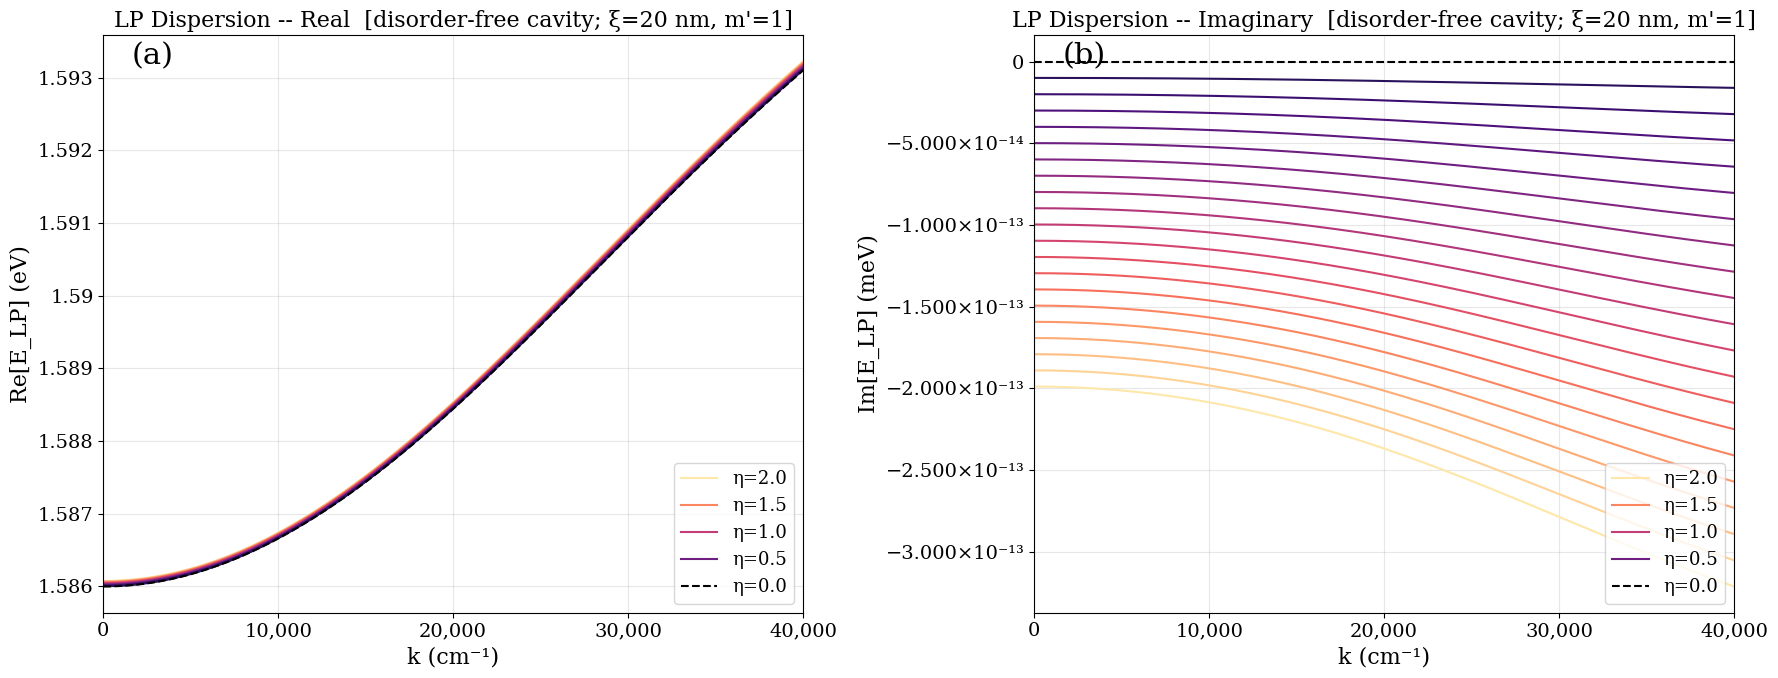

Saved  Plots/xi40nm_mprime1/LP_dispersion_xi40nm_mprime1_disorder_tuned.pdf


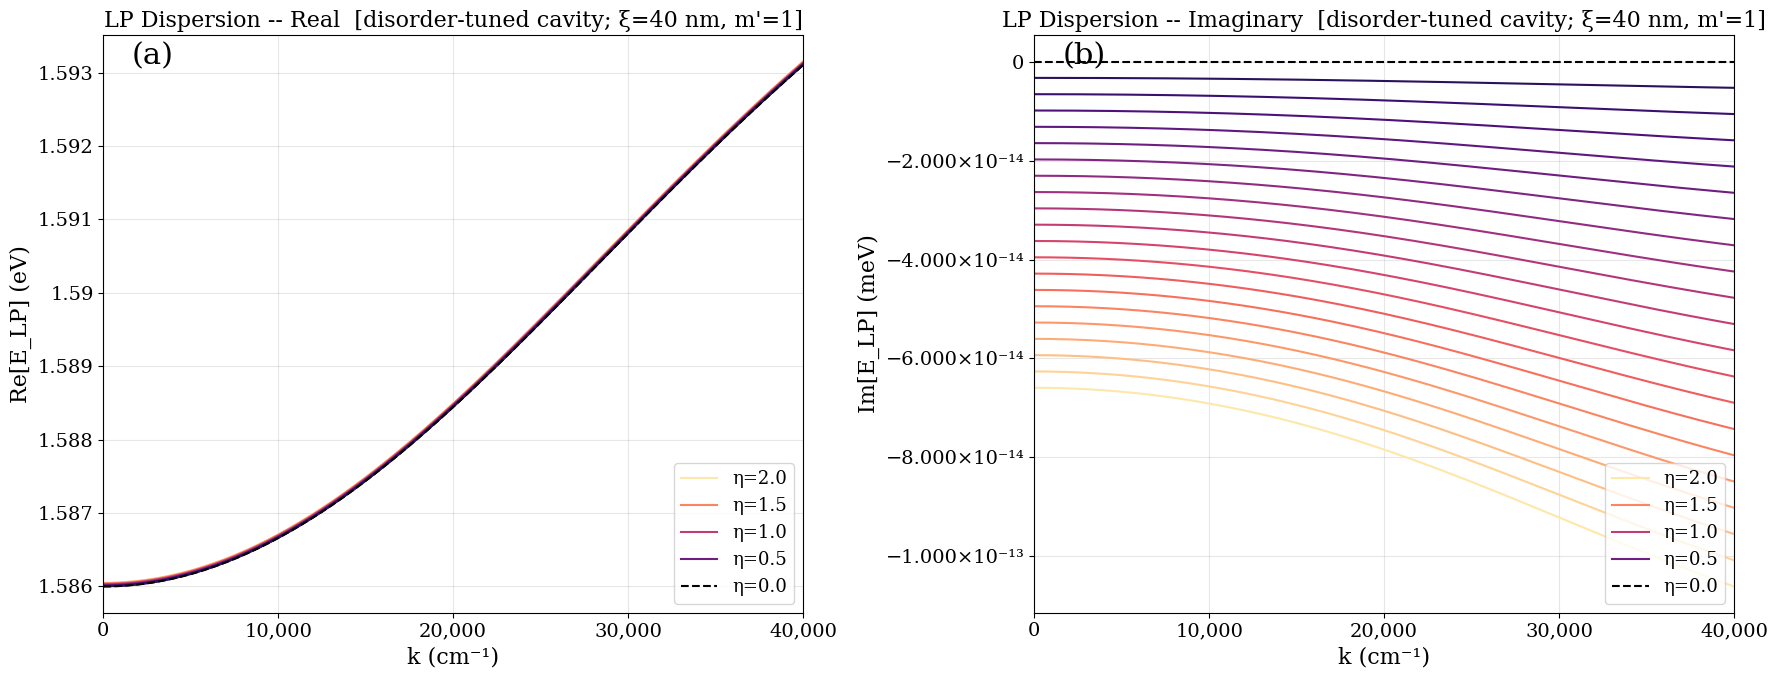

Saved  Plots/xi40nm_mprime1/LP_dispersion_xi40nm_mprime1_disorder_free.pdf


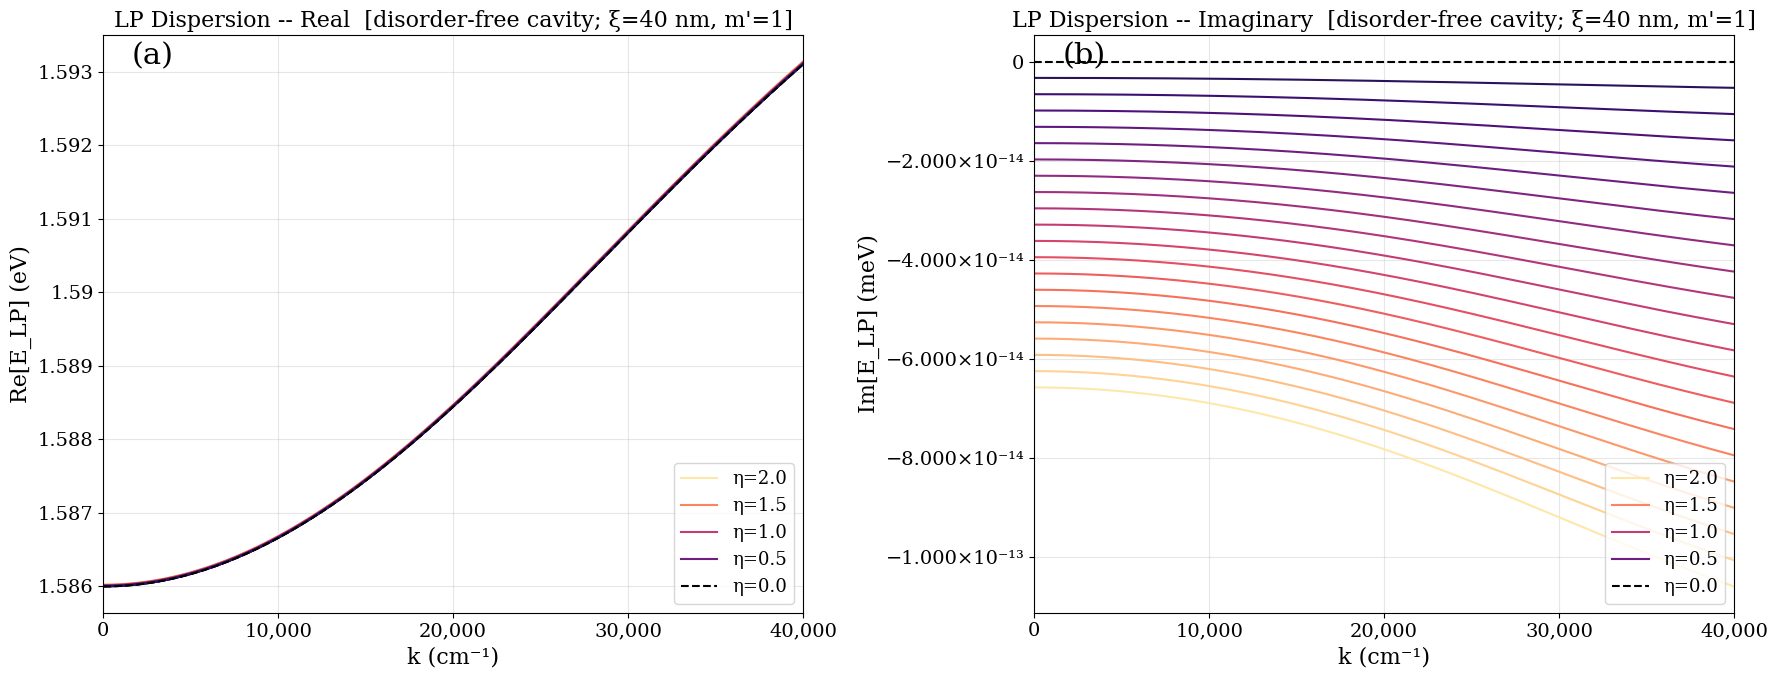

In [7]:
legend_etas = [0.0, 0.5, 1.0, 1.5, 2.0]

for plot_context in plot_contexts:
	apply_context(plot_context)
	for tuned in (True, False):
		label = cavity_label(tuned)
		fig, axs = plt.subplots(1, 2, figsize=(18, 7))
		for ei in eta_indices_descending():
			eta = float(eta_grid[ei])
			clr, linestyle = eta_line_style(ei, len(eta_grid), eta, linestyle="-")
			lbl = f"η={eta:.1f}" if eta in legend_etas else "_nolegend_"
			E_lp = model.E_LP(k_disp, eta, disorder_tuned=tuned)
			axs[0].plot(k_disp_cm, energy_nat_to_eV(np.real(E_lp), p_nat), color=clr, linestyle=linestyle, label=lbl)
			axs[1].plot(k_disp_cm, energy_nat_to_meV(np.imag(E_lp), p_nat), color=clr, linestyle=linestyle, label=lbl)

		for ax in axs:
			ax.set_xlabel(f"k ({CM_INV_LABEL})")
			ax.legend(loc="lower right")
			ax.grid(alpha=0.3)
			ax.set_xlim(0.0, 40_000.0)
			format_plot_ticks(ax, axes="x", ticks=[0, 10_000, 20_000, 30_000, 40_000])
			format_plot_ticks(ax, axes="y")
		axs[0].set_ylabel("Re[E_LP] (eV)")
		axs[1].set_ylabel("Im[E_LP] (meV)")
		format_plot_ticks(axs[1], axes="y", formatter="fixed_power", decimals=3, zero_tol=0.0)
		axs[0].set_title(f"LP Dispersion -- Real  [{label}; {result_label_text}]")
		axs[1].set_title(f"LP Dispersion -- Imaginary  [{label}; {result_label_text}]")
		axs[0].text(0.04, 0.95, "(a)", transform=axs[0].transAxes, fontsize=22)
		axs[1].text(0.04, 0.95, "(b)", transform=axs[1].transAxes, fontsize=22)

		plt.tight_layout()
		save_figure(fig, f"LP_dispersion_{result_slug_text}_{cavity_slug(tuned)}", meta={
			**context_metadata(plot_context),
			"disorder_tuned": tuned,
		})
		plt.show()
		plt.close(fig)


## Hopfield coefficients


Saved  Plots/nongaussian_mprime1/hopfield_coefficients_nongaussian_mprime1_disorder_tuned.pdf


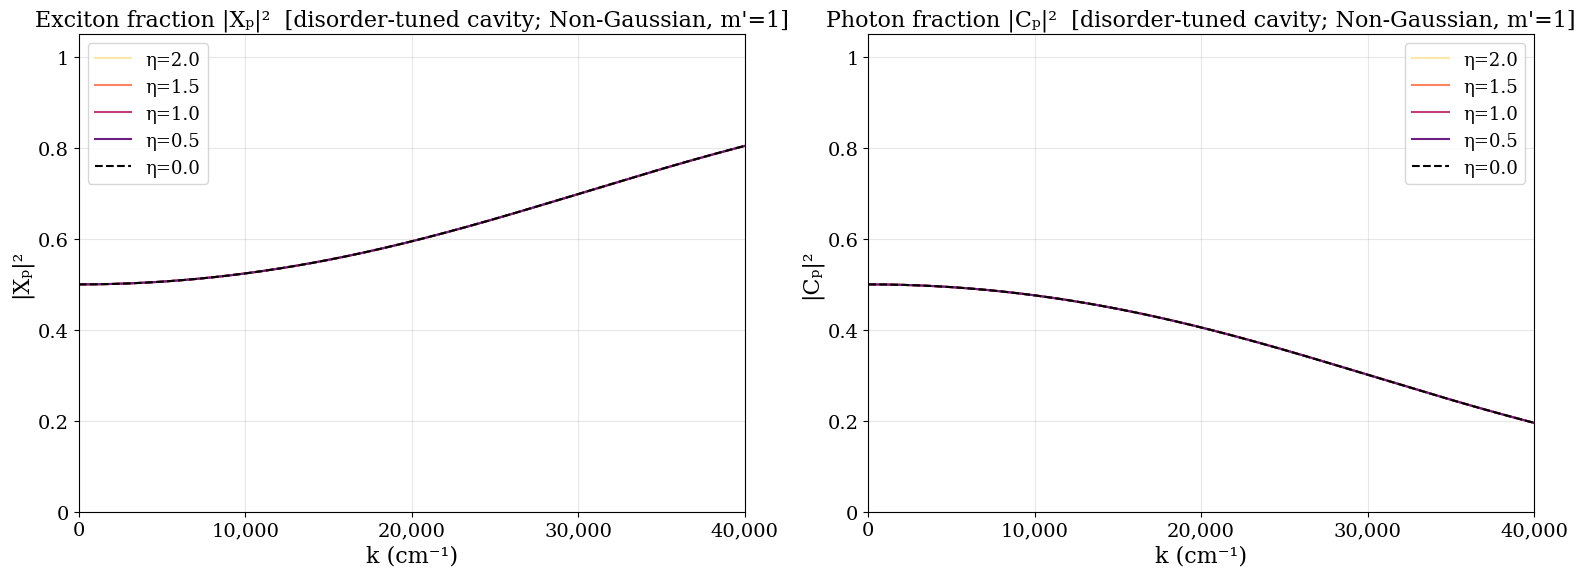

Saved  Plots/nongaussian_mprime1/hopfield_coefficients_nongaussian_mprime1_disorder_free.pdf


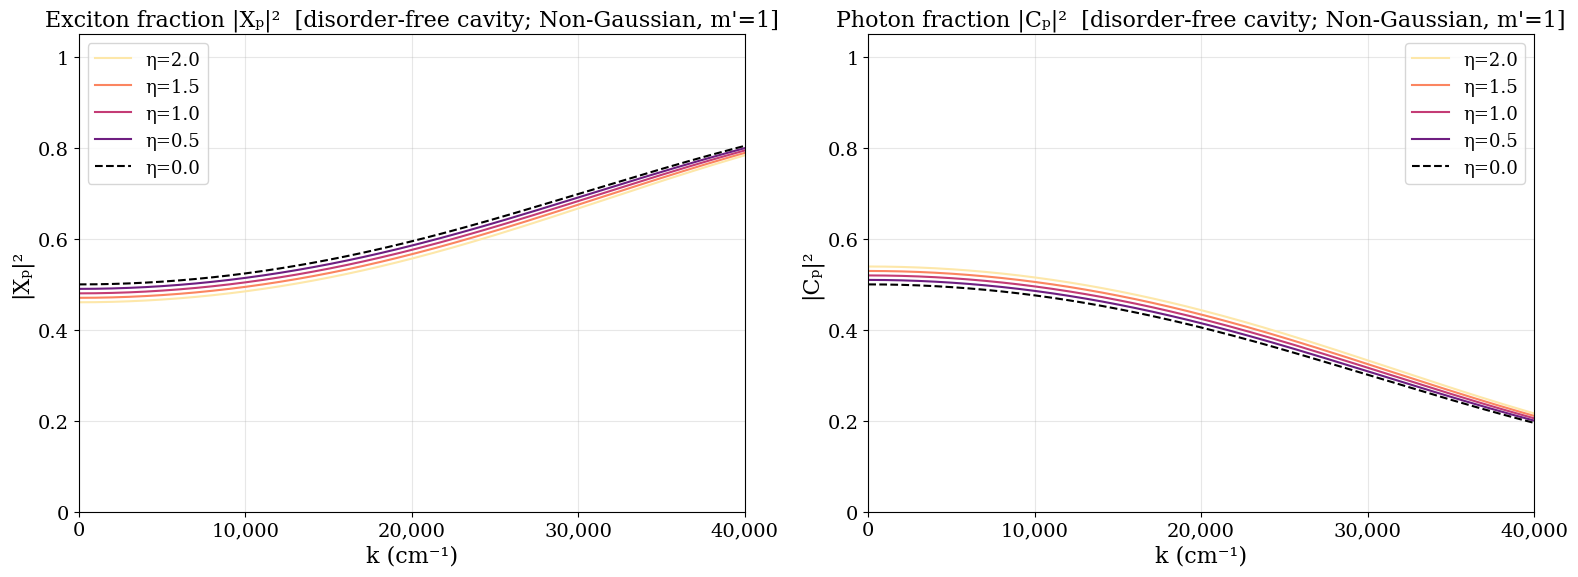

Saved  Plots/xi10nm_mprime1/hopfield_coefficients_xi10nm_mprime1_disorder_tuned.pdf


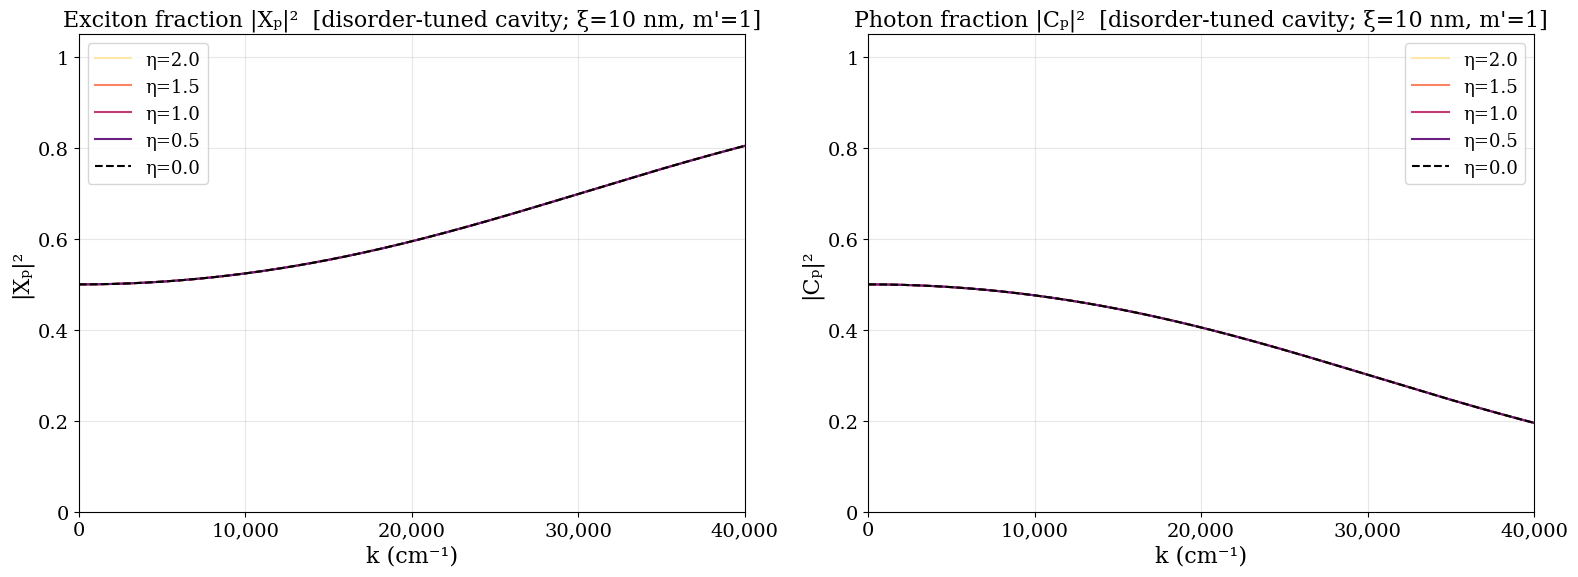

Saved  Plots/xi10nm_mprime1/hopfield_coefficients_xi10nm_mprime1_disorder_free.pdf


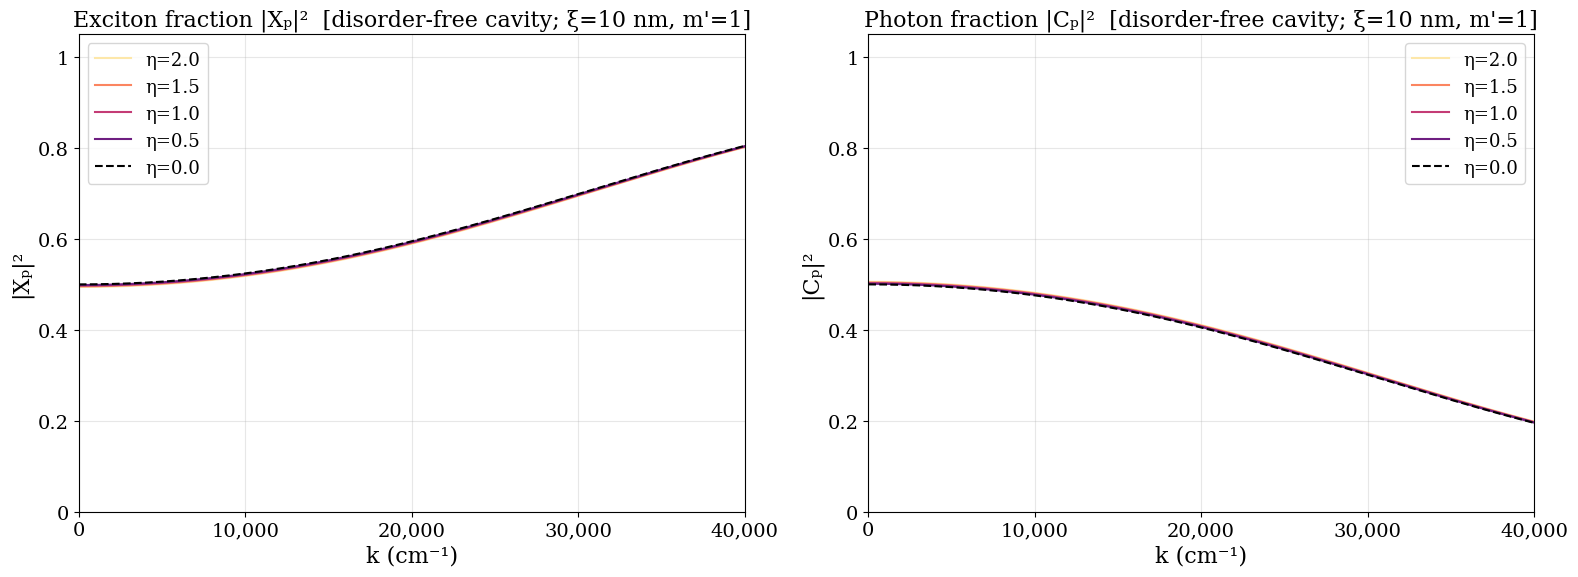

Saved  Plots/xi20nm_mprime1/hopfield_coefficients_xi20nm_mprime1_disorder_tuned.pdf


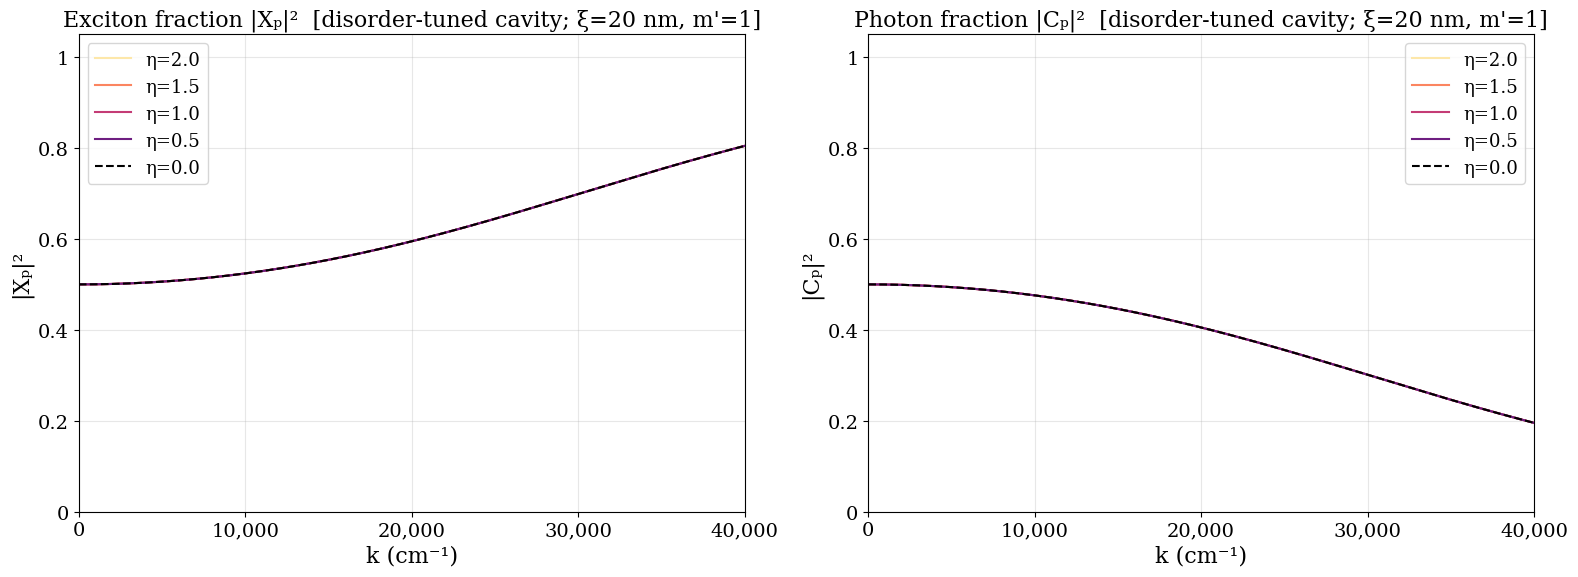

Saved  Plots/xi20nm_mprime1/hopfield_coefficients_xi20nm_mprime1_disorder_free.pdf


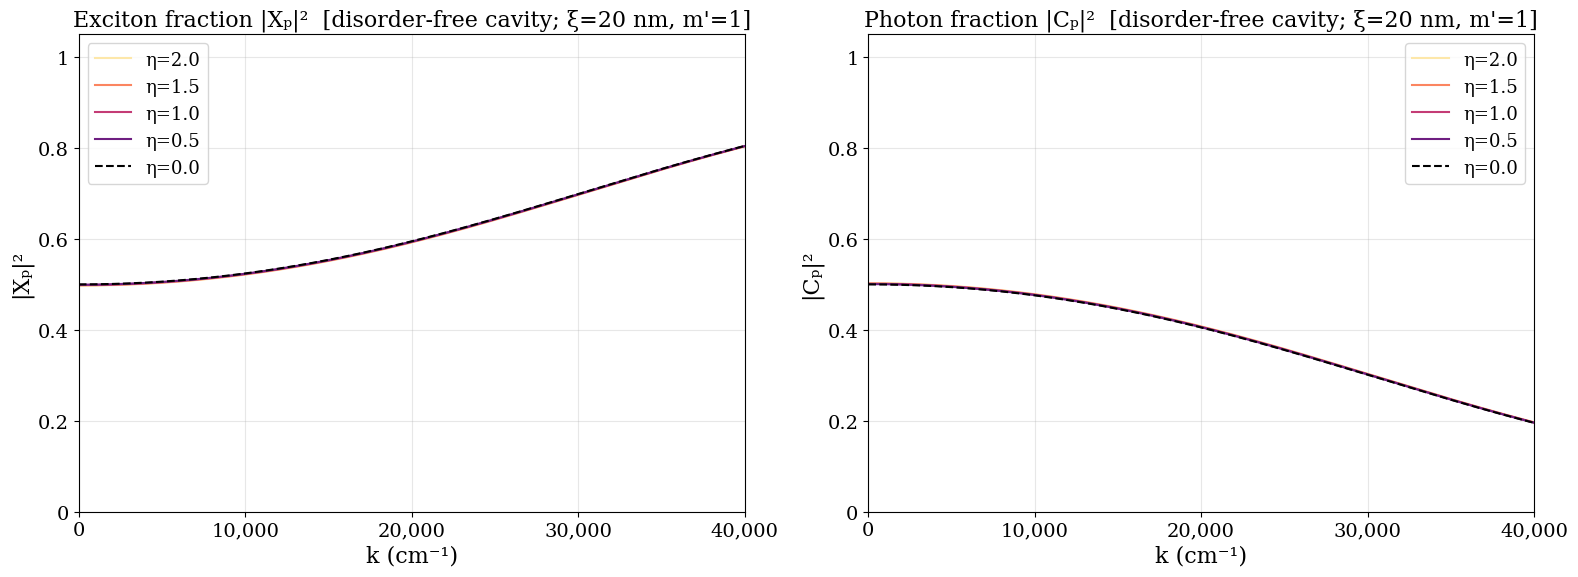

Saved  Plots/xi40nm_mprime1/hopfield_coefficients_xi40nm_mprime1_disorder_tuned.pdf


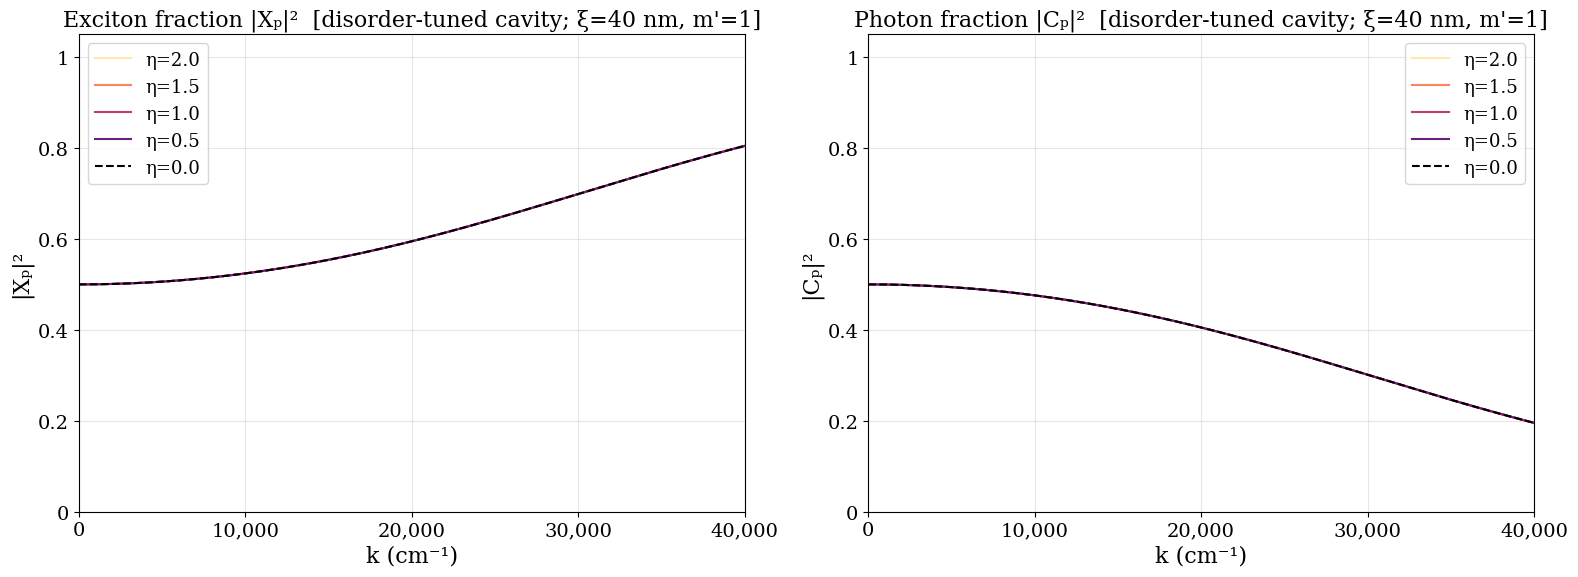

Saved  Plots/xi40nm_mprime1/hopfield_coefficients_xi40nm_mprime1_disorder_free.pdf


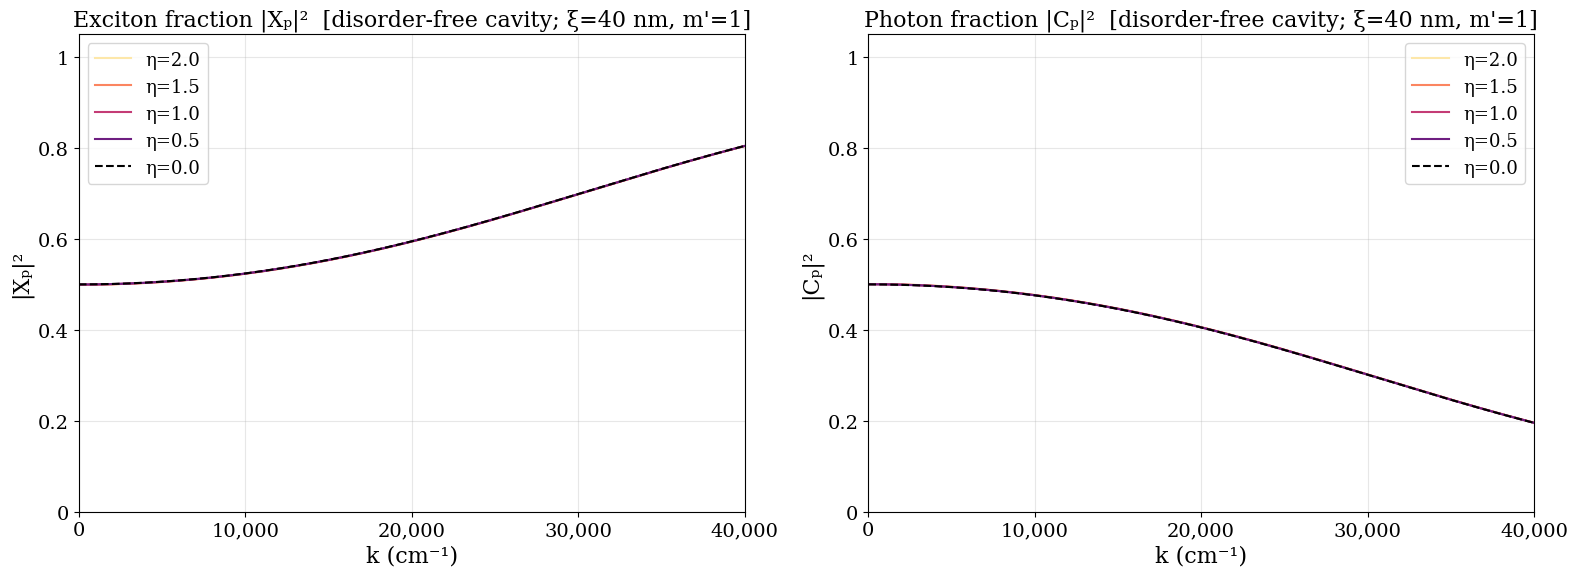

In [8]:
for plot_context in plot_contexts:
	apply_context(plot_context)
	for tuned in (True, False):
		fig, axs = plt.subplots(1, 2, figsize=(16, 6))
		for eta in eta_values_descending(legend_etas):
			ei = int(np.argmin(np.abs(eta_grid - eta)))
			eta_value = float(eta_grid[ei])
			clr, linestyle = eta_line_style(ei, len(eta_grid), eta_value, linestyle="-")
			E_lp = model.E_LP(k_disp, eta_value, disorder_tuned=tuned)
			X_LP, C_LP = hopfield_coefficients(model, eta_value, k_disp, E_lp)
			axs[0].plot(k_disp_cm, np.abs(X_LP)**2, color=clr, linestyle=linestyle, label=f"η={eta_value:.1f}")
			axs[1].plot(k_disp_cm, np.abs(C_LP)**2, color=clr, linestyle=linestyle, label=f"η={eta_value:.1f}")

		for ax, title, y_label in zip(
			axs,
			["Exciton fraction |Xₚ|²", "Photon fraction |Cₚ|²"],
			["|Xₚ|²", "|Cₚ|²"],
		):
			ax.set_xlabel(f"k ({CM_INV_LABEL})")
			ax.set_ylabel(y_label)
			ax.set_title(f"{title}  [{cavity_label(tuned)}; {result_label_text}]")
			ax.set_xlim(0.0, 40_000.0)
			ax.set_ylim(0, 1.05)
			ax.legend()
			ax.grid(alpha=0.3)
			format_plot_ticks(ax, axes="x", ticks=[0, 10_000, 20_000, 30_000, 40_000])
			format_plot_ticks(ax, axes="y")

		plt.tight_layout()
		save_figure(fig, f"hopfield_coefficients_{result_slug_text}_{cavity_slug(tuned)}", meta={
			**context_metadata(plot_context),
			"disorder_tuned": tuned,
		})
		plt.show()
		plt.close(fig)


## Detuning Δ(k, η) = E_ph − E_ex


Saved  Plots/nongaussian_mprime1/detuning_nongaussian_mprime1_disorder_tuned.pdf


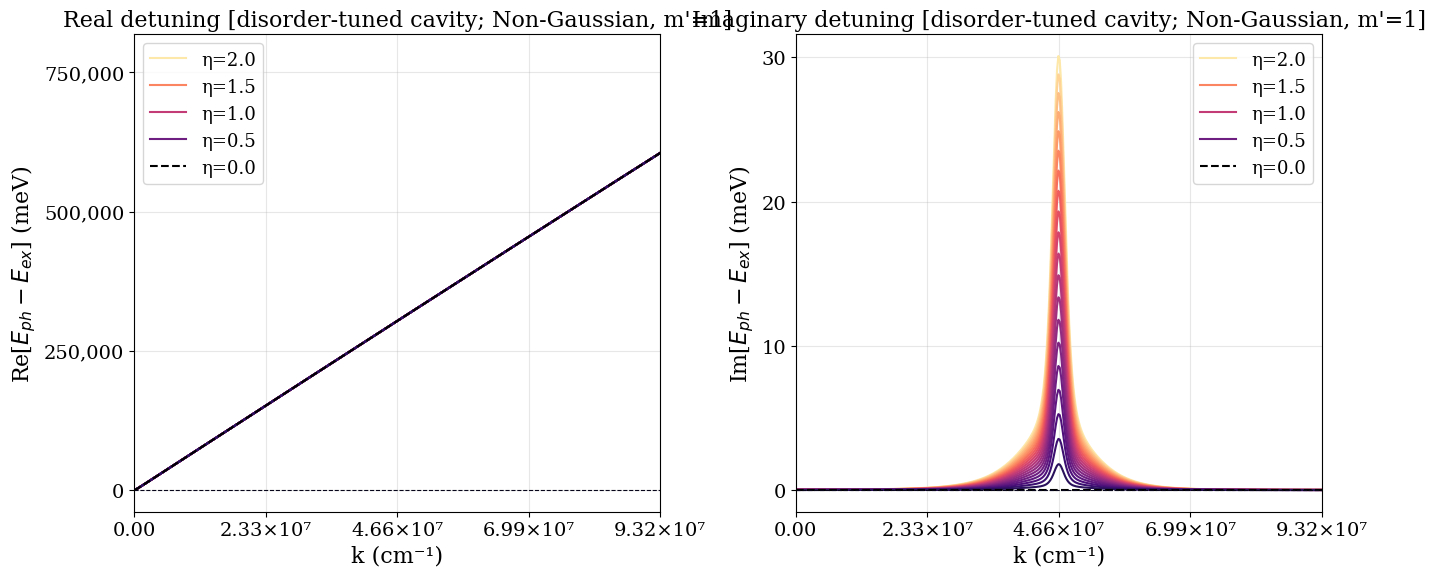

Saved  Plots/nongaussian_mprime1/detuning_nongaussian_mprime1_disorder_free.pdf


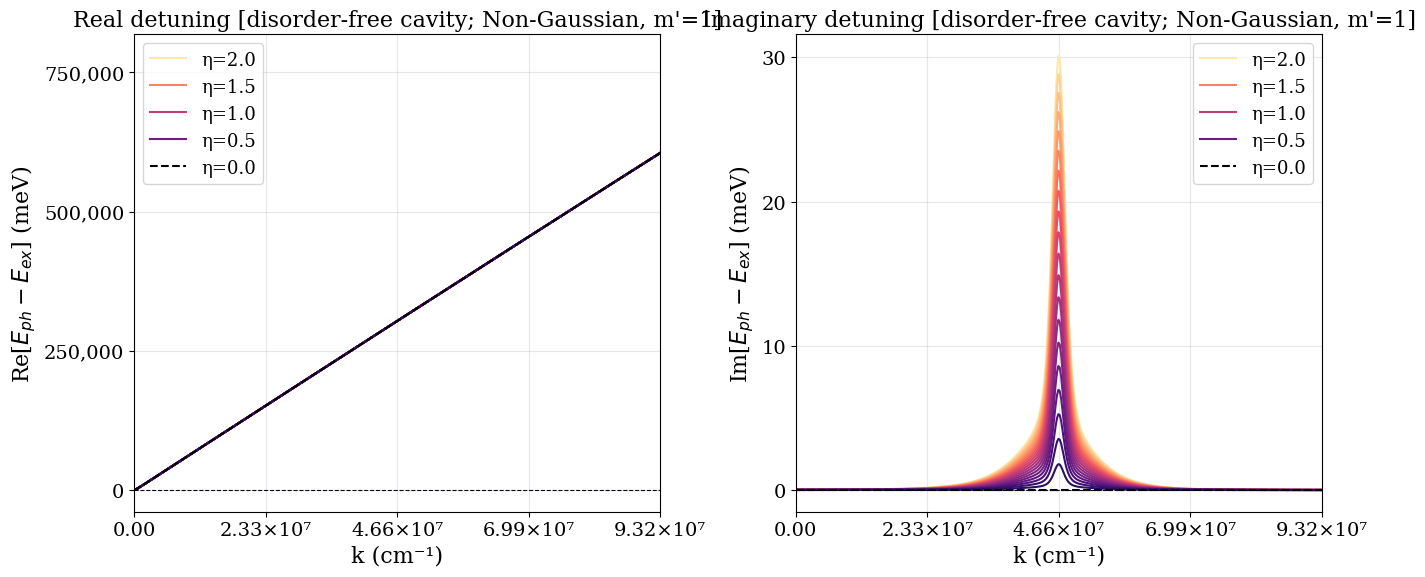

Saved  Plots/xi10nm_mprime1/detuning_xi10nm_mprime1_disorder_tuned.pdf


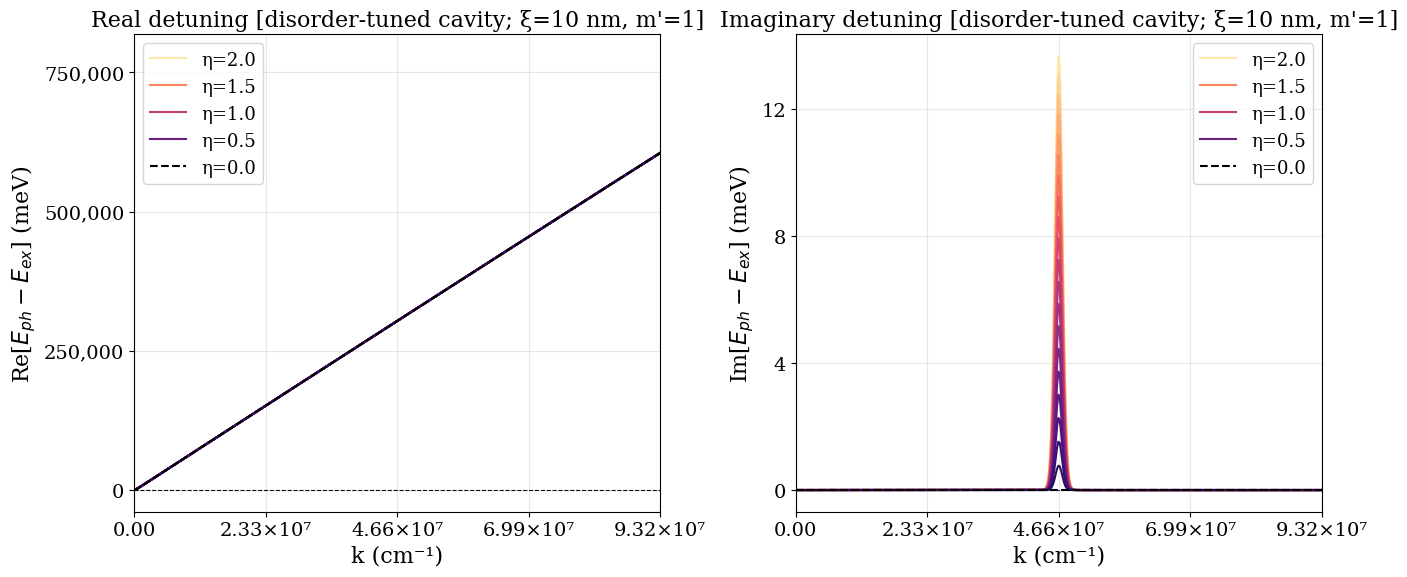

Saved  Plots/xi10nm_mprime1/detuning_xi10nm_mprime1_disorder_free.pdf


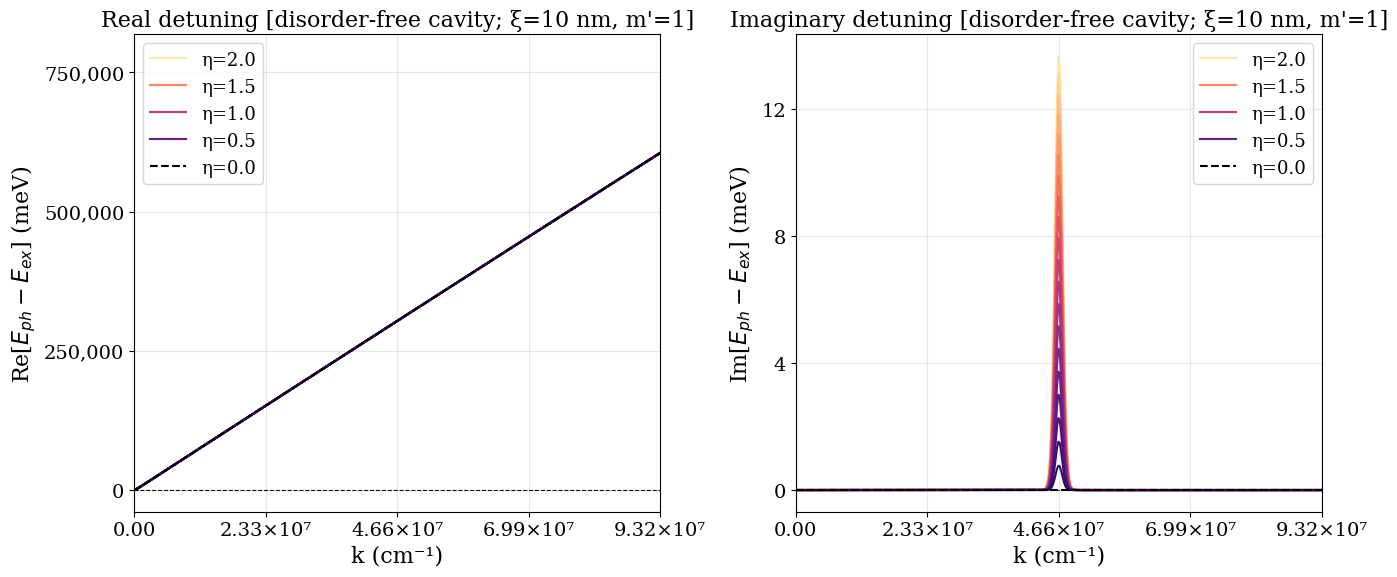

Saved  Plots/xi20nm_mprime1/detuning_xi20nm_mprime1_disorder_tuned.pdf


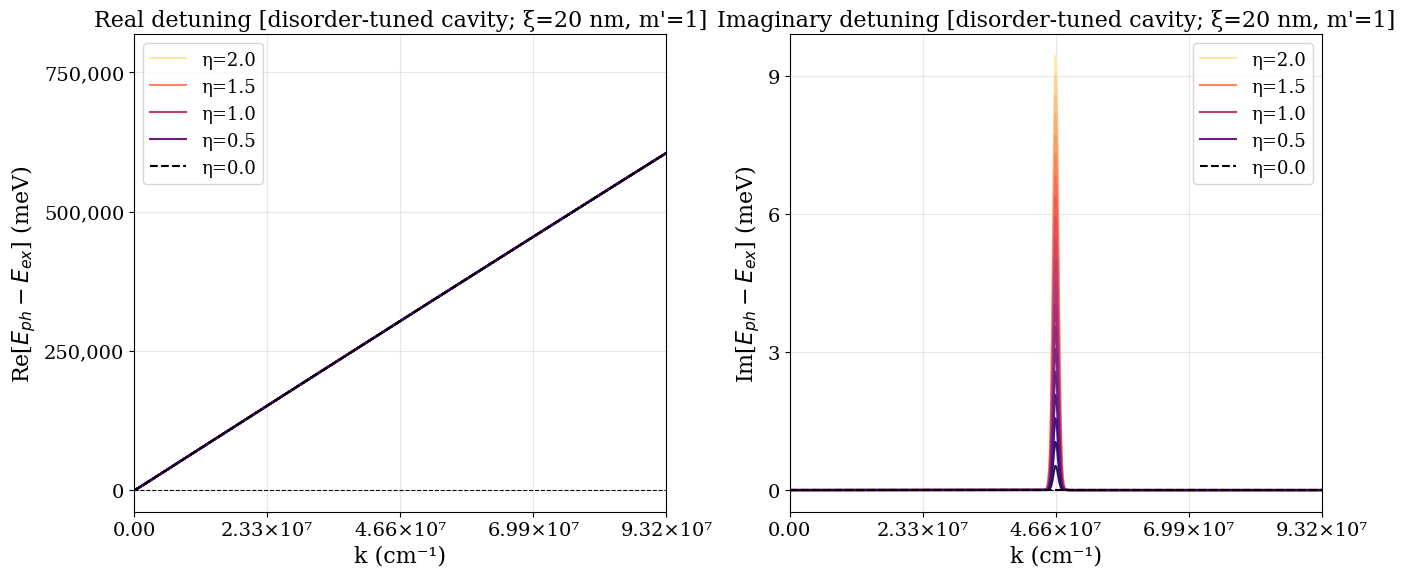

Saved  Plots/xi20nm_mprime1/detuning_xi20nm_mprime1_disorder_free.pdf


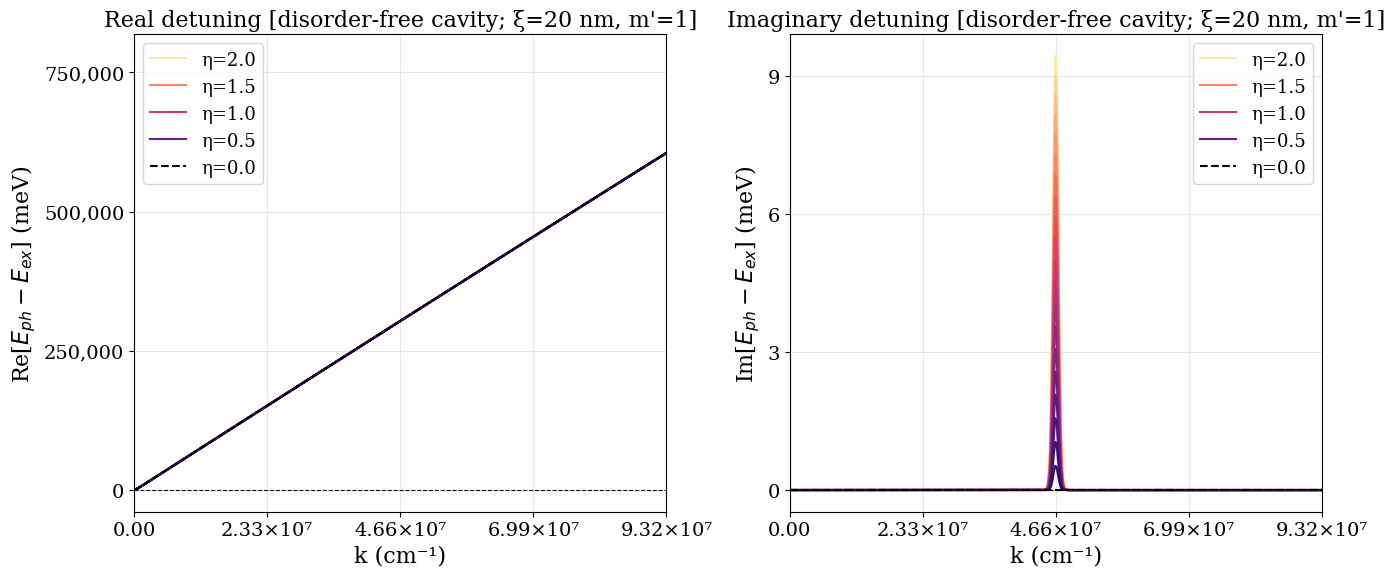

Saved  Plots/xi40nm_mprime1/detuning_xi40nm_mprime1_disorder_tuned.pdf


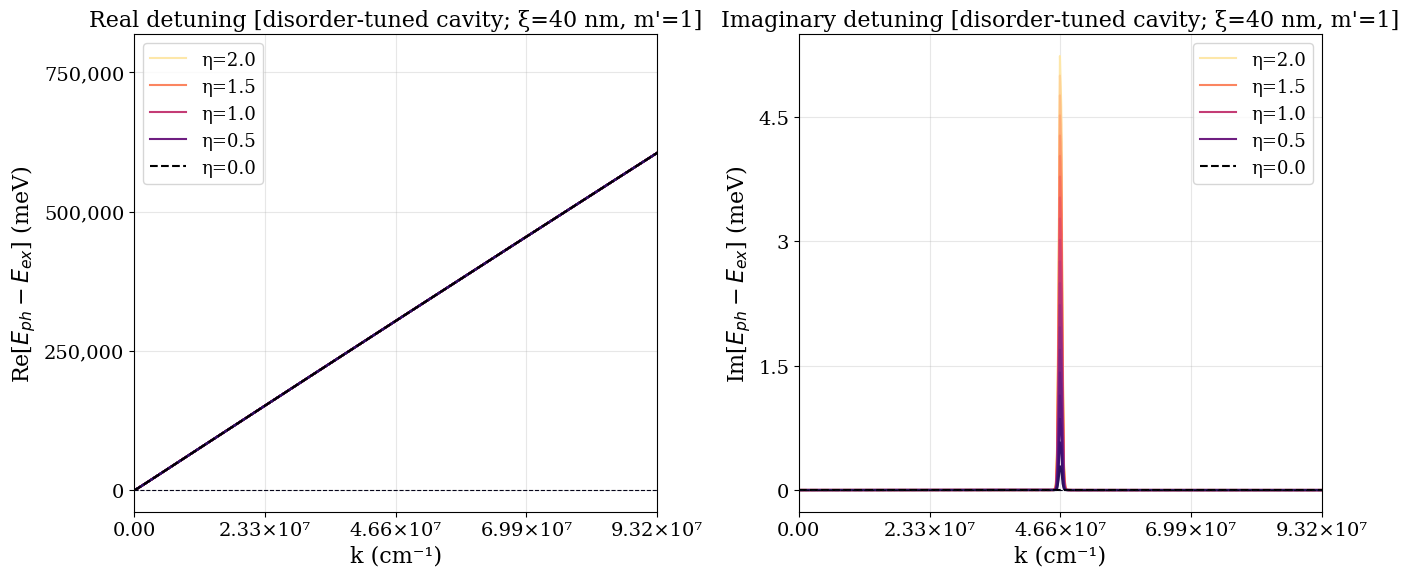

Saved  Plots/xi40nm_mprime1/detuning_xi40nm_mprime1_disorder_free.pdf


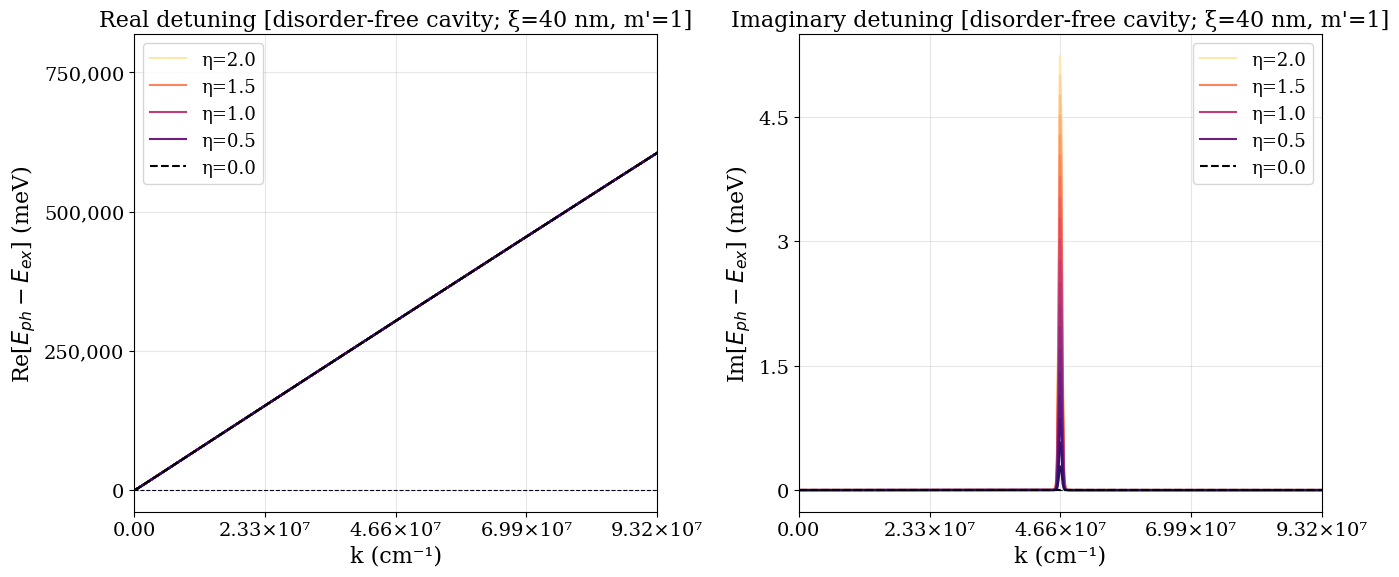

In [9]:
for plot_context in plot_contexts:
	apply_context(plot_context)
	for tuned in (True, False):
		fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
		for ei in eta_indices_descending():
			eta = float(eta_grid[ei])
			clr, linestyle = eta_line_style(ei, len(eta_grid), eta, linestyle="-")
			lbl = f"η={eta:.1f}" if eta in legend_etas else "_nolegend_"
			E_ph = model.E_ph(k_wide, eta) if tuned else model.E_ph_untuned(k_wide)
			delta = E_ph - model.E_ex(k_wide, eta)
			ax1.plot(k_wide_cm, energy_nat_to_meV(np.real(delta), p_nat), color=clr, linestyle=linestyle, label=lbl)
			ax2.plot(k_wide_cm, energy_nat_to_meV(np.imag(delta), p_nat), color=clr, linestyle=linestyle, label=lbl)

		for ax in (ax1, ax2):
			ax.axhline(0, color=CMAP(0.05), lw=0.8, ls='--')
			ax.set_xlabel(f"k ({CM_INV_LABEL})")
			ax.legend()
			ax.grid(alpha=0.3)
			apply_centered_critical_axis(ax, critical_k_cm_inv, decimals=2, fallback_xmax=float(k_wide_cm.max()), fallback_tick_count=4)
			format_plot_ticks(ax, axes="y", nbins=4)

		ax1.set_ylabel(r"Re[$E_{ph}−E_{ex}$] (meV)")
		ax1.set_title(f"Real detuning [{cavity_label(tuned)}; {result_label_text}]")
		ax2.set_ylabel(r"Im[$E_{ph}−E_{ex}$] (meV)")
		ax2.set_title(f"Imaginary detuning [{cavity_label(tuned)}; {result_label_text}]")

		plt.tight_layout()
		save_figure(fig, f"detuning_{result_slug_text}_{cavity_slug(tuned)}", meta={
			**context_metadata(plot_context),
			"disorder_tuned": tuned,
		})
		plt.show()
		plt.close(fig)


## Polariton interaction strength vs k


Saved  g_f2e631.npy  [2, 21, 240] float64
Saved  g_20ee86.npy  [2, 21, 500] float64


/tmp/ipykernel_171281/3370684278.py:218: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved  Plots/nongaussian_mprime1/g_interactions_nongaussian_mprime1_disorder_tuned.pdf


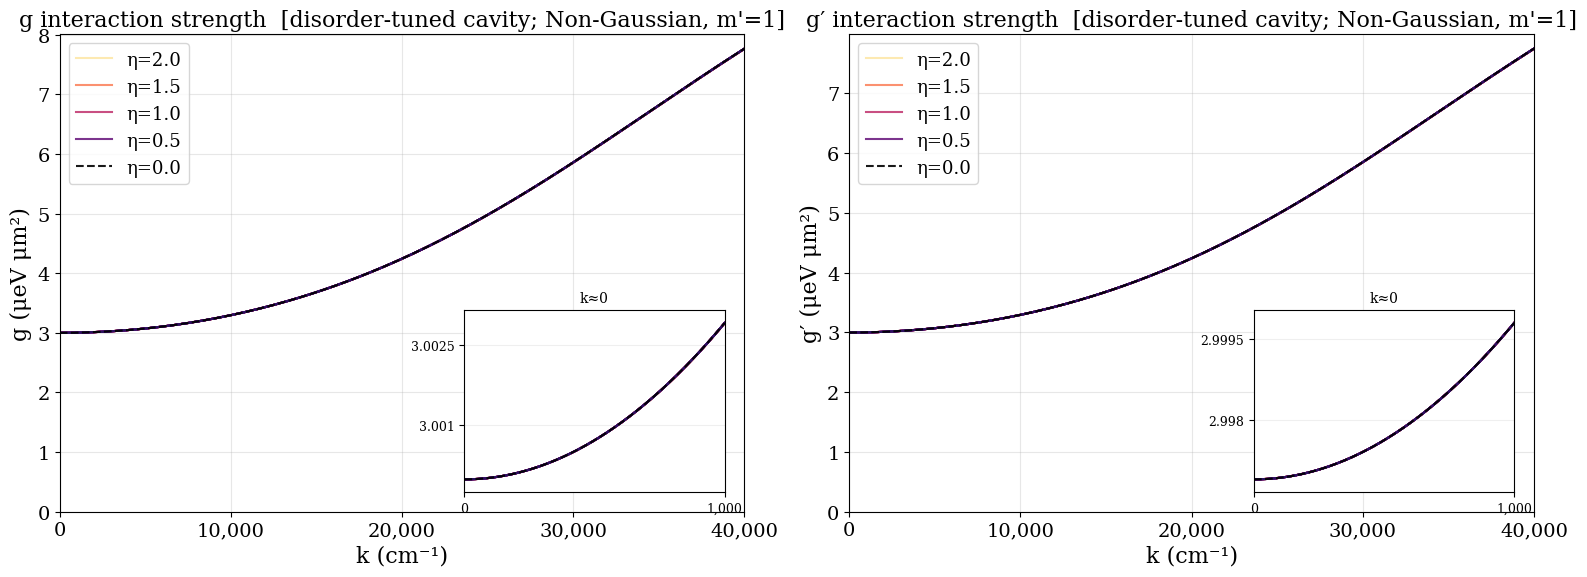

Saved  g_cbf766.npy  [2, 21, 240] float64
Saved  g_3e748c.npy  [2, 21, 500] float64


/tmp/ipykernel_171281/3370684278.py:218: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved  Plots/nongaussian_mprime1/g_interactions_nongaussian_mprime1_disorder_free.pdf


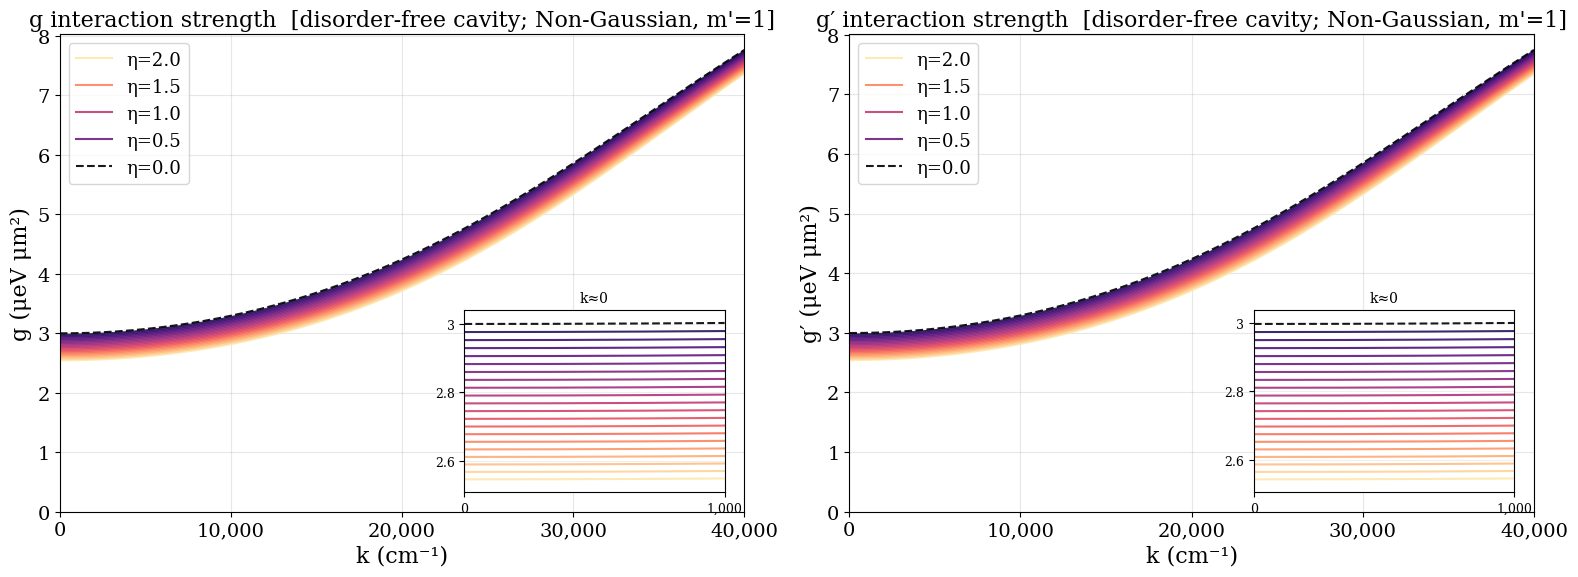

Saved  g_519c39.npy  [2, 21, 240] float64
Saved  g_0b13af.npy  [2, 21, 500] float64


/tmp/ipykernel_171281/3370684278.py:218: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved  Plots/xi10nm_mprime1/g_interactions_xi10nm_mprime1_disorder_tuned.pdf


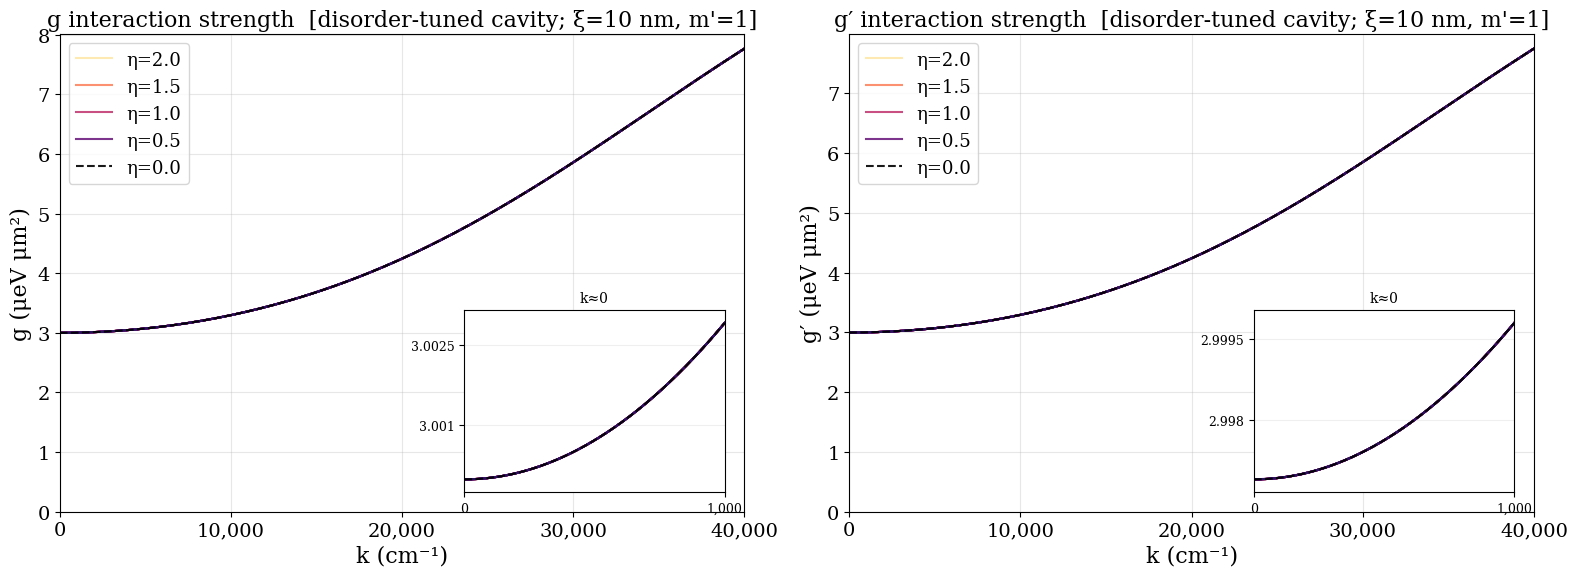

Saved  g_eb4e7b.npy  [2, 21, 240] float64
Saved  g_10a17b.npy  [2, 21, 500] float64


/tmp/ipykernel_171281/3370684278.py:218: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved  Plots/xi10nm_mprime1/g_interactions_xi10nm_mprime1_disorder_free.pdf


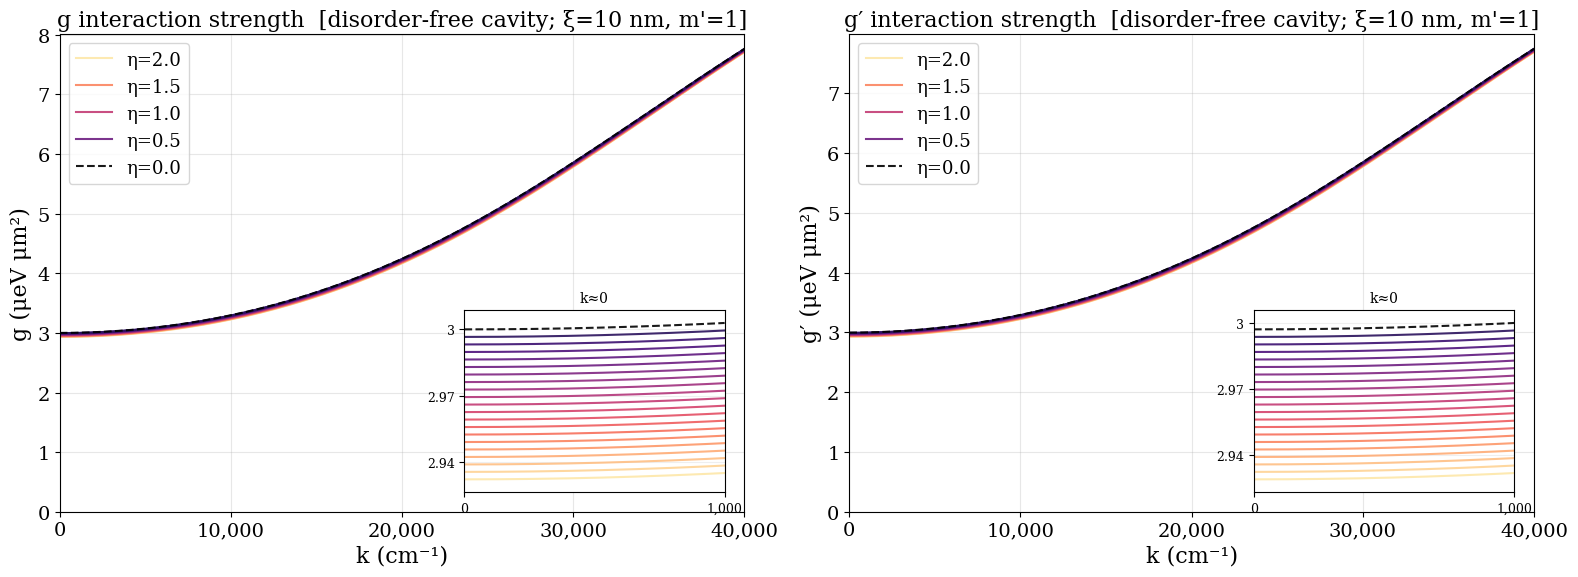

Saved  g_56b34d.npy  [2, 21, 240] float64
Saved  g_7f3be9.npy  [2, 21, 500] float64


/tmp/ipykernel_171281/3370684278.py:218: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved  Plots/xi20nm_mprime1/g_interactions_xi20nm_mprime1_disorder_tuned.pdf


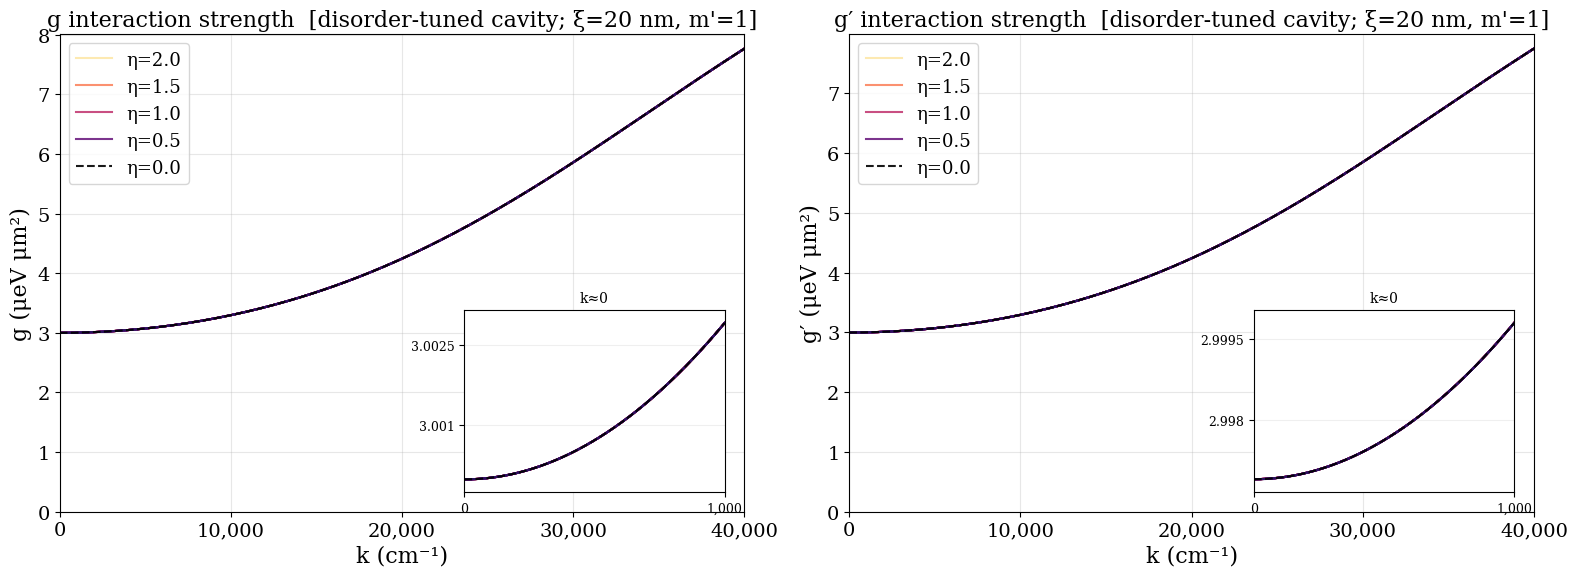

Saved  g_5cb76c.npy  [2, 21, 240] float64
Saved  g_6d9872.npy  [2, 21, 500] float64


/tmp/ipykernel_171281/3370684278.py:218: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved  Plots/xi20nm_mprime1/g_interactions_xi20nm_mprime1_disorder_free.pdf


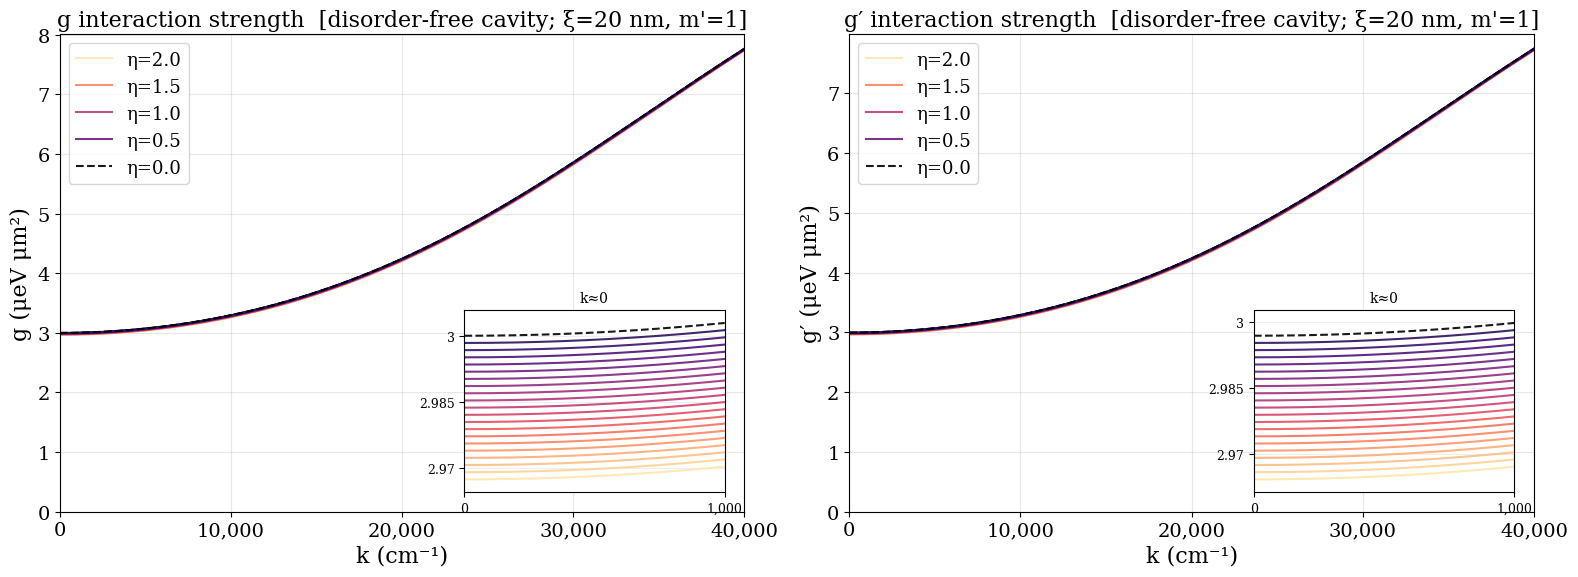

Saved  g_f3da48.npy  [2, 21, 240] float64
Saved  g_74b6d6.npy  [2, 21, 500] float64


/tmp/ipykernel_171281/3370684278.py:218: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved  Plots/xi40nm_mprime1/g_interactions_xi40nm_mprime1_disorder_tuned.pdf


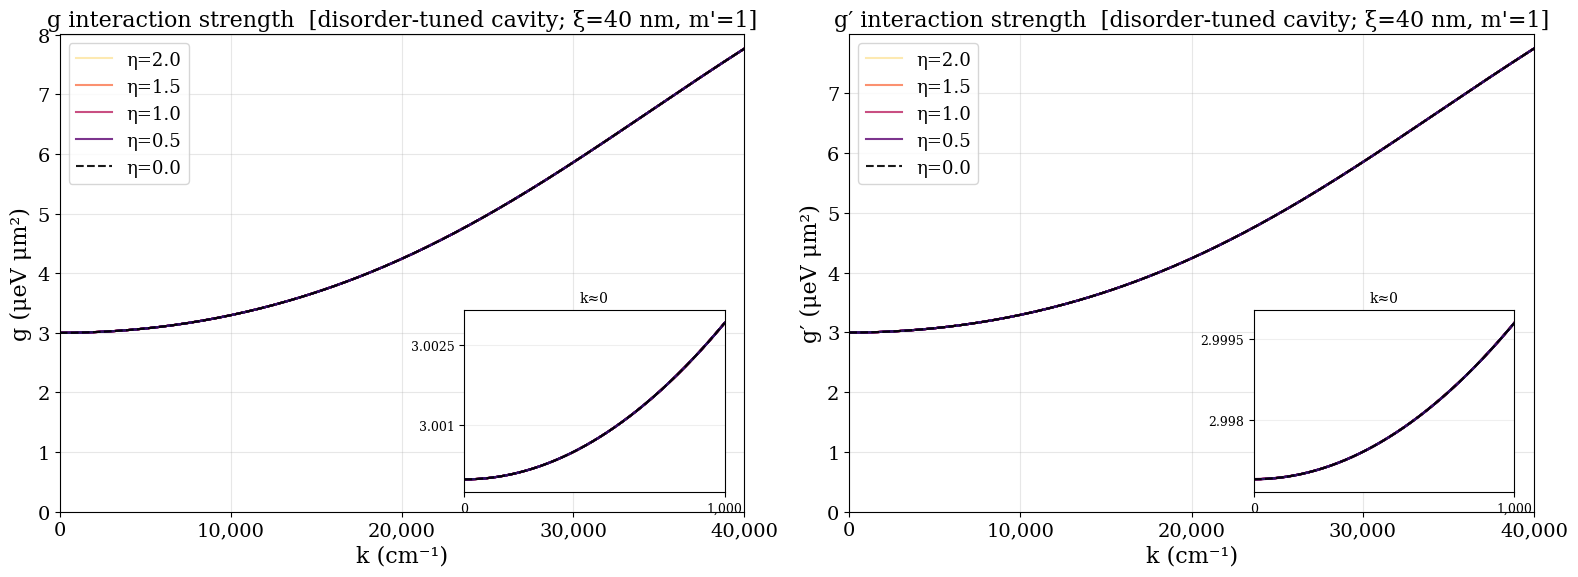

Saved  g_ac2632.npy  [2, 21, 240] float64
Saved  g_2d06e8.npy  [2, 21, 500] float64


/tmp/ipykernel_171281/3370684278.py:218: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved  Plots/xi40nm_mprime1/g_interactions_xi40nm_mprime1_disorder_free.pdf


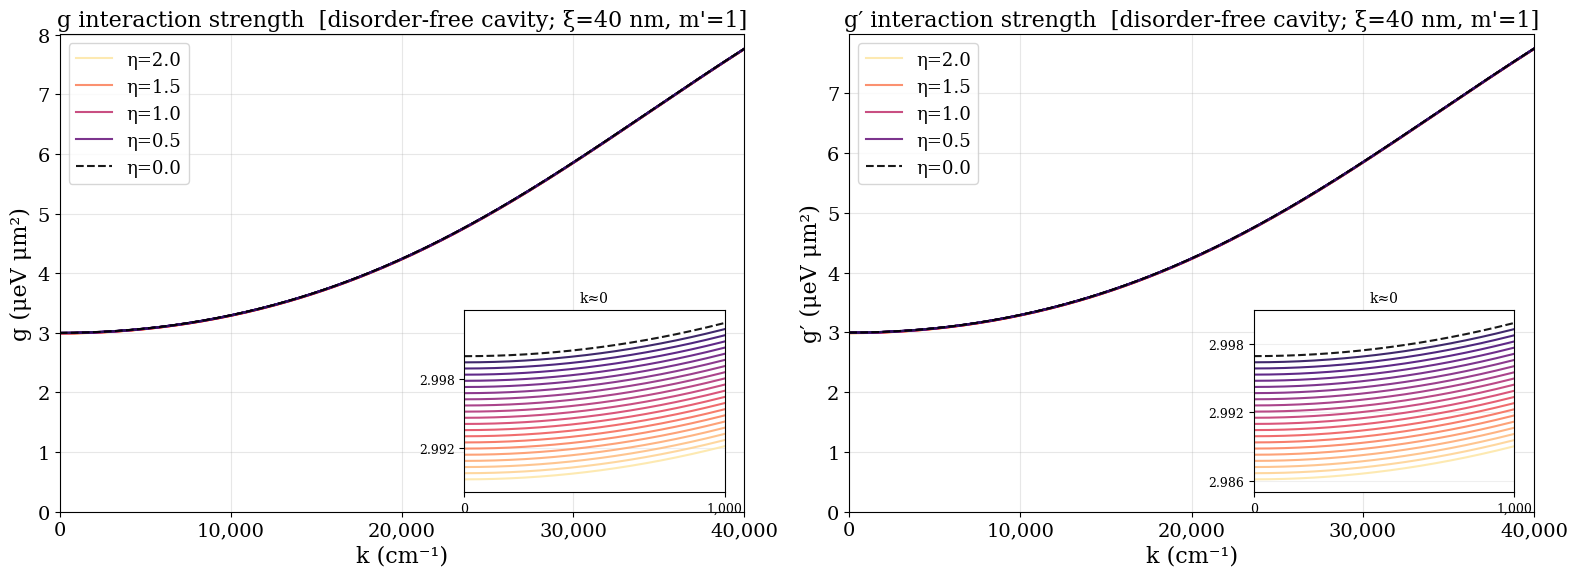

In [10]:
# Parameters for the many-body calculation
SIDE_BY_SIDE = True
L_TERMS = 100
K_UPPER = 1.0    # natural momentum for chemical-potential integration
N_K = 100_000
K_UPPER_MASS = 1e-3
N_K_MASS = 64
INTERACTION_RESULTS_DIR = Path("Results/interaction_strengths")
INTERACTION_FULL_MAX_CM = 40_000.0
INTERACTION_INSET_MAX_CM = 1000.0
INTERACTION_INSET_POINTS = 500
INTERACTION_FULL_TICKS_CM = [0, 10_000, 20_000, 30_000, 40_000]
INTERACTION_QUANTITY_AXIS = ["bare", "screened"]


def interaction_grid_cm_values(grid_role: str) -> np.ndarray:
	if grid_role == "full_plot":
		return np.linspace(0.0, INTERACTION_FULL_MAX_CM, 240)
	if grid_role == "dense_inset":
		return np.linspace(0.0, INTERACTION_INSET_MAX_CM, INTERACTION_INSET_POINTS)
	raise ValueError(f"Unknown interaction grid role: {grid_role!r}")


def interaction_grid_stem(ctx, *, disorder_tuned: bool, grid_role: str, k_grid: np.ndarray) -> str:
	extra = {
		"quantity": "polariton_interaction_strength",
		"sweep_schema": SWEEP_SCHEMA,
		"result_slug": ctx["result_slug_text"],
		"q_stem": ctx["q_stem"],
		"kernel_stem": ctx.get("kernel_stem"),
		"disorder_tuned": bool(disorder_tuned),
		"grid_role": grid_role,
		"k_grid_len": int(len(k_grid)),
		"k_grid_min": float(np.min(k_grid)),
		"k_grid_max": float(np.max(k_grid)),
		"eta_grid": [float(value) for value in ctx["eta_grid"]],
		"quantity_axis": INTERACTION_QUANTITY_AXIS,
		"L_terms": L_TERMS,
		"k_upper_natural": K_UPPER,
		"n_k": N_K,
		"k_upper_mass_natural": K_UPPER_MASS,
		"n_k_mass": N_K_MASS,
	}
	return make_sweep_stem("g", ctx["p_nat"], extra=extra)


def interaction_result_metadata(ctx, *, disorder_tuned: bool, grid_role: str, k_grid: np.ndarray, k_grid_cm: np.ndarray) -> dict:
	return {
		**context_metadata(ctx),
		"quantity": "polariton_interaction_strength",
		"eta_grid": [float(value) for value in ctx["eta_grid"]],
		"k_grid": [float(value) for value in k_grid],
		"k_grid_cm_inv": [float(value) for value in k_grid_cm],
		"quantity_axis": INTERACTION_QUANTITY_AXIS,
		"disorder_tuned": bool(disorder_tuned),
		"cavity": cavity_slug(disorder_tuned),
		"grid_role": grid_role,
		"kernel_stem": ctx.get("kernel_stem"),
		"q_stem": ctx["q_stem"],
		"L_terms": L_TERMS,
		"k_upper_natural": K_UPPER,
		"n_k": N_K,
		"k_upper_mass_natural": K_UPPER_MASS,
		"n_k_mass": N_K_MASS,
		"interaction_units": "natural",
	}


def bubble_for_interaction(eta: float, disorder_tuned: bool, bubble_cache: dict) -> float:
	key = (float(eta), bool(disorder_tuned))
	if key not in bubble_cache:
		bubble_cache[key] = Pi0(
			model, eta,
			L_terms=L_TERMS,
			k_upper=K_UPPER,
			n_k=N_K,
			k_upper_mass=K_UPPER_MASS,
			n_k_mass=N_K_MASS,
			disorder_tuned=disorder_tuned,
		)
	return bubble_cache[key]


def compute_interaction_grid(k_values: np.ndarray, *, disorder_tuned: bool, bubble_cache: dict) -> np.ndarray:
	values = np.empty((2, len(eta_grid), len(k_values)), dtype=float)
	for ei, eta in enumerate(eta_grid):
		bubble = bubble_for_interaction(float(eta), disorder_tuned, bubble_cache)
		g_bare, g_screened = polariton_interaction_strength(
			model, float(eta), k_values,
			L_terms=L_TERMS,
			k_upper=K_UPPER,
			n_k=N_K,
			k_upper_mass=K_UPPER_MASS,
			n_k_mass=N_K_MASS,
			disorder_tuned=disorder_tuned,
			bubble=bubble,
		)
		values[0, ei, :] = g_bare
		values[1, ei, :] = g_screened
	return values


def load_or_compute_interaction_grid(ctx, *, disorder_tuned: bool, grid_role: str, bubble_cache: dict) -> tuple[np.ndarray, str, np.ndarray, np.ndarray]:
	k_grid_cm = interaction_grid_cm_values(grid_role)
	k_grid = np.asarray(k_cm_to_nat(k_grid_cm, ctx["p_nat"]), dtype=float)
	stem = interaction_grid_stem(ctx, disorder_tuned=disorder_tuned, grid_role=grid_role, k_grid=k_grid)
	expected_shape = (2, len(ctx["eta_grid"]), len(k_grid))
	try:
		data, meta = load_result(INTERACTION_RESULTS_DIR, stem)
		if tuple(data.shape) == expected_shape and meta.get("quantity_axis") == INTERACTION_QUANTITY_AXIS:
			return data, stem, k_grid, k_grid_cm
		print(f"Recomputing {stem}: saved shape/metadata does not match current plot grid.")
	except FileNotFoundError:
		pass

	data = compute_interaction_grid(k_grid, disorder_tuned=disorder_tuned, bubble_cache=bubble_cache)
	save_result(
		data,
		INTERACTION_RESULTS_DIR,
		stem,
		ctx["p_nat"],
		extra_meta=interaction_result_metadata(
			ctx,
			disorder_tuned=disorder_tuned,
			grid_role=grid_role,
			k_grid=k_grid,
			k_grid_cm=k_grid_cm,
		),
	)
	return data, stem, k_grid, k_grid_cm


def add_low_k_inset(ax, curves, *, x_max=INTERACTION_INSET_MAX_CM):
	if not curves:
		return
	inset = inset_axes(ax, width="38%", height="38%", loc="lower right", borderpad=1.1)
	y_segments = []
	for x_values, y_values, color, linestyle in curves:
		mask = x_values <= x_max
		if np.count_nonzero(mask) < 2:
			continue
		inset.plot(x_values[mask], y_values[mask], color=color, linestyle=linestyle, alpha=0.9)
		y_segments.append(y_values[mask])

	y_all = np.concatenate([segment[np.isfinite(segment)] for segment in y_segments if segment.size]) if y_segments else np.array([])
	if y_all.size:
		y_min = float(np.nanmin(y_all))
		y_max = float(np.nanmax(y_all))
		spread = y_max - y_min
		pad = 0.08 * spread if spread > 0.0 else 0.01 * max(abs(y_max), 1.0)
		lower = y_min - pad
		upper = y_max + pad
		if y_min > 0.0 and lower <= 0.0:
			lower = max(0.5 * y_min, np.nextafter(0.0, 1.0))
		elif y_max < 0.0 and upper >= 0.0:
			upper = min(0.5 * y_max, np.nextafter(0.0, -1.0))
		inset.set_ylim(lower, upper)
	inset.set_xlim(0.0, x_max)
	inset.set_title("k≈0", fontsize=10)
	inset.grid(alpha=0.2)
	format_plot_ticks(inset, axes="x", ticks=[0, 1_000, 2_000])
	format_plot_ticks(inset, axes="y", nbins=3)
	inset.tick_params(labelsize=9)


def format_interaction_axis(ax):
	ax.set_xlabel(f"k ({CM_INV_LABEL})")
	ax.set_xlim(0.0, INTERACTION_FULL_MAX_CM)
	ax.set_ylim(0, None)
	ax.grid(alpha=0.3)
	format_plot_ticks(ax, axes="x", ticks=INTERACTION_FULL_TICKS_CM)
	format_plot_ticks(ax, axes="y")


def plot_interaction_family(plot_context) -> None:
	for tuned in (True, False):
		bubble_cache = {}
		full_data, full_stem, _, full_k_cm = load_or_compute_interaction_grid(
			plot_context,
			disorder_tuned=tuned,
			grid_role="full_plot",
			bubble_cache=bubble_cache,
		)
		inset_data, inset_stem, _, inset_k_cm = load_or_compute_interaction_grid(
			plot_context,
			disorder_tuned=tuned,
			grid_role="dense_inset",
			bubble_cache=bubble_cache,
		)

		if SIDE_BY_SIDE:
			fig, axs = plt.subplots(1, 2, figsize=(16, 6), sharex=True)
			panels = [(axs[0], 0, "g", f"g ({INTERACTION_UNIT_LABEL})"), (axs[1], 1, "g′", f"g′ ({INTERACTION_UNIT_LABEL})")]
			figure_name = f"g_interactions_{result_slug_text}_{cavity_slug(tuned)}"
		else:
			fig, ax = plt.subplots(figsize=(8, 6))
			axs = [ax]
			panels = [(ax, 1, "g′", f"g′ ({INTERACTION_UNIT_LABEL})")]
			figure_name = f"g_screened_{result_slug_text}_{cavity_slug(tuned)}"

		for ax, quantity_idx, quantity_label, y_label in panels:
			inset_curves = []
			for ei in eta_indices_descending():
				eta = float(eta_grid[ei])
				clr, linestyle = eta_line_style(ei, len(eta_grid), eta, linestyle="-")
				lbl = f"η={eta:.1f}" if eta in legend_etas else "_nolegend_"
				y_values = interaction_nat_to_microev_um2(full_data[quantity_idx, ei, :], p_nat)
				y_inset = interaction_nat_to_microev_um2(inset_data[quantity_idx, ei, :], p_nat)
				ax.plot(full_k_cm, y_values, color=clr, linestyle=linestyle, label=lbl, alpha=0.9)
				inset_curves.append((inset_k_cm, y_inset, clr, linestyle))

			ax.set_ylabel(y_label)
			ax.set_title(f"{quantity_label} interaction strength  [{cavity_label(tuned)}; {result_label_text}]")
			ax.legend()
			format_interaction_axis(ax)
			add_low_k_inset(ax, inset_curves)

		plt.tight_layout()
		save_figure(fig, figure_name, meta={
			**context_metadata(plot_context),
			"disorder_tuned": tuned,
			"side_by_side": SIDE_BY_SIDE,
			"quantity_axis": INTERACTION_QUANTITY_AXIS,
			"interaction_result_stems": {
				"full_plot": full_stem,
				"dense_inset": inset_stem,
			},
			"L_terms": L_TERMS,
			"k_upper_natural": K_UPPER,
			"n_k": N_K,
			"k_upper_mass_natural": K_UPPER_MASS,
			"n_k_mass": N_K_MASS,
			"k_min_cm_inv": float(full_k_cm[0]),
			"k_max_cm_inv": float(full_k_cm[-1]),
			"inset_max_cm_inv": INTERACTION_INSET_MAX_CM,
			"interaction_unit": INTERACTION_UNIT_LABEL,
		})
		plt.show()
		plt.close(fig)


for plot_context in plot_contexts:
	apply_context(plot_context)
	plot_interaction_family(plot_context)


## Interaction strength at k=0 vs temperature

Exact k=0 values for bare and screened interactions across temperature.


Saved  Plots/nongaussian_mprime1/g_k0_vs_temperature_nongaussian_mprime1_disorder_tuned.pdf


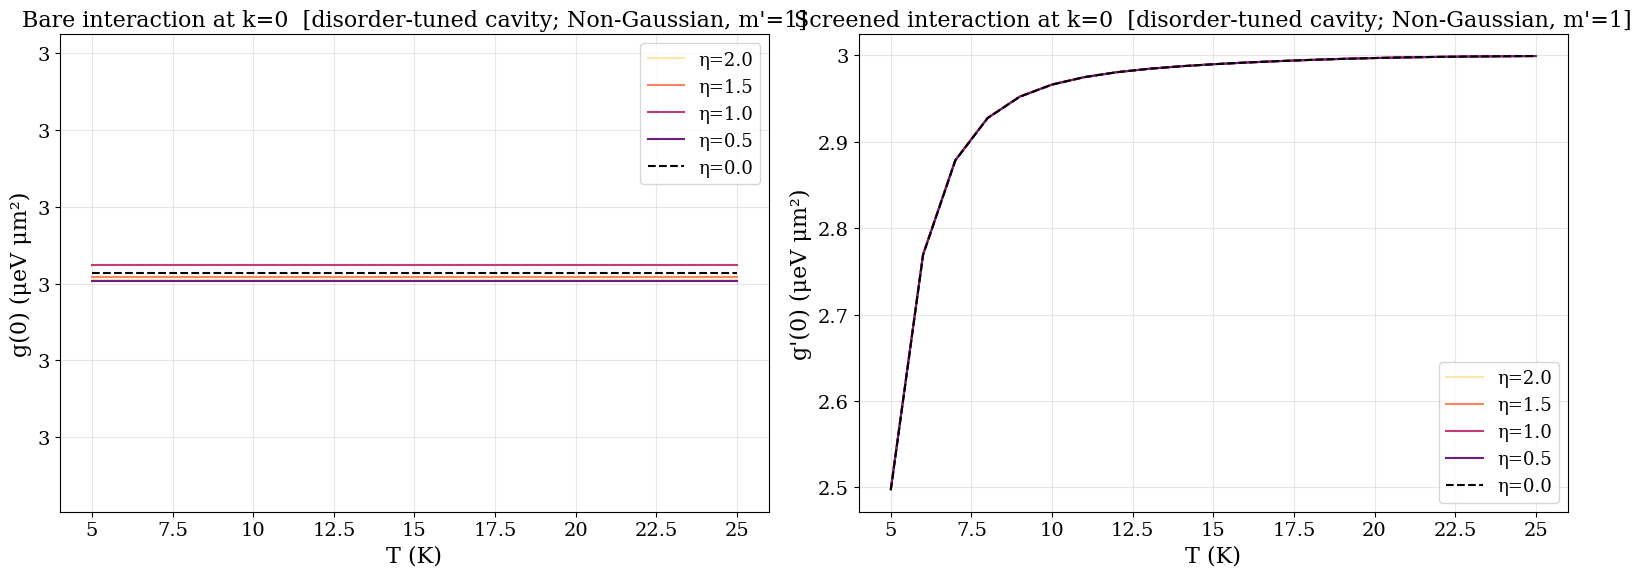

Saved  Plots/nongaussian_mprime1/g_k0_vs_temperature_nongaussian_mprime1_disorder_free.pdf


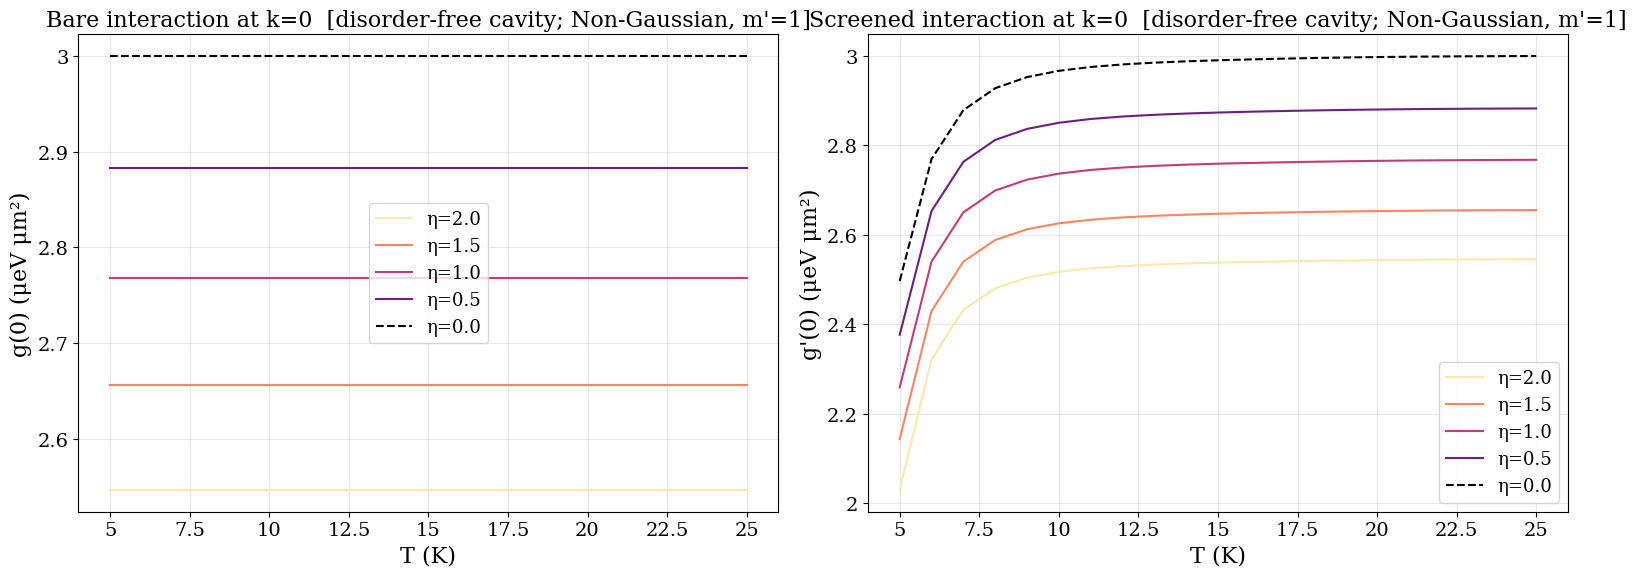

Saved  Plots/xi10nm_mprime1/g_k0_vs_temperature_xi10nm_mprime1_disorder_tuned.pdf


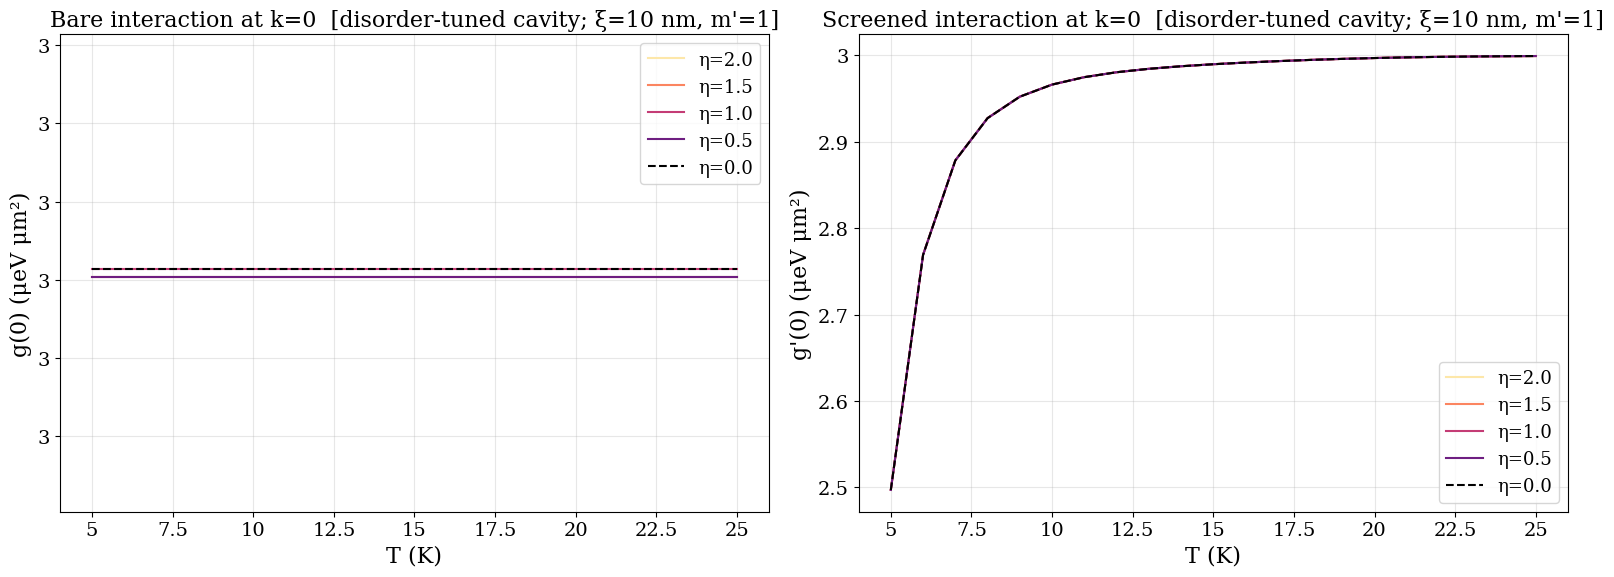

Saved  Plots/xi10nm_mprime1/g_k0_vs_temperature_xi10nm_mprime1_disorder_free.pdf


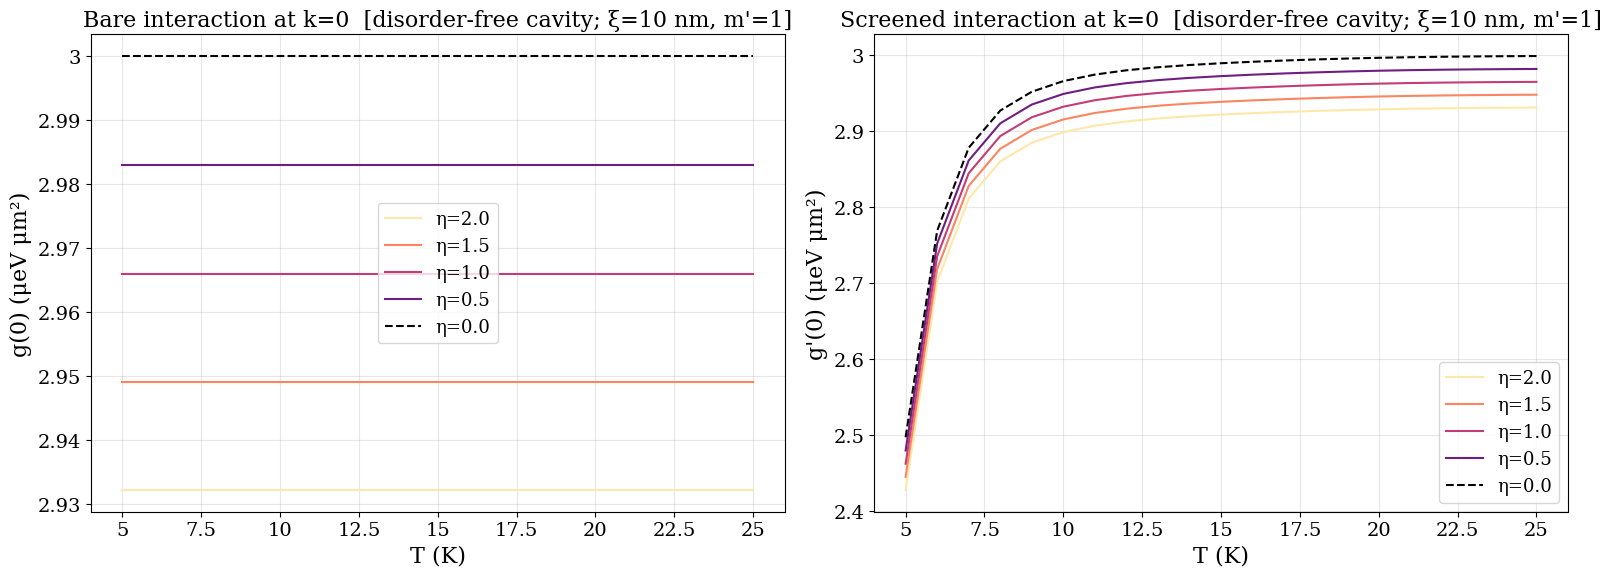

Saved  Plots/xi20nm_mprime1/g_k0_vs_temperature_xi20nm_mprime1_disorder_tuned.pdf


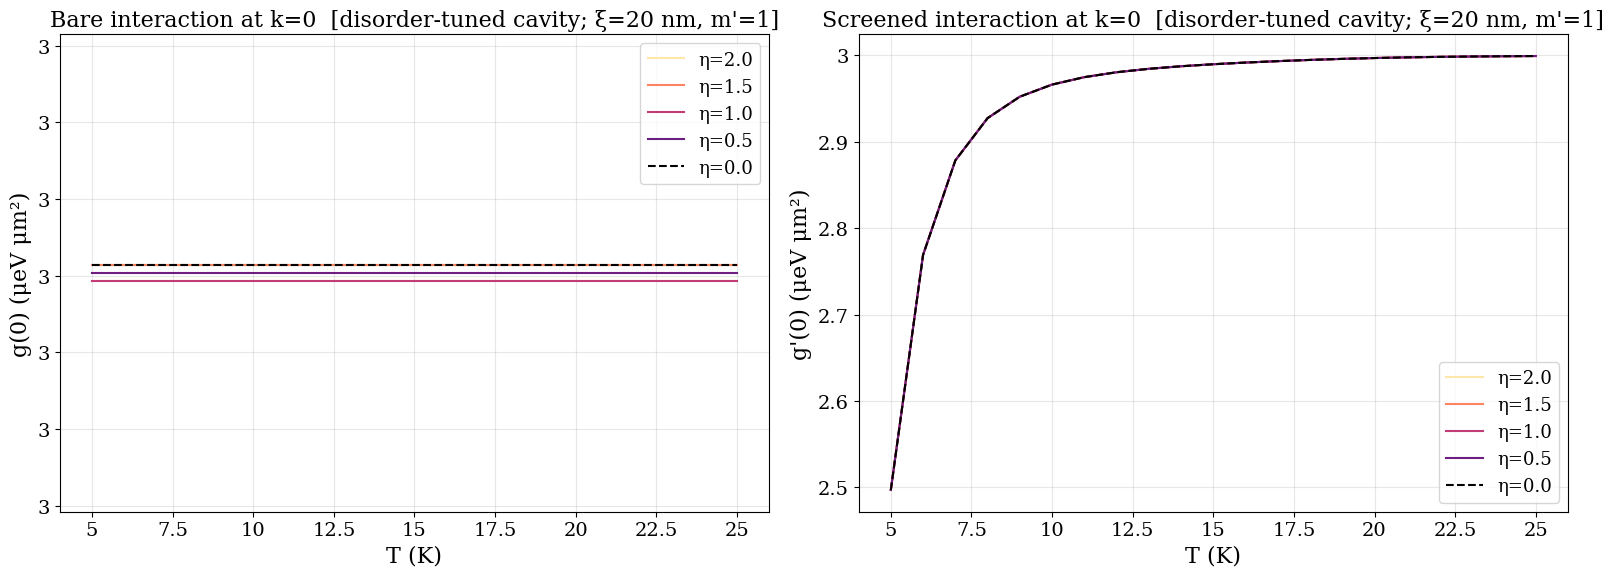

Saved  Plots/xi20nm_mprime1/g_k0_vs_temperature_xi20nm_mprime1_disorder_free.pdf


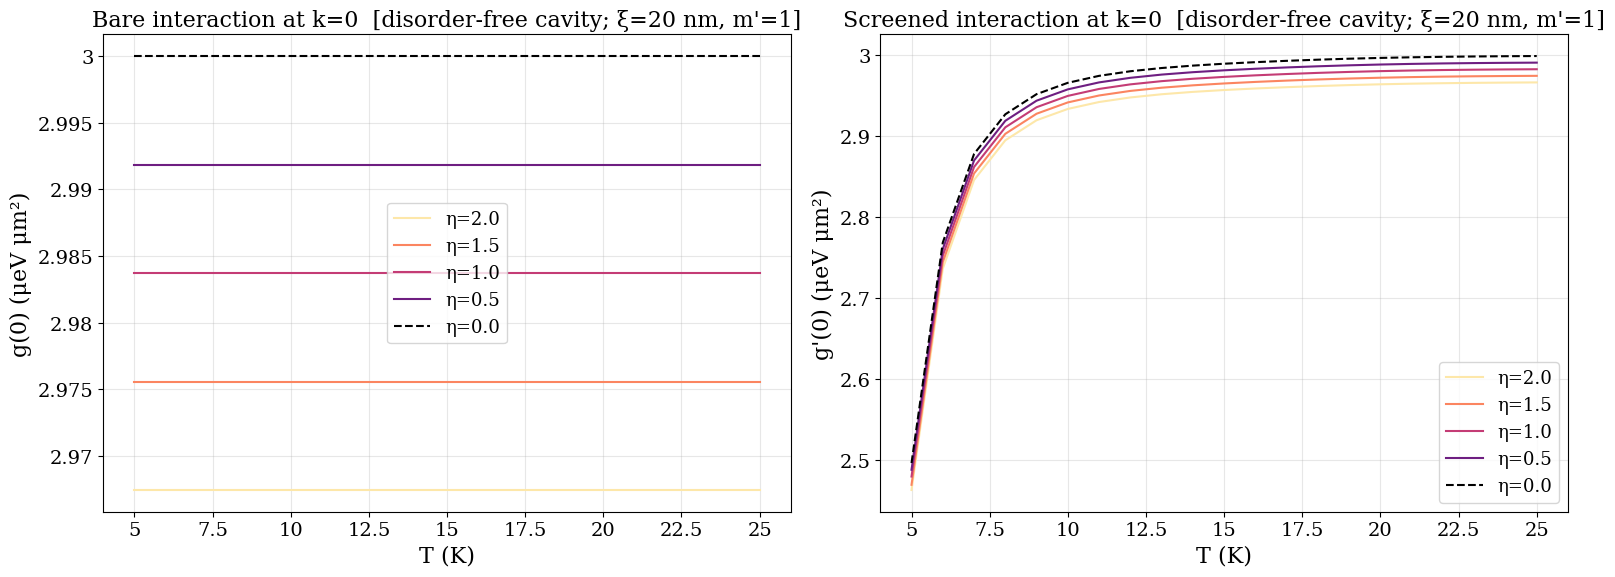

Saved  Plots/xi40nm_mprime1/g_k0_vs_temperature_xi40nm_mprime1_disorder_tuned.pdf


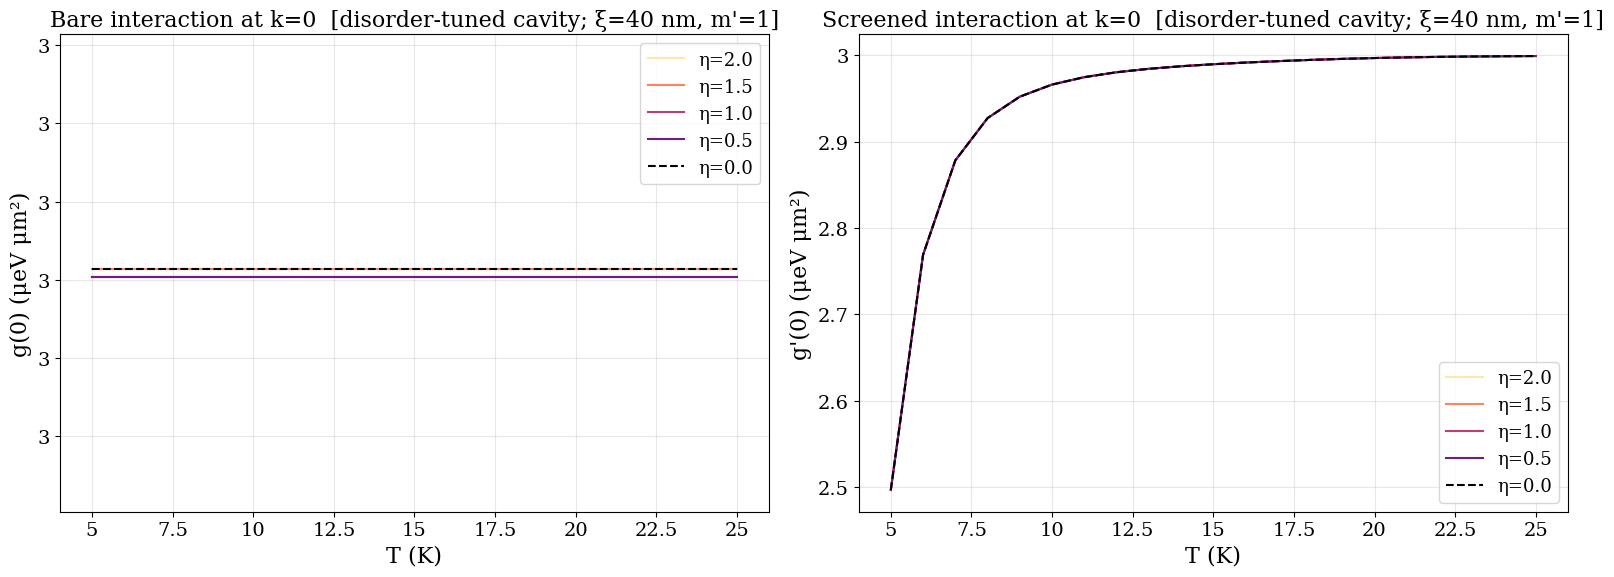

Saved  Plots/xi40nm_mprime1/g_k0_vs_temperature_xi40nm_mprime1_disorder_free.pdf


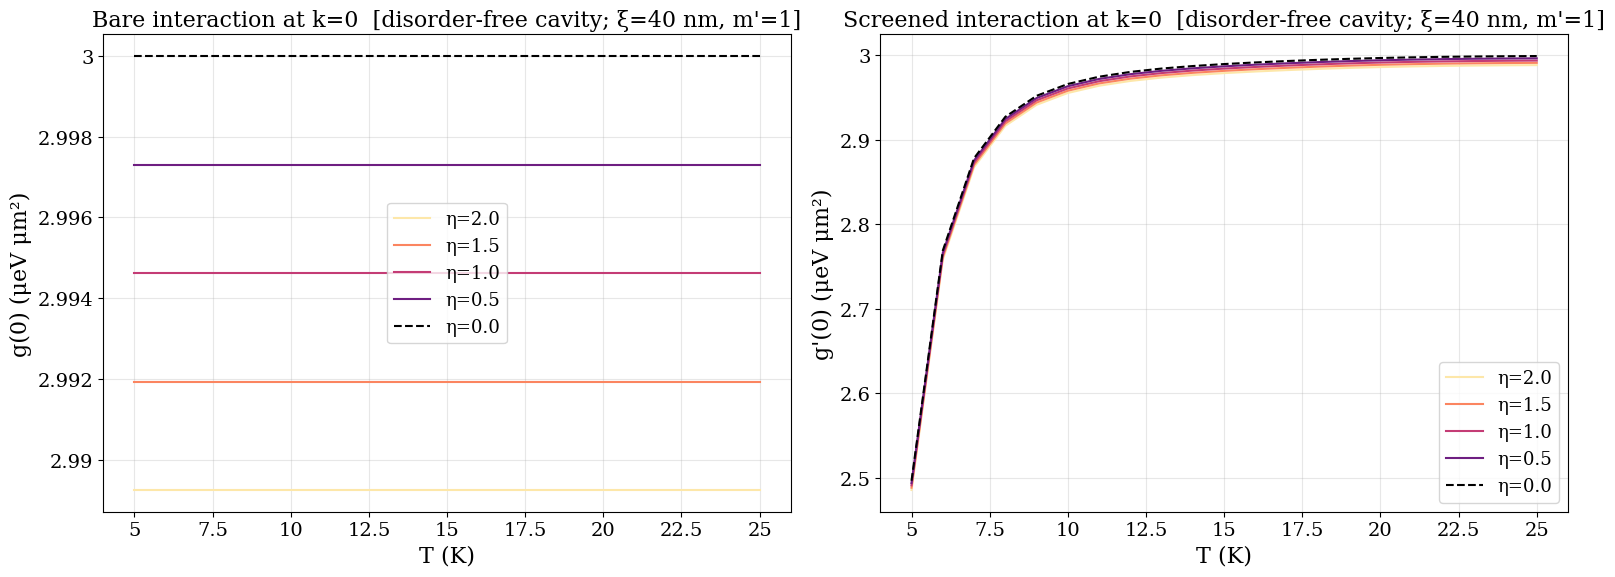

In [11]:
TEMPERATURES = np.linspace(5.0, 25.0, 21)  # K
K_ZERO = np.array([0.0])
L_TERMS_TEMP = 1000
TEMP_N_K_MU = 30_000
TEMP_K_UPPER_MASS = 1e-3
TEMP_N_K_MASS = 64

for plot_context in plot_contexts:
	apply_context(plot_context)

	def model_at_temperature(T: float) -> DispersionModel:
		return DispersionModel(replace(p_nat, T=float(T)), q_picard, eta_grid, Q_results)

	for tuned in (True, False):
		fig, axs = plt.subplots(1, 2, figsize=(16, 6), sharex=True)
		temperature_etas = eta_values_descending(legend_etas)
		for eta in temperature_etas:
			ei = int(np.argmin(np.abs(eta_grid - eta)))
			eta_value = float(eta_grid[ei])
			clr, linestyle = eta_line_style(ei, len(eta_grid), eta_value, linestyle="-")
			zorder = 10 if np.isclose(eta_value, 0.0, atol=1e-12) else 2
			bare_vals = []
			screened_vals = []
			for T in TEMPERATURES:
				temp_model = model_at_temperature(float(T))
				bubble = Pi0(
					temp_model, eta_value,
					L_terms=L_TERMS_TEMP,
					k_upper=K_UPPER,
					n_k=TEMP_N_K_MU,
					k_upper_mass=TEMP_K_UPPER_MASS,
					n_k_mass=TEMP_N_K_MASS,
					disorder_tuned=tuned,
				)
				g_bare, g_screened = polariton_interaction_strength(
					temp_model, eta_value, K_ZERO,
					L_terms=L_TERMS_TEMP,
					k_upper=K_UPPER,
					n_k=TEMP_N_K_MU,
					k_upper_mass=TEMP_K_UPPER_MASS,
					n_k_mass=TEMP_N_K_MASS,
					disorder_tuned=tuned,
					bubble=bubble,
				)
				bare_vals.append(g_bare[0])
				screened_vals.append(g_screened[0])

			axs[0].plot(TEMPERATURES, interaction_nat_to_microev_um2(np.asarray(bare_vals), p_nat), color=clr, linestyle=linestyle, label=f"η={eta_value:.1f}", zorder=zorder)
			axs[1].plot(TEMPERATURES, interaction_nat_to_microev_um2(np.asarray(screened_vals), p_nat), color=clr, linestyle=linestyle, label=f"η={eta_value:.1f}", zorder=zorder)

		for ax in axs:
			ax.set_xlabel("T (K)")
			ax.grid(alpha=0.3)
			ax.legend()
			format_plot_ticks(ax)
		axs[0].set_ylabel(f"g(0) ({INTERACTION_UNIT_LABEL})")
		axs[1].set_ylabel(f"g'(0) ({INTERACTION_UNIT_LABEL})")
		axs[0].set_title(f"Bare interaction at k=0  [{cavity_label(tuned)}; {result_label_text}]")
		axs[1].set_title(f"Screened interaction at k=0  [{cavity_label(tuned)}; {result_label_text}]")
		plt.tight_layout()
		save_figure(fig, f"g_k0_vs_temperature_{result_slug_text}_{cavity_slug(tuned)}", meta={
			**context_metadata(plot_context),
			"disorder_tuned": tuned,
			"temperatures_K": TEMPERATURES.tolist(),
			"L_terms": L_TERMS_TEMP,
			"k_upper_natural": K_UPPER,
			"n_k": TEMP_N_K_MU,
			"n_k_mu": TEMP_N_K_MU,
			"k_upper_mass_natural": TEMP_K_UPPER_MASS,
			"n_k_mass": TEMP_N_K_MASS,
		})
		plt.show()
		plt.close(fig)
